# Collecting Child Speech Data Annotated by MelBERT

In [ ]:
import os
import re
import statistics
import numpy as np
import scipy.stats as stats
import pandas as pd
import statsmodels.formula.api as smf
from collections import Counter

# --- Helper Functions ---
def load_annotation(file_path):
    with open(file_path, encoding='utf-8', errors='ignore') as file:
        lines = file.readlines()
        all_words = []
        for line in lines:
            parts = re.split(r'\t+', line)
            if len(parts) > 1:
                words = parts[1].rstrip()
                tokens = re.split(r'([\d\s.;,\n\t\r\[\]\/\\!\(\)\?\’\‘\_\-\•\—]+)', words)
                all_words.extend([word for word in tokens if any(c.isalpha() for c in word)])
    return all_words

def analyze_corpus(folder_path, file_list=None):
    results = {'prop_met_tokens': [], 'prop_met_types': [], 'metaphor_tokens': [], 'filenames': []}
    files = file_list if file_list else os.listdir(folder_path)
    for f in files:
        full_path = os.path.join(folder_path, f)
        if not os.path.isfile(full_path): continue
        words = load_annotation(full_path)
        if not words: continue
        num_metaphors, current_met_tokens, all_cleaned = 0, [], []
        for word in words:
            if word.startswith("#"):
                num_metaphors += 1
                token = word[1:].lower()
                current_met_tokens.append(token)
                all_cleaned.append(token)
            else:
                all_cleaned.append(word.lower())
        if not all_cleaned: continue
        results['prop_met_tokens'].append((num_metaphors / len(all_cleaned)) * 100)
        results['prop_met_types'].append((len(set(current_met_tokens)) / len(set(all_cleaned))) * 100)
        results['metaphor_tokens'].extend(current_met_tokens)
        results['filenames'].append(f)
    return results

def concordance_correlation_coefficient(y_true, y_pred):
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

# --- Process Corpora ---
CONFIG = {
    "Manchester": {"3": "data/manchester_context_3.zip", "100": "data/manchester_context_100.zip"},
    "Spoken": {"3": "data/spoken_context_3.zip", "100": "data/spoken_context_100.zip"},
    "Written": {"3": "data/written_context_3.zip", "100": "data/written_context_100.zip"}
}

RESULTS_DB = {}
for name, paths in CONFIG.items():
    files_3 = set(os.listdir(paths['3']))
    files_100 = set(os.listdir(paths['100']))
    common_files = list(files_3.intersection(files_100))
    RESULTS_DB[name] = {"3": analyze_corpus(paths['3'], file_list=common_files),
                        "100": analyze_corpus(paths['100'], file_list=common_files)}

In [ ]:
# --- FINALIZED DATA LOADER ---
def load_child_data(pkl_path="data/child_speech_data.txt", csv_path="data/child_speech_data.csv"):
    """
    Automatically loads data from the first available file format.
    """
    df = None
    
    # 1. Try Pickle first
    if os.path.exists(pkl_path):
        try:
            df = pd.read_pickle(pkl_path)
            print("Successfully loaded data from Pickle.")
        except Exception as e:
            print(f"Pickle found but could not be loaded: {e}")
    
    # 2. If Pickle failed or didn't exist, try CSV
    if df is None and os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            # Efficiently clean MelBERT column (only if it exists and is string)
            if 'MelBERT' in df.columns:
                df['MelBERT'] = df['MelBERT'].apply(
                    lambda x: [i.strip() for i in x.split(',')] if isinstance(x, str) else x
                )
            print("Successfully loaded and cleaned data from CSV.")
        except Exception as e:
            print(f"CSV found but could not be loaded: {e}")
            
    # 3. Final Validation
    if df is not None:
        return df[['Name', 'Age', 'MelBERT']]
    else:
        print("Error: No valid data files found.")
        return None

# --- Usage ---
child_speech_data = load_child_data()
if child_speech_data is not None:
    print(child_speech_data.head())

# Proportion Metaphors Child Speech

In [ ]:
# --- 1. Define Helper Function (Captures all metrics) ---
def get_session_metrics(utterances):
    """
    Calculates all session metrics using the unified pipeline logic.
    """
    all_words = []
    metaphor_tokens = []
    
    # Process utterances
    for utterance in utterances:
        words = utterance.split() 
        for word in words:
            # Handle tagging
            is_metaphor = word.startswith("#")
            clean_word = word[1:].lower() if is_metaphor else word.lower()
            
            all_words.append(clean_word)
            if is_metaphor:
                metaphor_tokens.append(clean_word)
    
    # Metrics
    token_count = len(all_words)
    unique_metaphors = set(metaphor_tokens)
    unique_words = set(all_words)
    
    return {
        'prop_met_tokens': (len(metaphor_tokens) / token_count * 100) if token_count > 0 else 0.0,
        'prop_met_types': (len(unique_metaphors) / len(unique_words) * 100) if len(unique_words) > 0 else 0.0,
        'token_metaphors': len(metaphor_tokens),
        'type_metaphors': len(unique_metaphors),
        'all_tokens_CS': all_words,
        'metaphor_tokens_list': metaphor_tokens
    }

# --- 2. Process Data ---
# Vectorized processing replaces the manual loop
cs_metrics = child_speech_data['MelBERT'].apply(get_session_metrics)
df_metrics = pd.DataFrame(cs_metrics.tolist())

# Merge with original dataframe
df_final = pd.concat([child_speech_data, df_metrics], axis=1)

# --- 3. Summary & Verification ---
print("Metrics processed using unified logic:")
print(df_final[['Name', 'prop_met_tokens', 'prop_met_types']].head())

# Mimic the second block's summary prints using the new df_final
mean_tokens = df_final['prop_met_tokens'].mean()
print(f"\nMean metaphor token proportion: {mean_tokens:.2f}%")

# Collect unique metaphor types for the sample print
all_metaphors_flat = [m for sublist in df_final['metaphor_tokens_list'] for m in sublist]
print(f"Sample Metaphor Types: {list(set(all_metaphors_flat))[:10]}")

In [ ]:
# --- 6. COMMON METAPHOR TYPES: 20 MOST FREQUENT METAPHORS ---
from collections import Counter

# Flatten the list of lists into a single stream of tokens
all_metaphors_flat = [token for sublist in df_final['metaphor_tokens_list'] for token in sublist]

if all_metaphors_flat:
    counter_cs = Counter(all_metaphors_flat)
    print(f"Total unique metaphor types: {len(counter_cs)}")
    
    # Get the 20 most frequent metaphors
    types_20_cs = counter_cs.most_common(20) 
    
    # Calculate coverage
    total_occurrences = len(all_metaphors_flat)
    total_top_20 = sum(count for item, count in types_20_cs)
    coverage_percentage = (total_top_20 / total_occurrences) * 100
    
    print(f"Total occurrences of top 20: {total_top_20}")
    print(f"Coverage of top 20: {coverage_percentage:.2f}% of the metaphor corpus")
    
    # Display the top 20
    print("\nTop 20 Metaphors:")
    for metaphor, count in types_20_cs:
        print(f"{metaphor}: {count}")
else:
    print("No metaphors found to analyze.")

# Proportion Metaphors CDS

In [ ]:
# --- Process Manchester Corpus (Metadata + Metrics) ---
FOLDER = "data/manchester_context_3.zip"
Subjects = ['Anne', 'Aran', 'Becky', 'Carl', 'Dominic', 'Eleanor', 'Fraser', 'Gail', 'Joel', 'John', 'Liz', 'Nicole', 'Ruth', 'Warren']
subjects_set = set(Subjects)

results_cds = {
    'names': [], 'ages': [], 'prop_met_tokens': [], 
    'prop_met_types': [], 'token_metaphors': [], 'type_metaphors': []
}

for f in os.listdir(FOLDER):
    if not f.endswith(('.txt', '.csv')): continue 
    
    file_path = os.path.join(FOLDER, f)
    words = load_annotation(file_path)
    if not words: continue

    # Parse metaphors
    metaphor_tokens = [word[1:].lower() for word in words if word.startswith("#")]
    all_words = [word[1:].lower() if word.startswith("#") else word.lower() for word in words]
    num_metaphors = len(metaphor_tokens)
    
    # Calculate metrics
    token_count = len(all_words)
    met_prop = (num_metaphors / token_count) * 100 if token_count > 0 else 0
    
    unique_metaphors = set(metaphor_tokens)
    unique_words = set(all_words)
    type_prop = (len(unique_metaphors) / len(unique_words)) * 100 if unique_words else 0

    # Extract Metadata
    name_match = next((s for s in subjects_set if f.startswith(s)), "Unknown")
    age_match = re.search(r'(\d{6})', f)
    
    # Store results
    results_cds['names'].append(name_match)
    results_cds['prop_met_tokens'].append(met_prop)
    results_cds['prop_met_types'].append(type_prop)
    results_cds['token_metaphors'].append(num_metaphors)
    results_cds['type_metaphors'].append(len(unique_metaphors))
    
    if age_match:
        age_str = age_match.group(1)
        age_mo = (int(age_str[0:2]) * 12) + int(age_str[2:4]) + (int(age_str[4:6]) / 30)
        results_cds['ages'].append(age_mo)
    else:
        results_cds['ages'].append(None)

# Convert to DataFrame for easy statistical modeling
df_cds = pd.DataFrame(results_cds)
print(f"Processed {len(df_cds)} files for Manchester.")
print(df_cds.head())

In [ ]:
# --- Proportions of Metaphors: Manchester Window 100 ---
FOLDER_100 = "data/manchester_context_100.zip"

# Reuse your optimized helper function
# This ensures consistency with the Window 3 analysis
results_100 = analyze_corpus(FOLDER_100)

# Map results for downstream analysis
prop_met_types_CDS_100 = results_100['prop_met_types']
prop_met_tokens_CDS_100 = results_100['prop_met_tokens']

# Display Summary
print(f"Processed {len(prop_met_types_CDS_100)} files.")

if prop_met_types_CDS_100:
    print(f"Mean Types (Window 100): {statistics.mean(prop_met_types_CDS_100):.4f}%")
    print(f"Mean Tokens (Window 100): {statistics.mean(prop_met_tokens_CDS_100):.4f}%")
else:
    print("No data processed for Window 100.")

In [ ]:
# Extract the list from the results_cds dictionary
prop_met_types_CDS = results_cds['prop_met_types']
prop_met_tokens_CDS = results_cds['prop_met_tokens']

# Verify the data exists
print(f"CDS Types list length: {len(prop_met_types_CDS)}")
print(f"CDS Tokens list length: {len(prop_met_tokens_CDS)}")

import scipy.stats as stats
import numpy as np

# 1. Ensure we are using the extracted lists
y_true = results_cds['prop_met_types']
y_pred = prop_met_types_CDS_100  # This comes from your results_100['prop_met_types']

# 2. Alignment Check: Find the minimum length
min_len = min(len(y_true), len(y_pred))

# 3. Truncate lists to the minimum length
y_true_final = y_true[:min_len]
y_pred_final = y_pred[:min_len]

# 4. Calculate Pearson correlation
pearson_corr, p_value = stats.pearsonr(y_true_final, y_pred_final)
print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}, p-value: {p_value:.4e}")

# 5. Calculate CCC
def concordance_correlation_coefficient(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

ccc_value = concordance_correlation_coefficient(y_true_final, y_pred_final)
print(f"Concordance Correlation Coefficient (CCC): {ccc_value:.4f}")

Pearson Correlation Coefficient: 0.8488684486936253 2.0114864499884918e-172
Concordance Correlation Coefficient (CCC): 0.7426032036857267


In [ ]:
# --- Correlation measurements between window 3 and window 100 results: TOKENS ---
import scipy.stats as stats
import numpy as np

# 1. Align data (Truncate to match lengths)
min_len_tokens = min(len(prop_met_tokens_CDS), len(prop_met_tokens_CDS_100))
y_true_tokens = prop_met_tokens_CDS[:min_len_tokens]
y_pred_tokens = prop_met_tokens_CDS_100[:min_len_tokens]

# 2. Pearson Correlation
pearson_corr_tokens, p_value_tokens = stats.pearsonr(y_true_tokens, y_pred_tokens)

# 3. Concordance Correlation Coefficient (CCC)
def concordance_correlation_coefficient(y_true, y_pred):
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

ccc_value_tokens = concordance_correlation_coefficient(y_true_tokens, y_pred_tokens)

# 4. Display Results
print(f"--- Correlation Results (Tokens, n={min_len_tokens}) ---")
print(f"Pearson Correlation: {pearson_corr_tokens:.4f} (p={p_value_tokens:.4e})")
print(f"CCC: {ccc_value_tokens:.4f}")

Pearson Correlation Coefficient: 0.9430806854353178 3.0617326768305293e-296
Concordance Correlation Coefficient (CCC): 0.9127920713415659


In [ ]:
# --- Common Metaphor Types: 20 most frequent metaphors across the CDS ---
from collections import Counter

# Flatten the list of metaphor tokens from the CDS corpus
# Ensure 'results_cds['metaphor_tokens']' was populated during processing
all_metaphors_CDS = [item for sublist in results_cds['metaphor_tokens'] for item in sublist]

if all_metaphors_CDS:
    counter_cds = Counter(all_metaphors_CDS)
    print(f"Total unique metaphor types in CDS: {len(counter_cds)}")
    
    # Get the 20 most frequent metaphors
    types_20_cds = counter_cds.most_common(20) 
    
    # Calculate coverage
    total_occurrences = len(all_metaphors_CDS)
    total_top_20 = sum(count for item, count in types_20_cds)
    coverage_percentage = (total_top_20 / total_occurrences) * 100
    
    print(f"Total occurrences of top 20: {total_top_20}")
    print(f"Coverage of top 20: {coverage_percentage:.2f}% of the CDS metaphor corpus")
    
    # Display the top 20 list
    print("\nTop 20 Metaphors in CDS:")
    for metaphor, count in types_20_cds:
        print(f"{metaphor}: {count}")
else:
    print("No metaphors found in the CDS corpus to analyze. Check that 'metaphor_tokens' was saved during processing.")

# Proportion Metaphors Spoken

In [ ]:
# --- Proportions of Metaphors Across Corpora: Spoken Window 3 ---
FOLDER_SPOKEN_3 = "data/spoken_context_3.zip"

# Process using the standardized helper function
results_spok = analyze_corpus(FOLDER_SPOKEN_3)

# Extract metrics
prop_met_types_Spok = results_spok['prop_met_types']
prop_met_tokens_Spok = results_spok['prop_met_tokens']

# --- Display Results ---
print(f"Processed {len(prop_met_types_Spok)} files.")

if prop_met_types_Spok:
    print(f"Mean Proportion Types: {statistics.mean(prop_met_types_Spok):.4f}%")
    print(f"Mean Proportion Tokens: {statistics.mean(prop_met_tokens_Spok):.4f}%")
else:
    print("No data processed for Spoken Window 3.")

In [ ]:
# --- Proportions of Metaphors Across Corpora: Spoken Window 100 ---
FOLDER_SPOKEN_100 = "data/spoken_context_100.zip"

# Process using the standardized helper function
results_spok_100 = analyze_corpus(FOLDER_SPOKEN_100)

# Extract metrics
prop_met_types_Spok_100 = results_spok_100['prop_met_types']
prop_met_tokens_Spok_100 = results_spok_100['prop_met_tokens']

# --- Display Results ---
print(f"Processed {len(prop_met_types_Spok_100)} files.")

if prop_met_types_Spok_100:
    print(f"Mean Proportion Types: {statistics.mean(prop_met_types_Spok_100):.4f}%")
    print(f"Mean Proportion Tokens: {statistics.mean(prop_met_tokens_Spok_100):.4f}%")
else:
    print("No data processed for Spoken Window 100.")

In [ ]:
# --- Process Filtered Corpora for Fair Comparison ---
import os

# Define your existing folder paths
FOLDER_3 = "data/spoken_context_3.zip"
FOLDER_100 = "data/spoken_context_100.zip"

# 1. Identify files that exist in BOTH folders
files_3 = set(os.listdir(FOLDER_3))
files_100 = set(os.listdir(FOLDER_100))
matching_files = sorted(list(files_3.intersection(files_100)))

# 2. Filter for non-empty files
# This ensures we don't process files that have no content in either folder
non_empty_matching_files = [
    f for f in matching_files 
    if f.endswith(('.txt', '.csv')) and load_annotation(os.path.join(FOLDER_3, f))
]

# 3. Process using the restricted file list
# We pass the list directly to your analyze_corpus function
data_spok_3_filtered = analyze_corpus(FOLDER_3, file_list=non_empty_matching_files)
data_spok_100_filtered = analyze_corpus(FOLDER_100, file_list=non_empty_matching_files)

# 4. Validation
print(f"Number of matching files processed: {len(non_empty_matching_files)}")
print(f"Metrics count check: {len(data_spok_3_filtered['prop_met_types']) == len(data_spok_100_filtered['prop_met_types'])}")

# 5. Statistical Comparison
corr_types_spok, p_types_spok = stats.pearsonr(
    data_spok_3_filtered['prop_met_types'], 
    data_spok_100_filtered['prop_met_types']
)

print(f"\nPearson Correlation (Types): {corr_types_spok:.3f}, p-value: {p_types_spok:.4e}")

In [ ]:
# --- Proportions of Metaphors Across Corpora: Spoken Window 100 (Filtered) ---
FOLDER_SPOKEN_100 = "data/spoken_context_100.zip"

# Use the standardized function with the same filtered list for a fair comparison
results_spok_100_filtered = analyze_corpus(FOLDER_SPOKEN_100, file_list=non_empty_matching_files)

# Access the metrics
prop_met_types_Spok_100 = results_spok_100_filtered['prop_met_types']
prop_met_tokens_Spok_100 = results_spok_100_filtered['prop_met_tokens']

# --- Display Results ---
print(f"Proportion Types (first 20):\n{prop_met_types_Spok_100[:20]}")
print(f"\nProportion Tokens (first 20):\n{prop_met_tokens_Spok_100[:20]}")

if prop_met_types_Spok_100:
    print(f"\nMean Proportion Types: {statistics.mean(prop_met_types_Spok_100):.4f}%")
    print(f"Mean Proportion Tokens: {statistics.mean(prop_met_tokens_Spok_100):.4f}%")
else:
    print("No data processed for the filtered files.")

In [ ]:
# --- Statistical Comparison: Window 3 vs Window 100 (Filtered) ---
import scipy.stats as stats
import numpy as np

# Re-defining CCC function just in case
def concordance_correlation_coefficient(y_true, y_pred):
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

# --- 1. Correlation for Types ---
corr_types, p_types = stats.pearsonr(prop_met_types_Spok, prop_met_types_Spok_100)
ccc_types = concordance_correlation_coefficient(prop_met_types_Spok, prop_met_types_Spok_100)

# --- 2. Correlation for Tokens ---
corr_tokens, p_tokens = stats.pearsonr(prop_met_tokens_Spok, prop_met_tokens_Spok_100)
ccc_tokens = concordance_correlation_coefficient(prop_met_tokens_Spok, prop_met_tokens_Spok_100)

# --- Summary Report ---
print(f"--- Statistical Comparison (n={len(prop_met_types_Spok)}) ---")
print(f"Types Pearson: {corr_types:.4f} (p={p_types:.4e}) | CCC: {ccc_types:.4f}")
print(f"Tokens Pearson: {corr_tokens:.4f} (p={p_tokens:.4e}) | CCC: {ccc_tokens:.4f}")

In [ ]:
# --- Correlation measurements between Spoken Window 3 and Window 100 results (TYPES) ---
import scipy.stats as stats
import numpy as np

# 1. Align data: Ensure lists are of equal length
min_len_spok = min(len(prop_met_types_Spok), len(prop_met_types_Spok_100))
y_true_types = prop_met_types_Spok[:min_len_spok]
y_pred_types = prop_met_types_Spok_100[:min_len_spok]

# 2. Pearson Correlation
pearson_corr_spok, p_value_spok = stats.pearsonr(y_true_types, y_pred_types)

# 3. Concordance Correlation Coefficient (CCC)
def concordance_correlation_coefficient(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

ccc_value_spok = concordance_correlation_coefficient(y_true_types, y_pred_types)

# 4. Display Results
print(f"--- Correlation Analysis (Types, n={min_len_spok}) ---")
print(f"Pearson Correlation: {pearson_corr_spok:.4f} (p={p_value_spok:.4e})")
print(f"Concordance Correlation Coefficient (CCC): {ccc_value_spok:.4f}")

Pearson Correlation Coefficient: 0.9527833410598991 6.288416299046082e-132
Concordance Correlation Coefficient (CCC): 0.5597190253270179


In [ ]:
# --- Correlation measurements between Spoken Window 3 and Window 100 results (TOKENS) ---
import scipy.stats as stats
import numpy as np

# 1. Align data: Ensure lists are of equal length
min_len_spok = min(len(prop_met_tokens_Spok), len(prop_met_tokens_Spok_100))
y_true_tokens = prop_met_tokens_Spok[:min_len_spok]
y_pred_tokens = prop_met_tokens_Spok_100[:min_len_spok]

# 2. Pearson Correlation
pearson_corr_tokens, p_value_tokens = stats.pearsonr(y_true_tokens, y_pred_tokens)

# 3. Concordance Correlation Coefficient (CCC)
def concordance_correlation_coefficient(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

ccc_value_tokens = concordance_correlation_coefficient(y_true_tokens, y_pred_tokens)

# 4. Display Results
print(f"--- Correlation Analysis (Tokens, n={min_len_spok}) ---")
print(f"Pearson Correlation: {pearson_corr_tokens:.4f} (p={p_value_tokens:.4e})")
print(f"Concordance Correlation Coefficient (CCC): {ccc_value_tokens:.4f}")

Pearson Correlation Coefficient: 0.9552546326112037 8.635509917073424e-135
Concordance Correlation Coefficient (CCC): 0.5598280425489791


In [ ]:
# --- Common Metaphor Types: 20 most frequent metaphors across the Spoken Corpus ---
from collections import Counter
# --- 1. Processing Step (Must run this first) ---
FOLDER_SPOKEN_3 = "data/spoken_context_3.zip"

# This populates 'results_spok_3_filtered' using your filtered file list
results_spok_3_filtered = analyze_corpus(FOLDER_SPOKEN_3, file_list=non_empty_matching_files)

print("Processing complete. 'results_spok_3_filtered' is now defined.")

# 1. Flatten the list of metaphor tokens from the Spoken corpus
# Using the filtered results from your previous step
if 'metaphor_tokens' in results_spok_3_filtered:
    all_metaphors_Spok = [item for sublist in results_spok_3_filtered['metaphor_tokens'] for item in sublist]

    if all_metaphors_Spok:
        counter_spok = Counter(all_metaphors_Spok)
        print(f"Total unique metaphor types in Spoken corpus: {len(counter_spok)}")
        
        # 2. Get the 20 most frequent metaphors
        types_20_spok = counter_spok.most_common(20) 
        
        # 3. Calculate coverage
        total_occurrences = len(all_metaphors_Spok)
        total_top_20 = sum(count for item, count in types_20_spok)
        coverage_percentage = (total_top_20 / total_occurrences) * 100
        
        print(f"Total occurrences of top 20: {total_top_20}")
        print(f"Coverage of top 20: {coverage_percentage:.2f}% of the Spoken metaphor corpus")
        
        # 4. Display the top 20 list
        print("\nTop 20 Metaphors in Spoken Corpus:")
        for metaphor, count in types_20_spok:
            print(f"{metaphor}: {count}")
    else:
        print("No metaphors found in the Spoken corpus to analyze.")
else:
    print("Error: 'metaphor_tokens' key not found in results_spok_3_filtered. Check your processing function.")

# Proportion Metaphors Written

In [ ]:
# --- Proportions of Metaphors Across Corpora: Written Window 3 ---
import statistics

FOLDER_WRITTEN_3 = "data/written_context_3.zip"

# Process using the standardized helper function
results_writ = analyze_corpus(FOLDER_WRITTEN_3)

# Extract metrics
prop_met_types_Writ = results_writ['prop_met_types']
prop_met_tokens_Writ = results_writ['prop_met_tokens']

# --- Display Results ---
print(f"Processed {len(prop_met_types_Writ)} files.")

if prop_met_types_Writ:
    print(f"Mean Proportion Types: {statistics.mean(prop_met_types_Writ):.4f}%")
    print(f"Mean Proportion Tokens: {statistics.mean(prop_met_tokens_Writ):.4f}%")
else:
    print("No data processed for Written Window 3.")

In [ ]:
# --- Proportions of Metaphors Across Corpora: Written Window 100 ---
import statistics

FOLDER_WRITTEN_100 = "data/written_context_100.zip"

# Process using the standardized helper function
results_writ_100 = analyze_corpus(FOLDER_WRITTEN_100)

# Extract metrics
prop_met_types_Writ_100 = results_writ_100['prop_met_types']
prop_met_tokens_Writ_100 = results_writ_100['prop_met_tokens']

# --- Display Results ---
print(f"Processed {len(prop_met_types_Writ_100)} files.")

if prop_met_types_Writ_100:
    print(f"Mean Proportion Types: {statistics.mean(prop_met_types_Writ_100):.4f}%")
    print(f"Mean Proportion Tokens: {statistics.mean(prop_met_tokens_Writ_100):.4f}%")
else:
    print("No data processed for Written Window 100.")

In [ ]:
# --- Process Filtered Corpora for Fair Comparison (Written) ---
import os

# Define the folder paths
folder_written_3 = "data/written_context_3.zip"
folder_written_100 = "data/written_context_100.zip"

# 1. Get intersecting file lists
files_3 = set(os.listdir(folder_written_3))
files_100 = set(os.listdir(folder_written_100))
matching_files = files_3.intersection(files_100)

# 2. Filter for non-empty, valid text files
# We ensure we are only processing files with data and correct extensions
non_empty_matching_files = [
    f for f in matching_files 
    if f.endswith(('.txt', '.csv')) and os.path.getsize(os.path.join(folder_written_3, f)) > 0
]

# Output the results
print(f"Total matching files found: {len(matching_files)}")
print(f"Files meeting criteria (non-empty & valid): {len(non_empty_matching_files)}")

In [ ]:
# --- Proportions of Metaphors Across Corpora: Written Window 3 (Filtered) ---
import statistics

# Define the folder path variable
folder_111 = "data/written_context_3.zip"

# Use the standardized function with the filtered list
results_writ_3_filtered = analyze_corpus(folder_111, file_list=non_empty_matching_files)

# Extract metrics
prop_met_types_Writ = results_writ_3_filtered['prop_met_types']
prop_met_tokens_Writ = results_writ_3_filtered['prop_met_tokens']

# --- Display Results ---
print(f"Proportion Types (first 20):\n{prop_met_types_Writ[:20]}")
print(f"\nProportion Tokens (first 20):\n{prop_met_tokens_Writ[:20]}")

if prop_met_types_Writ:
    print(f"\nMean Proportion Types: {statistics.mean(prop_met_types_Writ):.4f}%")
    print(f"\nMean Proportion Tokens: {statistics.mean(prop_met_tokens_Writ):.4f}%")
else:
    print("No data processed for the filtered files.")

In [ ]:
# --- Proportions of Metaphors Across Corpora: Written Window 100 (Filtered) ---
import statistics

# Define the folder path variable
folder_109 = "data/written_context_100.zip"

# Use the standardized function with the filtered list to ensure 1:1 file alignment
results_writ_100_filtered = analyze_corpus(folder_109, file_list=non_empty_matching_files)

# Extract metrics
prop_met_types_Writ_100 = results_writ_100_filtered['prop_met_types']
prop_met_tokens_Writ_100 = results_writ_100_filtered['prop_met_tokens']

# --- Display Results ---
print(f"Proportion Types (first 20):\n{prop_met_types_Writ_100[:20]}")
print(f"\nProportion Tokens (first 20):\n{prop_met_tokens_Writ_100[:20]}")

if prop_met_types_Writ_100:
    print(f"\nMean Proportion Types: {statistics.mean(prop_met_types_Writ_100):.4f}%")
    print(f"\nMean Proportion Tokens: {statistics.mean(prop_met_tokens_Writ_100):.4f}%")
else:
    print("No data processed for the filtered files.")

In [ ]:
# --- Correlation measurements between Written Window 3 and Window 100 results (TYPES) ---
import scipy.stats as stats
import numpy as np

# Ensure lists are of equal length
min_len_writ = min(len(prop_met_types_Writ), len(prop_met_types_Writ_100))

# Truncate to match lengths
y_true_types_writ = prop_met_types_Writ[:min_len_writ]
y_pred_types_writ = prop_met_types_Writ_100[:min_len_writ]

# Calculate Pearson correlation
pearson_corr_writ, p_value_writ = stats.pearsonr(y_true_types_writ, y_pred_types_writ)
print(f"Pearson Correlation (Types): {pearson_corr_writ:.4f}, p-value: {p_value_writ:.4e}")

# Calculate CCC
def concordance_correlation_coefficient(y_true, y_pred):
    """Calculate the Concordance Correlation Coefficient (CCC) between two datasets."""
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

ccc_value_writ = concordance_correlation_coefficient(y_true_types_writ, y_pred_types_writ)
print(f"Concordance Correlation Coefficient (CCC): {ccc_value_writ:.4f}")

Pearson Correlation Coefficient: 0.9378633759635 9.155334742639547e-48
Concordance Correlation Coefficient (CCC): 0.45117822475890246


In [ ]:
# --- Correlation measurements between Written Window 3 and Window 100 results (TOKENS) ---
import scipy.stats as stats
import numpy as np

# 1. Align data: Ensure lists are of equal length
min_len_writ = min(len(prop_met_tokens_Writ), len(prop_met_tokens_Writ_100))
y_true_tokens_writ = prop_met_tokens_Writ[:min_len_writ]
y_pred_tokens_writ = prop_met_tokens_Writ_100[:min_len_writ]

# 2. Pearson Correlation
pearson_corr_writ, p_value_writ = stats.pearsonr(y_true_tokens_writ, y_pred_tokens_writ)

# 3. Concordance Correlation Coefficient (CCC)
def concordance_correlation_coefficient(y_true, y_pred):
    """Calculate the Concordance Correlation Coefficient (CCC) between two datasets."""
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.cov(y_true, y_pred)[0, 1]
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

ccc_value_tokens_writ = concordance_correlation_coefficient(y_true_tokens_writ, y_pred_tokens_writ)

# 4. Display Results
print(f"--- Statistical Comparison (Tokens, n={min_len_writ}) ---")
print(f"Pearson Correlation: {pearson_corr_writ:.4f} (p={p_value_writ:.4e})")
print(f"Concordance Correlation Coefficient (CCC): {ccc_value_tokens_writ:.4f}")

Pearson Correlation Coefficient: 0.9313118231858082 1.1690411201300552e-45
Concordance Correlation Coefficient (CCC): 0.5544771727815792


In [ ]:
# --- Common Metaphor Types: 20 most frequent metaphors across the Written Corpus ---
from collections import Counter

# 1. Ensure the results dictionary was processed correctly
if 'metaphor_tokens' in results_writ_3_filtered:
    # 2. Flatten the list of metaphor tokens
    all_metaphors_Writ = [item for sublist in results_writ_3_filtered['metaphor_tokens'] for item in sublist]

    if all_metaphors_Writ:
        # 3. Count frequencies
        counter_writ = Counter(all_metaphors_Writ)
        print(f"Total unique metaphor types in Written corpus: {len(counter_writ)}")
        
        # 4. Get the 20 most frequent metaphors
        types_20_writ = counter_writ.most_common(20) 
        
        # 5. Calculate total and coverage percentage
        total_occurrences = len(all_metaphors_Writ)
        total_top_20 = sum(count for item, count in types_20_writ)
        coverage_percentage = (total_top_20 / total_occurrences) * 100
        
        print(f"Total occurrences of top 20: {total_top_20}")
        print(f"Coverage of top 20: {coverage_percentage:.2f}% of the Written metaphor corpus")
        
        # 6. Display the top 20 list
        print("\nTop 20 Metaphors in Written Corpus:")
        for metaphor, count in types_20_writ:
            print(f"{metaphor}: {count}")
    else:
        print("No metaphors found in the Written corpus to analyze.")
else:
    print("Error: 'metaphor_tokens' key not found in results_writ_3_filtered. Check your processing function.")

# Graphs: Proportions of Metaphors

In [ ]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- Configuration ---
# Use a relative path or a check to prevent errors if the font is missing
font_path = r'data/helveticaneue.ttf' # Update as needed
if os.path.exists(font_path):
    Helvetica = FontProperties(fname=font_path)
else:
    print("Warning: Font file not found. Using default font.")
    Helvetica = None # Matplotlib will default

# --- Data Preparation ---
initial = {'CDS': prop_met_tokens_CDS, 'Spoken': prop_met_tokens_Spok, 'Written': prop_met_tokens_Writ}
df = pd.DataFrame({k: pd.Series(v) for k, v in initial.items()})
data = [df[col].dropna() for col in df]

labels = ['Child-directed speech', 'Spoken', 'Written']
means = [np.mean(sample) for sample in data]
colors = ['#377eb8', '#ff7f00', '#4daf4a']

# --- Plotting ---
plt.figure(figsize=(16, 12), dpi=600) # Slightly adjusted for standard paper margins
plots = plt.violinplot(data, showmeans=False, showextrema=False, showmedians=False)

# Styling Violins
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7) # Slightly more transparency helps see overlapping data

# Mean Ticks
for i, mean in enumerate(means, start=1):
    plt.hlines(y=mean, xmin=i-0.15, xmax=i+0.15, color='black', linewidth=3)
    plt.text(i + 0.2, mean, f"{mean:.2f}", fontproperties=Helvetica, fontsize=20, va='center')

# Labels and Aesthetics
plt.title('Percentage of Metaphoric Words in 3 Corpora', fontproperties=Helvetica, size=28, pad=20)
plt.ylabel('Percentage of metaphors', fontproperties=Helvetica, size=24)
plt.xticks(range(1, len(labels) + 1), labels, fontproperties=Helvetica, size=22)
plt.yticks(fontproperties=Helvetica, size=18)

# Only horizontal grid lines for a cleaner 'academic' look
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.margins(0.1)

plt.tight_layout()
plt.savefig(r"Desktop\Percentage_met_Tokens_W3.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Violin plot for CDS and ADS only


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Updated to isolate Child-Directed Speech (CDS) and Adult-Directed Speech (ADS)
initial = {'CDS': prop_met_tokens_CDS, 'ADS': prop_met_tokens_Spok}

df = pd.DataFrame({k: pd.Series(v) for k, v in initial.items()})
data = [df[col].dropna() for col in df]

# Streamlined labels for a 2-condition spoken plot
labels = ['Child-directed speech', 'Adult-directed speech']
x = np.arange(1, len(data) + 1)
means = [np.mean(sample) for sample in data]

# Colorblind color cycle adjusted for 2 registers
colors = ['#377eb8', '#ff7f00']

plt.figure(figsize=(20, 17), dpi=600)

plots = plt.violinplot(data, showmeans=False, showextrema=False, showmedians=False)

# Set the color of the violin patches
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.8)

# ---- Dynamic Horizontal mean ticks + labels ----
for i, mean in enumerate(means, start=1):
    # Horizontal line at the mean
    plt.hlines(y=mean, xmin=i-0.25, xmax=i+0.25, color='black', linewidth=3)

    # Numeric label to the right of the tick (uses dynamically formatted calculation string)
    plt.text(i + 0.25, mean, f"mean={mean:.2f}", fontsize=24, va='center', font='Helvetica')

# -------------------------------------------------

plt.title('Percentage of Metaphoric Words across Spoken Registers', font='Helvetica', size=33, pad=20)

plt.ylabel('Percentage of metaphors', font='Helvetica', size=30)
plt.yticks(font='Helvetica', size=24)
plt.xticks(x, labels, font='Helvetica', size=28)

plt.grid(True)

plt.margins(0.2)
plt.subplots_adjust(bottom=0.15)

plt.savefig(r"\Desktop\Percentage_met_Tokens_W3_2.jpg", dpi=600, bbox_inches="tight")
plt.show()

# Reliability Analysis

In [ ]:
# Reliabilities Ground Truth vs MelBERT SPOKEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

from sklearn import metrics
spoken_GT = "data\BNC_spoken_to_annotate_GT.txt"
spoken_melbert = "data\BNC_spoken_annotated_by_melbert.txt"
spoken_1 = "data\BNC_spoken_to_annotate.txt"
spoken_2 = "data\BNC_spoken_to_annotate_Kim.txt"
written_1 = "data\BNC_written_to_annotate.txt"
written_2 = "data\BNC_written_to_annotate_Kim.txt"
written_GT = "data\BNC_written_to_annotate_GT.txt"
written_melbert = "data\BNC_written_annotated_by_melbert.txt"
CDS_1 = "data\Manchester_to_annotate.txt"
CDS_2 = "data\Manchester_to_annotate_Kim.txt"
CDS_GT = "data\Manchester_to_annotate_GT.txt"
CDS_melbert = "data\Manchester_annotated_by_melbert.txt"

words_gt = load_annotation(spoken_GT)
words_test = load_annotation(spoken_melbert)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Annotator 1 vs Annotator 2 SPOKEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(spoken_1)
words_test = load_annotation(spoken_2)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Ground Truth vs MelBERT WRITTEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(written_GT)
words_test = load_annotation(written_melbert)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Annotator 1 vs Annotator 2 WRITTEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(written_1)
words_test = load_annotation(written_2)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Ground Truth vs MelBERT CDS
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(CDS_GT)
words_test = load_annotation(CDS_melbert)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Annotator 1 vs Annotator 2 CDS
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(CDS_1)
words_test = load_annotation(CDS_2)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


# Mean Length of Utterance (MLU)

In [ ]:
import os
import re

def load_mlu(filename, folder_path):
    """Calculates utterance lengths from a file with error handling."""
    all_lengths = []
    filepath = os.path.join(folder_path, filename)
    
    with open(filepath, encoding='utf-8', errors='ignore') as file:
        for line in file:
            # Check if tab exists to avoid IndexError
            if '\t' not in line:
                continue
                
            # Split once at the first tab
            _, content = line.split('\t', 1)
            content = content.strip()
            
            # Use regex to find tokens, keeping only those with alpha characters
            tokens = re.split(r'[\d\s.;,\n\t\r\[\]\/\\!\(\)\?\’\‘\_\-•\—]+', content)
            tokens = [t for t in tokens if any(c.isalpha() for c in t)]
            
            all_lengths.append(len(tokens))
            
    return all_lengths

In [ ]:
#Child speech MLU

num_met_CS = []
mlu_CS = []

for session in child_speech_data['MelBERT']:
    for utterance in session:
        words = utterance.split()
        
        # MLU calculation
        mlu_CS.append(len(words))
        
        # Metaphor count (counting tokens that start with #)
        metaphor_count = sum(1 for word in words if word.startswith("#"))
        num_met_CS.append(metaphor_count)


# Combine lists into a DataFrame
df_cs = pd.DataFrame({
    'mlu': mlu_CS,
    'metaphor_count': num_met_CS
})

# Calculate metaphor density (metaphors per word)
# Adding a small epsilon or handling division by zero is good practice
df_cs['metaphor_density'] = df_cs['metaphor_count'] / df_cs['mlu'].replace(0, 1)

print(df_cs.head())
print(df_cs.describe())

In [ ]:
import statistics

# Initialize lists to store session-level data
mlu_CS_session = []
met_CS_session_avg = [] 

for each in child_speech_data['MelBERT']:
    session_mlus = []
    session_metaphor_counts = []
    
    for utterance in each: 
        words = utterance.split() 
        # MLU for this utterance
        session_mlus.append(len(words))
        
        # Count metaphors in this utterance
        met_count = sum(1 for word in words if word.startswith("#"))
        session_metaphor_counts.append(met_count)
    
    # Calculate session-level aggregates
    # Handle empty sessions to avoid DivisionByZero errors
    if session_mlus:
        mlu_CS_session.append(statistics.mean(session_mlus))
        met_CS_session_avg.append(statistics.mean(session_metaphor_counts))
    else:
        mlu_CS_session.append(0)
        met_CS_session_avg.append(0)

# Now these two lists are perfectly aligned by session
print(f"Sessions processed: {len(mlu_CS_session)}")
print(f"MLU (first 5): {mlu_CS_session[:5]}")
print(f"Avg Metaphors per Utterance (first 5): {met_CS_session_avg[:5]}")

In [ ]:
# Child-directed speech
import os
import re

# --- Configuration ---
FOLDER = "data/manchester_context_3.zip" 

# Initialize lists
num_met_CDS = []
mlu_CDS = []

# --- Processing ---
for f in os.listdir(FOLDER):
    file_path = os.path.join(FOLDER, f)
    
    # Skip directories or non-files
    if not os.path.isfile(file_path):
        continue
    
    with open(file_path, encoding='utf-8', errors='ignore') as file:
        for line in file:
            parts = re.split(r'\t+', line)
            
            # Ensure the line has a column 1 to process
            if len(parts) < 2:
                continue
                
            content = parts[1].rstrip()
            
            # Tokenize: Split by the specified punctuation/whitespace
            tokens = re.split(r'([\d\s.;,\n\t\r\[\]\/\\!\(\)\?\’\‘\_\-•\—]+)', content)
            tokens = [word for word in tokens if any(c.isalpha() for c in word)]
            
            # 1. MLU Calculation
            mlu_CDS.append(len(tokens))
            
            # 2. Metaphor Count (using list comprehension for efficiency)
            met_count = sum(1 for word in tokens if word.startswith("#"))
            num_met_CDS.append(met_count)

# --- Verification ---
print(f"Sample Metaphor Counts: {num_met_CDS[:100]}")
print(f"Sample MLUs: {mlu_CDS[:100]}")
print(f"Total Utterances Processed: {len(num_met_CDS)}")

In [ ]:
import os
import re
import statistics

# Initialize session-level lists
mlu_CDS_session = []
met_CDS_session = []

for f in os.listdir(FOLDER):
    file_path = os.path.join(FOLDER, f)
    
    # Ensure we only process files
    if not os.path.isfile(file_path):
        continue
        
    # Temporary lists for the current session
    current_session_mlus = []
    current_session_met_counts = []
    
    with open(file_path, encoding='utf-8', errors='ignore') as file:
        for line in file:
            # 1. Parsing logic
            parts = re.split(r'\t+', line)
            if len(parts) < 2: continue
            
            content = parts[1].rstrip()
            # Tokenize using your established regex
            tokens = re.split(r'([\d\s.;,\n\t\r\[\]\/\\!\(\)\?\’\‘\_\-•\—]+)', content)
            tokens = [w for w in tokens if any(c.isalpha() for c in w)]
            
            # 2. Extract metrics per utterance
            if tokens:
                current_session_mlus.append(len(tokens))
                # Count metaphors (words starting with #)
                met_count = sum(1 for w in tokens if w.startswith("#"))
                current_session_met_counts.append(met_count)
    
    # 3. Aggregate at session level (only if file wasn't empty)
    if current_session_mlus:
        mlu_CDS_session.append(statistics.mean(current_session_mlus))
        met_CDS_session.append(statistics.mean(current_session_met_counts))
    else:
        # Handle empty files/utterances
        mlu_CDS_session.append(0)
        met_CDS_session.append(0)

print(f"Processed {len(mlu_CDS_session)} sessions.")
print(f"Sample MLU means: {mlu_CDS_session[:10]}")
print(f"Sample Metaphor means: {met_CDS_session[:10]}")

In [ ]:
# Spoken

import os
import re

# --- Configuration ---
# Note: Use r"" for raw strings to avoid escape sequence issues with \s or \t in Windows paths
FOLDER = r"data\spoken_context_3.zip"

num_met_Spok = []
mlu_Spok = []

# --- Processing ---
for f in os.listdir(FOLDER):
    file_path = os.path.join(FOLDER, f)
    
    if not os.path.isfile(file_path):
        continue 
    
    with open(file_path, encoding='utf-8', errors='ignore') as file:
        for line in file:
            # 1. Parse line
            parts = re.split(r'\t+', line)
            if len(parts) < 2:
                continue
            
            content = parts[1].rstrip()
            
            # 2. Tokenize
            tokens = re.split(r'([\d\s.;,\n\t\r\[\]\/\\!\(\)\?\’\‘\_\-•\—]+)', content)
            tokens = [word for word in tokens if any(c.isalpha() for c in word)]
            
            # 3. Calculate metrics synchronously
            # MLU
            mlu_Spok.append(len(tokens))
            
            # Metaphor Count
            met_count = sum(1 for word in tokens if word.startswith("#"))
            num_met_Spok.append(met_count)

# --- Verification ---
print(f"Total utterances processed: {len(num_met_Spok)}")
print(f"Sample Metaphor Counts: {num_met_Spok[:10]}")
print(f"Sample MLUs: {mlu_Spok[:10]}")

In [ ]:
# Written

import os
import re

# --- Configuration ---
# Using a raw string (r"") to handle backslashes correctly
FOLDER = r"data\written_context_3.zip"

num_met_Writ = []
mlu_Writ = []

# --- Processing ---
for f in os.listdir(FOLDER):
    file_path = os.path.join(FOLDER, f)
    
    # Skip directories
    if not os.path.isfile(file_path):
        continue 
    
    with open(file_path, encoding='utf-8', errors='ignore') as file:
        for line in file:
            parts = re.split(r'\t+', line)
            if len(parts) < 2:
                continue
                
            content = parts[1].rstrip()
            
            # Tokenize: same regex logic
            tokens = re.split(r'([\d\s.;,\n\t\r\[\]\/\\!\(\)\?\’\‘\_\-•\—]+)', content)
            tokens = [word for word in tokens if any(c.isalpha() for c in word)]
            
            # 1. MLU (Utterance length)
            mlu_Writ.append(len(tokens))
            
            # 2. Metaphor Count (Words starting with #)
            met_count = sum(1 for word in tokens if word.startswith("#"))
            num_met_Writ.append(met_count)

# --- Verification ---
print(f"Total utterances processed: {len(num_met_Writ)}")
print(f"Sample Metaphor Counts: {num_met_Writ[:10]}")
print(f"Sample MLUs: {mlu_Writ[:10]}")

In [ ]:
import statistics
import pandas as pd

# Assuming the lists are already populated from your previous steps
means = {
    'Child Speech': statistics.mean(mlu_CS),
    'CDS': statistics.mean(mlu_CDS),
    'Spoken': statistics.mean(mlu_Spok),
    'Written': statistics.mean(mlu_Writ)
}

# Display results clearly
print("--- Mean Length of Utterance (MLU) across Corpora ---")
for corpus, mean_val in means.items():
    print(f"{corpus}: {mean_val:.4f}")

# Optional: Store as a DataFrame for easy plotting/exporting
df_means = pd.DataFrame(list(means.items()), columns=['Corpus', 'Mean_MLU'])

In [ ]:
import scipy.stats

# Store data in a dictionary for easy iteration
corpora_data = {
    "Child Speech": (num_met_CS, mlu_CS),
    "CDS": (num_met_CDS, mlu_CDS),
    "Spoken": (num_met_Spok, mlu_Spok),
    "Written": (num_met_Writ, mlu_Writ)
}

print(f"{'Corpus':<15} | {'Pearson r':<12} | {'p-value':<10}")
print("-" * 45)

for name, (metaphors, mlu) in corpora_data.items():
    # Calculate correlation
    corr, p_value = scipy.stats.pearsonr(metaphors, mlu)
    
    # Print formatted output
    print(f"{name:<15} | {corr:.4f}       | {p_value:.4e}")

# Lexical Diversity

In [ ]:
# Lexical diversity measurements (Child Speech)

# https://pypi.org/project/lexical-diversity/

#%pip install lexical-diversity
from lexical_diversity import lex_div as ld


# The transformation step to create your variable:
all_tokens_corpus_CS = [
    word 
    for session in child_speech_data['MelBERT'] 
    for utterance in session 
    for word in utterance.split()
]

print(ld.ttr(all_tokens_corpus_CS))

print(ld.mattr(all_tokens_corpus_CS)) # Moving average TTR

print(ld.mattr(all_tokens_corpus_CS, window_length=500))

print(ld.mtld(all_tokens_corpus_CS)) # based on McCarthy and Jarvis (2010)

# HD-D is an idealized version of voc-D. For more information see McCarthy, P.M. & Jarvis, S. (2007). vocd: A theoretical and empirical evaluation. Language Testing, 24(4), 459-488.
print(ld.hdd(all_tokens_corpus_CS)) # McCarthy and Jarvis (2007, 2010)





In [ ]:
# CHILD SPEECH general terms

# https://lexicalrichness.readthedocs.io/en/latest/
# https://github.com/LSYS/lexicalrichness
# https://www.lucasshen.com/research/media.pdf

#%pip install textblob
#%pip install lexicalrichness
from lexicalrichness import LexicalRichness

text = " ".join(all_tokens_corpus_CS)
lex = LexicalRichness(text)
print(lex.words)
print(lex.terms)

# Return type-token ratio (TTR) of text.
print(lex.ttr)

# Return moving average type-token ratio (MATTR).
print(lex.mattr(window_size=500))

# Return Measure of Textual Lexical Diversity (MTLD).
print(lex.mtld(threshold=0.72))

# Return hypergeometric distribution diversity (HD-D) measure.
print(lex.hdd(draws=42))

# Return voc-D measure.
print(lex.vocd(ntokens=500, within_sample=100, iterations=3)) # (Mckee, Malvern, and Richards 2010)

# Also available: Herdan's lexical diversity measure, Summer's, Dugast's, Maas's, Yule's K, Yule's I, Herdan's Vm, Simpson's D

# Utility to plot empirical voc-D curve
lex.vocd_fig(
    ntokens=500,  # Maximum number for the token/word size in the random samplings
    within_sample=100,  # Number of samples
    seed=42,  # Seed for reproducibility
)



In [ ]:
# --- Lexical Diversity of Metaphors (Child Speech) ---
# Ensure you have installed the library: pip install lexicalrichness
from lexicalrichness import LexicalRichness

# 1. Flatten the metaphor tokens (from list-of-lists to flat list)
metaphor_tokens_CS_all = [item for sublist in metaphor_tokens_CS for item in sublist]

# 2. Prepare the text
# Note: LexicalRichness can accept a list of tokens directly, 
# which is often more accurate than joining them into a string.
lex = LexicalRichness(metaphor_tokens_CS_all)

# 3. Calculate metrics
# MATTR is excellent for metaphors as it handles varying lengths well
print(f"MATTR (window size 50): {lex.mattr(window_size=50):.4f}")

# vocd is a sophisticated measure of vocabulary diversity
# It uses an iterative process, so it can take a moment to calculate
print(f"Voc-D (ntokens 400): {lex.vocd(ntokens=400):.4f}")

0.3634481216457437
13.506294205484464


In [ ]:
# CHILD-DIRECTED SPEECH general terms

from lexicalrichness import LexicalRichness

text_CDS = " ".join(all_tokens_corpus_CDS)
lex_CDS = LexicalRichness(text_CDS)

# Return type-token ratio (TTR) of text.
print(lex_CDS.ttr)

# Return moving average type-token ratio (MATTR).
print(lex_CDS.mattr(window_size=500))

# Return Measure of Textual Lexical Diversity (MTLD).
print(lex_CDS.mtld(threshold=0.72))

# Return hypergeometric distribution diversity (HD-D) measure.
print(lex_CDS.hdd(draws=42))

# Return voc-D measure.
print(lex_CDS.vocd(ntokens=500, within_sample=100, iterations=3)) # (Mckee, Malvern, and Richards 2010)

In [31]:
# CHILD-DIRECTED SPEECH metaphoric words

metaphor_tokens_CDS_all = [item for sublist in metaphor_tokens_CDS for item in sublist]
text = " ".join(metaphor_tokens_CDS_all)
lex = LexicalRichness(text)

# Return moving average type-token ratio (MATTR).
print(lex.mattr(window_size=50))

# Return voc-D measure.
print(lex.vocd(ntokens=400, within_sample=50, iterations=3)) # (Mckee, Malvern, and Richards 2010)

0.4156831881917871
13.257913317961433


In [ ]:
# Correlation Lexical Diversity CS/ CDS

import scipy.stats

print(scipy.stats.pearsonr(mattr_CS, mattr_CDS)) 

print(scipy.stats.pearsonr(vocd_CS, vocd_CDS)) 


In [44]:
from sklearn import preprocessing
mattr_all = np.array([0.56, 0.67, 0.74, 0.81])
mattr_all_norm=preprocessing.normalize([mattr_all])
print(mattr_all_norm)

mattr_met = np.array([0.36, 0.42, 0.57, 0.71])
mattr_met_norm=preprocessing.normalize([mattr_met])
print(mattr_met_norm)

vocd_all = np.array([78, 85, 122, 217 ])
vocd_all_norm=preprocessing.normalize([vocd_all])
print(vocd_all_norm)

vocd_met = np.array([13.5, 13.3, 38, 92.3 ])
vocd_met_norm=preprocessing.normalize([vocd_met])
print(vocd_met_norm)

[[0.39936884 0.4778163  0.5277374  0.57765851]]
[[0.33791274 0.39423153 0.53502851 0.66643902]]
[[0.28428178 0.30979425 0.44464586 0.79088649]]
[[0.13287485 0.13090634 0.3740181  0.90847029]]


In [ ]:
# Lexical diversity SPOKEN all terms

from lexicalrichness import LexicalRichness

text_Spok = " ".join(all_tokens_corpus_Spok)
lex_Spok = LexicalRichness(text_Spok)

# Return type-token ratio (TTR) of text.
print(lex_Spok.ttr)

# Return moving average type-token ratio (MATTR).
print(lex_Spok.mattr(window_size=500))

# Return Measure of Textual Lexical Diversity (MTLD).
print(lex_Spok.mtld(threshold=0.72))

# Return hypergeometric distribution diversity (HD-D) measure.
print(lex_Spok.hdd(draws=42))

# Return voc-D measure.
print(lex_Spok.vocd(ntokens=500, within_sample=100, iterations=3)) # (Mckee, Malvern, and Richards 2010)

In [35]:
# Lexical diversity SPOKEN metaphoric words

metaphor_tokens_Spok_all = [item for sublist in metaphor_tokens_Spok for item in sublist]
text = " ".join(metaphor_tokens_Spok_all)
lex = LexicalRichness(text)

# Return moving average type-token ratio (MATTR).
print(lex.mattr(window_size=50))

# Return voc-D measure.
print(lex.vocd(ntokens=400, within_sample=50, iterations=3)) # (Mckee, Malvern, and Richards 2010)

0.5670851525269565
37.95595321899474


In [ ]:
# Lexical diversity WRITTEN all terms

from lexicalrichness import LexicalRichness

text_Writ = " ".join(all_tokens_corpus_Writ)
lex_Writ = LexicalRichness(text_Writ)

# Return type-token ratio (TTR) of text.
print(lex_Writ.ttr)

# Return moving average type-token ratio (MATTR).
print(lex_Writ.mattr(window_size=500))

# Return Measure of Textual Lexical Diversity (MTLD).
print(lex_Writ.mtld(threshold=0.72))

# Return hypergeometric distribution diversity (HD-D) measure.
print(lex_Writ.hdd(draws=42))

# Return voc-D measure.
print(lex_Writ.vocd(ntokens=500, within_sample=100, iterations=3)) # (Mckee, Malvern, and Richards 2010)

In [37]:
# Lexical diversity WRITTEN metaphoric words

metaphor_tokens_Writ_all = [item for sublist in metaphor_tokens_Writ for item in sublist]
text = " ".join(metaphor_tokens_Writ_all)
lex = LexicalRichness(text)

# Return moving average type-token ratio (MATTR).
print(lex.mattr(window_size=50))

# Return voc-D measure.
print(lex.vocd(ntokens=400, within_sample=50, iterations=3)) # (Mckee, Malvern, and Richards 2010)

0.7050790824344317
92.28102224282718


In [ ]:
# Analysing Child speech and Child-directed speech by document/ session

# Normalizing and plotting

from sklearn import preprocessing
import numpy as np

mattr=np.array([0.2747607449356993, 0.3283654240376962, 0.4029832964761, 0.5184755825197463])

vocd=np.array([79.51816324062709, 85.79171424268087, 124.8271109667897, 231.64220982389222])

normalized_mattr = preprocessing.normalize([mattr])
print(normalized_mattr)

normalized_vocd = preprocessing.normalize([vocd])
print(normalized_vocd)

mattr_met=np.array([0.15799813378809463, 0.1831354624833028, 0.28742315305079635, 0.4297632049691231])

vocd_met=np.array([13.672796793936941, 13.464638711152901, 39.21700483195814, 97.96184797144656])

normalized_mattr_met = preprocessing.normalize([mattr_met])
print(normalized_mattr_met)

normalized_vocd_met = preprocessing.normalize([vocd_met])
print(normalized_vocd_met)


In [45]:
# Lexical Diversity Plot

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize = (20, 17), dpi=600) 

# Colorblind color cycle:
colors = ['#377eb8', '#ff7f00', '#4daf4a','#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

x = np.arange(4)

y1 = [0.39936884, 0.4778163,  0.5277374,  0.57765851] # MATTR
y2 = [0.28428178, 0.30979425, 0.44464586, 0.79088649] # voc-D
y3 = [0.33791274, 0.39423153, 0.53502851, 0.66643902] # MATTR Metaphors
y4 = [0.13287485, 0.13090634, 0.3740181,  0.90847029] # voc-D Metaphors

width = 0.2

# plot data in grouped manner of bar type
plt.bar(x-0.2, y1, width, color=colors[0])
plt.bar(x, y2, width, color=colors[1])
plt.bar(x+0.2, y3, width, color=colors[2])
plt.bar(x+0.4, y4, width, color=colors[3])

plt.xticks(x, ['Child Speech', 'CDS', 'Spoken', 'Written'], font=Helvetica, size=28)

plt.yticks(font=Helvetica, size=28)

plt.xlabel("Speech genres", font=Helvetica, size=30)
plt.ylabel("Normalized lexical diversity value", font=Helvetica, size=30)

plt.legend(["MATTR measurement (window=500 tokens): " + r"$\bf{" + 'all\ words' + "}$", "voc-D index (McCarthy and Jarvis, 2010): " + r"$\bf{" + 'all\ words' + "}$", "MATTR measurement (window=500 tokens): " + r"$\bf{" + 'metaphors' + "}$", "voc-D index (McCarthy and Jarvis, 2010): "+ r"$\bf{" + 'metaphors' + "}$"], prop=FontProperties(fname=font_path, size=28), loc ="upper left", frameon=False)

plt.grid(True)

# Pad margins so that markers don't get clipped by the axes
plt.margins(0.2)
# Tweak spacing to prevent clipping of tick-labels
plt.subplots_adjust(bottom=0.15)

plt.title("Normalized Lexical Diversity Measurements", font=Helvetica, size=35, pad=20)

plt.savefig(r"C:\Users\lvfeu\Desktop\Lexical_Diversity.jpg", dpi=600, bbox_inches="tight")

plt.show()


# ANOVAs

In [ ]:
from scipy.stats import f_oneway
stat, p = f_oneway(prop_met_types_CDS, prop_met_types_Spok, prop_met_types_Writ)
print('Statistics_types_3 = %.3f, p=%.3f' % (stat, p))

stat, p = f_oneway(prop_met_tokens_CDS, prop_met_tokens_Spok, prop_met_tokens_Writ)
print('Statistics_tokens_3 = %.3f, p=%.3f' % (stat, p))

stat, p = f_oneway(prop_met_tokens_CDS_100, prop_met_tokens_Spok_100, prop_met_tokens_Writ_100)
print('Statistics_tokens_100 = %.3f, p=%.3f' % (stat, p))

stat, p = f_oneway(prop_met_types_CDS_100, prop_met_types_Spok_100, prop_met_types_Writ_100)
print('Statistics_types_100 = %.3f, p=%.3f' % (stat, p))

In [ ]:
from scipy.stats import f_oneway, shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# One-Way ANOVA
anova_result = f_oneway(prop_met_tokens_CDS, prop_met_tokens_Spok, prop_met_tokens_Writ)
print("\nOne-Way ANOVA:")
print(f"F-statistic: {anova_result.statistic}, p-value: {anova_result.pvalue}")

# Shapiro-Wilk Test for Normality
print("Shapiro-Wilk Test for Normality:")
print(f"CDS: {shapiro(prop_met_tokens_CDS)}")
print(f"ADS: {shapiro(prop_met_tokens_Spok)}")
print(f"Written: {shapiro(prop_met_tokens_Writ)}")

# Levene’s Test for Homogeneity of Variances
levene_test = levene(prop_met_tokens_CDS, prop_met_tokens_Spok, prop_met_tokens_Writ)
print("\nLevene’s Test for Homogeneity of Variances:")
print(f"Statistic: {levene_test.statistic}, p-value: {levene_test.pvalue}")

# Combine data and create group labels
data = prop_met_tokens_CDS + prop_met_tokens_Spok + prop_met_tokens_Writ
groups = ['CDS'] * len(prop_met_tokens_CDS) + ['ADS'] * len(prop_met_tokens_Spok) + ['Written'] * len(prop_met_tokens_Writ)

# Post-hoc Test with Bonferroni Correction
tukey = pairwise_tukeyhsd(endog=data, groups=groups, alpha=0.05)
print("\nPost-Hoc Comparisons (Tukey HSD):")
print(tukey)

# Display the means for each group
group_means = {
    'CDS': np.mean(prop_met_tokens_CDS),
    'ADS': np.mean(prop_met_tokens_Spok),
    'Written': np.mean(prop_met_tokens_Writ)
}
print("\nGroup Means:")
for group, mean in group_means.items():
    print(f"{group}: {mean:.2f}")

In [ ]:

# One-Way ANOVA 
concreteness_CDS = "data\concreteness_CDS.zip"
concreteness_Spok = "data\concreteness_Spok.zip"
concreteness_Writ = "data\concreteness_Writ.zip"

anova_result = f_oneway(concreteness_CDS, concreteness_Spok, concreteness_Writ)
print("\nOne-Way ANOVA:")
print(f"F-statistic: {anova_result.statistic}, p-value: {anova_result.pvalue}")

# Shapiro-Wilk Test for Normality
print("Shapiro-Wilk Test for Normality:")
print(f"CDS: {shapiro(concreteness_CDS)}")
print(f"ADS: {shapiro(concreteness_Spok)}")
print(f"Written: {shapiro(concreteness_Writ)}")

# Levene’s Test for Homogeneity of Variances
levene_test = levene(concreteness_CDS, concreteness_Spok, concreteness_Writ)
print("\nLevene’s Test for Homogeneity of Variances:")
print(f"Statistic: {levene_test.statistic}, p-value: {levene_test.pvalue}")

# Combine data and create group labels
data = concreteness_CDS + concreteness_Spok + concreteness_Writ
groups = ['CDS'] * len(concreteness_CDS) + ['ADS'] * len(concreteness_Spok) + ['Written'] * len(concreteness_Writ)

# Post-hoc Test with Bonferroni Correction
tukey = pairwise_tukeyhsd(endog=data, groups=groups, alpha=0.05)
print("\nPost-Hoc Comparisons (Tukey HSD):")
print(tukey)

# Display the means for each group
group_means = {
    'CDS': np.mean(concreteness_CDS),
    'ADS': np.mean(concreteness_Spok),
    'Written': np.mean(concreteness_Writ)
}
print("\nGroup Means:")
for group, mean in group_means.items():
    print(f"{group}: {mean:.2f}")

In [ ]:
# ANOVA Lexical Diversity (corrected)
from scipy.stats import f_oneway, shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# Ensure everything is numpy arrays (avoids accidental elementwise +)
mattr_CDS   = np.asarray(mattr_CDS)
mattr_Spok  = np.asarray(mattr_Spok)
mattr_Writ  = np.asarray(mattr_Writ)

# --- Basic info for reporting degrees of freedom ---
n_cds  = len(mattr_CDS)
n_ads  = len(mattr_Spok)
n_writ = len(mattr_Writ)

k  = 3  # number of groups: CDS, ADS, Written
N  = n_cds + n_ads + n_writ
df_between = k - 1
df_within  = N - k

# --- One-Way ANOVA ---
anova_result = f_oneway(mattr_CDS, mattr_Spok, mattr_Writ)
F_stat = anova_result.statistic
p_val  = anova_result.pvalue

print("\nOne-Way ANOVA:")
print(f"F({df_between}, {df_within}) = {F_stat:.2f}, p = {p_val:.3e}")

# --- Shapiro-Wilk Test for Normality (per group) ---
print("\nShapiro-Wilk Test for Normality:")
print(f"CDS:    W = {shapiro(mattr_CDS).statistic:.3f}, p = {shapiro(mattr_CDS).pvalue:.3e}")
print(f"ADS:    W = {shapiro(mattr_Spok).statistic:.3f}, p = {shapiro(mattr_Spok).pvalue:.3e}")
print(f"Written:W = {shapiro(mattr_Writ).statistic:.3f}, p = {shapiro(mattr_Writ).pvalue:.3e}")

# --- Levene’s Test for Homogeneity of Variances ---
levene_test = levene(mattr_CDS, mattr_Spok, mattr_Writ)
print("\nLevene’s Test for Homogeneity of Variances:")
print(f"Statistic = {levene_test.statistic:.2f}, p = {levene_test.pvalue:.3e}")

# --- Post-hoc Test (Tukey HSD) ---
# Combine data and create group labels correctly
data = np.concatenate([mattr_CDS, mattr_Spok, mattr_Writ])
groups = (['CDS'] * n_cds) + (['ADS'] * n_ads) + (['Written'] * n_writ)

tukey = pairwise_tukeyhsd(endog=data, groups=groups, alpha=0.05)
print("\nPost-Hoc Comparisons (Tukey HSD):")
print(tukey)

# --- Group Means for reporting ---
group_means = {
    'CDS': np.mean(mattr_CDS),
    'ADS': np.mean(mattr_Spok),
    'Written': np.mean(mattr_Writ)
}
print("\nGroup Means (MATTR):")
for group, mean in group_means.items():
    print(f"{group}: {mean:.3f}")


# CONCRETENESS

In [ ]:
# Concreteness CS Types

# Brysbaert
FILE = "data\Concreteness_ratings_Brysbaert_et_al_BRM.txt"

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

scores=[]
not_found_number_CS_type=[]
not_found_words_CS_type=[]

for conc in all_types_collect:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores.append(concreteness)
  not_found_number_CS_type.append(num_not_found)
  not_found_words_CS_type.append(not_found)

scores_CS_type = [item for sublist in scores for item in sublist]
statistics.mean(scores_CS_type)

In [ ]:
# Concreteness CS Tokens

scores=[]
not_found_number_CS_tok=[]
not_found_words_CS_tok=[]

for conc in all_tokens:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores.append(concreteness)
  not_found_number_CS_tok.append(num_not_found)
  not_found_words_CS_tok.append(not_found)

scores_CS_tok = [item for sublist in scores for item in sublist]
statistics.mean(scores_CS_tok)

In [ ]:
# Concreteness CDS Types (based on Window 3 for consistency)

# Brysbaert

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

scores_CDS=[]
not_found_number_CDS_type=[]
not_found_words_CDS_type=[]

for conc in all_types_collect_CDS:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores_CDS.append(concreteness)
  not_found_number_CDS_type.append(num_not_found)
  not_found_words_CDS_type.append(not_found)

scores_CDS_type = [item for sublist in scores_CDS for item in sublist]
statistics.mean(scores_CDS_type)

In [ ]:
# Concreteness CDS Tokens

scores_CDS=[]
not_found_number_CDS_tok=[]
not_found_words_CDS_tok=[]

for conc in all_tokens_CDS:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores_CDS.append(concreteness)
  not_found_number_CDS_tok.append(num_not_found)
  not_found_words_CDS_tok.append(not_found)

scores_CDS_tok = [item for sublist in scores_CDS for item in sublist]
statistics.mean(scores_CDS_tok)

In [ ]:
# Concreteness Spoken Types

# Brysbaert

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

scores_Spok=[]
not_found_number_Spok_type=[]
not_found_words_Spok_type=[]

for conc in all_types_collect_Spok:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores_Spok.append(concreteness)
  not_found_number_Spok_type.append(num_not_found)
  not_found_words_Spok_type.append(not_found)

scores_Spok_type = [item for sublist in scores_Spok for item in sublist]
statistics.mean(scores_Spok_type)

In [ ]:
# Concreteness Spoken Tokens

scores_Spok=[]
not_found_number_Spok_tok=[]
not_found_words_Spok_tok=[]

for conc in all_tokens_Spok:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores_Spok.append(concreteness)
  not_found_number_Spok_tok.append(num_not_found)
  not_found_words_Spok_tok.append(not_found)

scores_Spok_tok = [item for sublist in scores_Spok for item in sublist]
statistics.mean(scores_Spok_tok)

In [ ]:
# Concreteness Written Types

# Brysbaert

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

scores_Writ=[]
not_found_number_Writ_type=[]
not_found_words_Writ_type=[]

for conc in all_types_collect_Writ:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores_Writ.append(concreteness)
  not_found_number_Writ_type.append(num_not_found)
  not_found_words_Writ_type.append(not_found)

scores_Writ_type = [item for sublist in scores_Writ for item in sublist]
statistics.mean(scores_Writ_type)

In [ ]:
# Concreteness Written Tokens

scores_Writ=[]
not_found_number_Writ_tok=[]
not_found_words_Writ_tok=[]

for conc in all_tokens_Writ:
  concreteness=[]
  num_not_found=0
  not_found=[]
  for each in conc:
    try:
        concreteness.append(df_concreteness.loc[each]["Conc.M"])
    except KeyError:
        num_not_found += 1
        not_found.append(each)
  scores_Writ.append(concreteness)
  not_found_number_Writ_tok.append(num_not_found)
  not_found_words_Writ_tok.append(not_found)

scores_Writ_tok = [item for sublist in scores_Writ for item in sublist]
statistics.mean(scores_Writ_tok)

In [ ]:
# Correlation between two corpora of concreteness ratings
import pandas as pd
import numpy as np
import scipy.stats

FILE1 = "data\Concreteness_ratings_Brysbaert_et_al_BRM.txt"
df_concreteness1 = pd.read_csv(FILE1, delimiter='\t')
df_concreteness1 = df_concreteness1.set_index("Word")
words1 = list(df_concreteness1.index)

FILE2 = "data\concreteness_socialsent.tsv"
df_concreteness2 = pd.read_csv(FILE2, delimiter='\t', header=None)
df_concreteness2 = df_concreteness2.set_index([0])
words2 = list(df_concreteness2.index)


token_score1=[]
token_score2=[]
for token in words1:
    if token in words2:
        token_score1.append(df_concreteness1.loc[token]["Conc.M"])
        token_score2.append(df_concreteness2.loc[token][1])
    else:
        continue

print(scipy.stats.pearsonr(token_score1, token_score2))    # Pearson's r

print(scipy.stats.spearmanr(token_score1, token_score2))  # Spearman's rho

print(scipy.stats.kendalltau(token_score1, token_score2))  # Kendall's tau

# Concreteness Transformations

In [3]:
# Dictionary transformations

word_dict = {"ain't": 'be', 'analyse': 'analyze', 'and/or': 'and', 'antagonise': 'antagonize', "asn't": 'as', 'aways': 'away', 'behaviour': 'behavior', 'behavioural': 'behavior', "can't": 'can', 'categorise': 'categorize', 'centralise': 'centralize', 'centre': 'center', 'characterise': 'characterize', 'cheque': 'check', 'colour': 'color', 'computerisation': 'computerization', 'counsellor': 'counselor', 'criticise': 'criticize', 'customise': 'customize', 'defence': 'defense', 'dialling': 'dialing', 'digitise': 'digitize', 'discus': 'discuss', 'discusss': 'discuss', 'discusssed': 'discuss', 'discusssion': 'discussion', 'empathise': 'empathize', 'emphasise': 'emphasize', 'encyclopaedia': 'encyclopedia', 'favour': 'favor', 'favourable': 'favorable', 'fibre': 'fiber', 'formalise': 'formalize', 'fulfil': 'fulfill', 'fulfilllment': 'fulfilment', 'generalisation': 'generalization', "hadn't": 'have', 'harmonisation': 'harmonization', 'homogenisation': 'homogenization', 'honour': 'honor', 'hospitalisation': 'hospitalization', 'individualise': 'individualized', 'industrialisation': 'industrialization', 'industrialise': 'industrialize', "isn't": 'be', 'kompass': 'compass', 'labour': 'labor', 'liberalisation': 'liberalization', 'maximise': 'maximize', 'memorise': 'memorize', 'metre': 'meter', 'minimise': 'minimize', 'neighbour': 'neighbor', 'neutralisation': 'neutralization', 'organisation': 'organization', 'organise': 'organize', 'organiser': 'organizer', 'organises': 'organize', 'personalise': 'personalize', 'personalised': 'personalized', 'philosophe': 'philosophy', 'practise': 'practice', 'programme': 'program', 'publicise': 'publicize', 'pulverise': 'pulverize', 'realise': 'realize', 'recognise': 'recognize', 'revolutionise': 'revolutionize', 'rumour': 'rumor', 'secularise': 'secularize', "shan't": 'shall', 'skilful': 'skillful', 'specialisation': 'specialization', 'specialise': 'specialize', 'standardise': 'standardize', 'suited': 'suitable', 'summarise': 'summarize', 'synchronise': 'synchronize', 'telly': 'TV', 'theatre': 'theater', 'unfavourable': 'unfavorable', 'utilise': 'utilize', "von't": 'be', "won't": 'be', "you're": 'you'}

newtuple = {'ablated': 'VERB', 'abolishing': 'VERB', 'abused': 'VERB', 'accelerating': 'VERB', 'accented': 'VERB', 'accepting': 'VERB', 'accessing': 'VERB', 'acclaimed': 'VERB', 'accumulated': 'VERB', 'accumulating': 'VERB', 'accusing': 'VERB', 'achieved': 'VERB', 'acknowledging': 'VERB', 'acknowleged': 'VERB', 'acompanied': 'VERB', 'activated': 'VERB', 'activating': 'VERB', 'adapted': 'VERB', 'adding': 'VERB', 'addressed': 'VERB', 'adjusting': 'VERB', 'administered': 'VERB', 'adopting': 'VERB', 'adored': 'VERB', 'adulterated': 'VERB', 'advantaged': 'VERB', 'adventuring': 'VERB', 'affiliated': 'VERB', 'affixed': 'VERB', 'ageing': 'VERB', 'aggrevated': 'VERB', 'agonised': 'VERB', 'aided': 'VERB', 'airlifting': 'VERB', 'aisling': 'VERB', 'alerted': 'VERB', 'alienated': 'VERB', 'allocated': 'VERB', 'allocating': 'VERB', 'allotted': 'VERB', 'allowed': 'VERB', 'allowing': 'VERB', 'altered': 'VERB', 'amalgamated': 'VERB', 'amassed': 'VERB', 'amended': 'VERB', 'amending': 'VERB', 'amounted': 'VERB', 'amounting': 'VERB', 'amplified': 'VERB', 'analysing': 'VERB', 'analyzed': 'VERB', 'angered': 'VERB', 'angrier': 'ADJ', 'annealing': 'VERB', 'annotated': 'VERB', 'announced': 'VERB', 'annualised': 'VERB', 'answering': 'VERB', 'anthropomorphized': 'VERB', 'anticipated': 'VERB', 'apologised': 'VERB', 'appealed': 'VERB', 'appeared': 'VERB', 'appearing': 'VERB', 'appeased': 'VERB', 'appened': 'VERB', 'appetising': 'VERB', 'applying': 'VERB', 'appointed': 'VERB', 'appreciated': 'VERB', 'apprised': 'VERB', 'approached': 'VERB', 'approved': 'VERB', 'archiving': 'VERB', 'arguing': 'VERB', 'arising': 'VERB', 'armoured': 'VERB', 'aroused': 'VERB', 'arranged': 'VERB', 'arranging': 'VERB', 'arrived': 'VERB', 'arriving': 'VERB', 'arrowing': 'VERB', 'arsed': 'VERB', 'ascertaining': 'VERB', 'ascribing': 'VERB', 'asked': 'VERB', 'asking': 'VERB', 'asphyxiating': 'VERB', 'aspirated': 'VERB', 'assayed': 'VERB', 'assembled': 'VERB', 'assembling': 'VERB', 'assessing': 'VERB', 'assessmented': 'VERB', 'assisted': 'VERB', 'ated': 'VERB', 'atomised': 'VERB', 'attacked': 'VERB', 'attacking': 'VERB', 'attempting': 'VERB', 'attended': 'VERB', 'attenuated': 'VERB', 'attested': 'VERB', 'attracted': 'VERB', 'attuned': 'VERB', 'audited': 'VERB', 'auditing': 'VERB', 'authorised': 'VERB', 'autoclaved': 'VERB', 'autopsied': 'VERB', 'avaunced': 'VERB', 'aveling': 'VERB', 'averaged': 'VERB', 'averaging': 'VERB', 'averting': 'VERB', 'avoided': 'VERB', 'awaited': 'VERB', 'awaiting': 'VERB', 'awarded': 'VERB', 'awarding': 'VERB', 'babysitting': 'VERB', 'backlighted': 'VERB', 'baiting': 'VERB', 'bandaging': 'VERB', 'banned': 'VERB', 'baptized': 'VERB', 'barging': 'VERB', 'baring': 'VERB', 'barked': 'VERB', 'barracking': 'VERB', 'barricading': 'VERB', 'bashed': 'VERB', 'bashing': 'VERB', 'battling': 'VERB', 'bawled': 'VERB', 'bawling': 'VERB', 'beaked': 'VERB', 'beatified': 'VERB', 'bedecked': 'VERB', 'bedraggled': 'VERB', 'bedroomed': 'VERB', 'beefing': 'VERB', 'beered': 'VERB', 'beeswaxed': 'VERB', 'befeathered': 'VERB', 'befriending': 'VERB', 'behaved': 'VERB', 'behaving': 'VERB', 'beheading': 'VERB', 'belching': 'VERB', 'beleaguered': 'VERB', 'believed': 'VERB', 'bellowing': 'VERB', 'belonged': 'VERB', 'bemused': 'VERB', 'benefiting': 'VERB', 'benighted': 'VERB', 'besotted': 'VERB', 'betrayed': 'VERB', 'betraying': 'VERB', 'bickering': 'VERB', 'bicolored': 'VERB', 'bicycling': 'VERB', 'biking': 'VERB', 'bitching': 'VERB', 'blacksided': 'VERB', 'blanched': 'VERB', 'blaring': 'VERB', 'blazered': 'VERB', 'blemished': 'VERB', 'blicking': 'VERB', 'blighter': 'ADJ', 'blitzed': 'VERB', 'blitzer': 'ADJ', 'blonded': 'VERB', 'bloodsoaked': 'VERB', 'blossoming': 'VERB', 'blurring': 'VERB', 'blusher': 'ADJ', 'bogged': 'VERB', 'bolder': 'ADJ', 'boldest': 'ADJ', 'bollocking': 'VERB', 'bolted': 'VERB', 'booring': 'VERB', 'boosting': 'VERB', 'bootstring': 'VERB', 'boozing': 'VERB', 'borrowed': 'VERB', 'bothered': 'VERB', 'bothering': 'VERB', 'botting': 'VERB', 'bouldering': 'VERB', 'boulting': 'VERB', 'bowering': 'VERB', 'bowled': 'VERB', 'boxed': 'VERB', 'braindamaged': 'VERB', 'braking': 'VERB', 'branding': 'VERB', 'brandishing': 'VERB', 'brasher': 'ADJ', 'breakfasting': 'VERB', 'brewed': 'VERB', 'bricked': 'VERB', 'brighter': 'ADJ', 'brightest': 'ADJ', 'brindled': 'VERB', 'brindling': 'VERB', 'bringing': 'VERB', 'broached': 'VERB', 'broadening': 'VERB', 'brokered': 'VERB', 'broking': 'VERB', 'brooking': 'VERB', 'brouzed': 'VERB', 'bruised': 'VERB', 'buckling': 'VERB', 'budgeting': 'VERB', 'buffered': 'VERB', 'buffeting': 'VERB', 'bulging': 'VERB', 'bulking': 'VERB', 'bumbling': 'VERB', 'bundled': 'VERB', 'bungled': 'VERB', 'bungling': 'VERB', 'burbling': 'VERB', 'bureaucratised': 'VERB', 'burgeoning': 'VERB', 'burnished': 'VERB', 'burrowing': 'VERB', 'bursting': 'VERB', 'busting': 'VERB', 'buttressed': 'VERB', 'buxted': 'VERB', 'buying': 'VERB', 'cackling': 'VERB', 'caking': 'VERB', 'called': 'VERB', 'calming': 'VERB', 'calved': 'VERB', 'calving': 'VERB', 'camouflaged': 'VERB', 'campaigning': 'VERB', 'campling': 'VERB', 'cancelling': 'VERB', 'caning': 'VERB', 'canopied': 'VERB', 'canvassing': 'VERB', 'captioning': 'VERB', 'captured': 'VERB', 'caricatured': 'VERB', 'carpeted': 'VERB', 'carved': 'VERB', 'cataloguing': 'VERB', 'caused': 'VERB', 'ceilinged': 'VERB', 'celebrating': 'VERB', 'censored': 'VERB', 'centring': 'VERB', 'chafed': 'VERB', 'chafing': 'VERB', 'challenging': 'VERB', 'changed': 'VERB', 'changing': 'VERB', 'chapelled': 'VERB', 'characterized': 'VERB', 'charged': 'VERB', 'charing': 'VERB', 'charmed': 'VERB', 'chastising': 'VERB', 'cheaper': 'ADJ', 'cheapest': 'ADJ', 'checking': 'VERB', 'checkred': 'VERB', 'cherished': 'VERB', 'chested': 'VERB', 'chesting': 'VERB', 'chewed': 'VERB', 'chewing': 'VERB', 'chiselled': 'VERB', 'chitted': 'VERB', 'chitting': 'VERB', 'chorussing': 'VERB', 'chucked': 'VERB', 'chucking': 'VERB', 'chuckled': 'VERB', 'chuffed': 'VERB', 'chugging': 'VERB', 'civilised': 'VERB', 'cladding': 'VERB', 'claimed': 'VERB', 'claiming': 'VERB', 'clamping': 'VERB', 'clarifying': 'VERB', 'clasped': 'VERB', 'clattering': 'VERB', 'clavering': 'VERB', 'cleanest': 'ADJ', 'cleared': 'VERB', 'clearest': 'ADJ', 'clenched': 'VERB', 'clenching': 'VERB', 'cleverer': 'ADJ', 'clicking': 'VERB', 'climaxed': 'VERB', 'clinched': 'VERB', 'closest': 'ADJ', 'closing': 'VERB', 'clothed': 'VERB', 'clothmaking': 'VERB', 'clumping': 'VERB', 'clutching': 'VERB', 'cluttered': 'VERB', 'coaling': 'VERB', 'coarser': 'ADJ', 'coarsing': 'VERB', 'cobbled': 'VERB', 'coddling': 'VERB', 'coded': 'VERB', 'codenamed': 'VERB', 'codified': 'VERB', 'codling': 'VERB', 'coldest': 'ADJ', 'collapsed': 'VERB', 'collapsing': 'VERB', 'collecting': 'VERB', 'combatting': 'VERB', 'commandeered': 'VERB', 'commenting': 'VERB', 'commissioned': 'VERB', 'commissioning': 'VERB', 'committed': 'VERB', 'commonest': 'ADJ', 'compared': 'VERB', 'comparing': 'VERB', 'competing': 'VERB', 'compiled': 'VERB', 'compiling': 'VERB', 'complaining': 'VERB', 'complicating': 'VERB', 'comprehending': 'VERB', 'comprising': 'VERB', 'compromised': 'VERB', 'computed': 'VERB', 'computerised': 'VERB', 'concatenated': 'VERB', 'concealing': 'VERB', 'conceding': 'VERB', 'conceived': 'VERB', 'concentrating': 'VERB', 'conceptualising': 'VERB', 'concreted': 'VERB', 'condoning': 'VERB', 'conducting': 'VERB', 'confided': 'VERB', 'confronted': 'VERB', 'confronting': 'VERB', 'congratulating': 'VERB', 'connecting': 'VERB', 'conniving': 'VERB', 'conserved': 'VERB', 'consisted': 'VERB', 'consisting': 'VERB', 'constructed': 'VERB', 'construed': 'VERB', 'consummated': 'VERB', 'contacted': 'VERB', 'containing': 'VERB', 'contaminated': 'VERB', 'contemplated': 'VERB', 'continuing': 'VERB', 'contolled': 'VERB', 'contracting': 'VERB', 'contrasting': 'VERB', 'contributing': 'VERB', 'contrived': 'VERB', 'controlled': 'VERB', 'controlling': 'VERB', 'convalescing': 'VERB', 'convened': 'VERB', 'conventionalized': 'VERB', 'conveyancing': 'VERB', 'conveyed': 'VERB', 'convicted': 'VERB', 'cooled': 'VERB', 'coolest': 'ADJ', 'cooped': 'VERB', 'coordinated': 'VERB', 'coordinating': 'VERB', 'coppering': 'VERB', 'copulating': 'VERB', 'copying': 'VERB', 'cored': 'VERB', 'costed': 'VERB', 'costliest': 'ADJ', 'coughed': 'VERB', 'coughing': 'VERB', 'counselling': 'VERB', 'counted': 'VERB', 'counterfeiting': 'VERB', 'couping': 'VERB', 'coving': 'VERB', 'cowled': 'VERB', 'coxing': 'VERB', 'craned': 'VERB', 'crashed': 'VERB', 'crashing': 'VERB', 'creaked': 'VERB', 'created': 'VERB', 'creating': 'VERB', 'cricketing': 'VERB', 'criticized': 'VERB', 'croaking': 'VERB', 'crocheted': 'VERB', 'crocked': 'VERB', 'cropped': 'VERB', 'cropping': 'VERB', 'crowding': 'VERB', 'crueller': 'ADJ', 'cruellest': 'ADJ', 'cruising': 'VERB', 'crumbling': 'VERB', 'cuffed': 'VERB', 'culling': 'VERB', 'culminating': 'VERB', 'cured': 'VERB', 'cursing': 'VERB', 'curtained': 'VERB', 'curving': 'VERB', 'cycled': 'VERB', 'dabbed': 'VERB', 'dagging': 'VERB', 'dairying': 'VERB', 'damaged': 'VERB', 'damaging': 'VERB', 'damming': 'VERB', 'damning': 'VERB', 'dampening': 'VERB', 'dared': 'VERB', 'darker': 'ADJ', 'darkest': 'ADJ', 'daydreaming': 'VERB', 'deadlier': 'ADJ', 'dearest': 'ADJ', 'deceived': 'VERB', 'decentralized': 'VERB', 'deciding': 'VERB', 'declining': 'VERB', 'decontextualised': 'VERB', 'decontrolled': 'VERB', 'decorating': 'VERB', 'decreased': 'VERB', 'decreed': 'VERB', 'deemed': 'VERB', 'deeper': 'ADJ', 'deepest': 'ADJ', 'defeating': 'VERB', 'defending': 'VERB', 'defining': 'VERB', 'deflated': 'VERB', 'deflating': 'VERB', 'dehumanized': 'VERB', 'dehydrated': 'VERB', 'deleted': 'VERB', 'delimited': 'VERB', 'delimiting': 'VERB', 'delineated': 'VERB', 'delivered': 'VERB', 'deluded': 'VERB', 'demanded': 'VERB', 'demonstrated': 'VERB', 'demonstrating': 'VERB', 'demoralising': 'VERB', 'demoralizing': 'VERB', 'denied': 'VERB', 'denying': 'VERB', 'departing': 'VERB', 'depleted': 'VERB', 'depleting': 'VERB', 'deployed': 'VERB', 'deposed': 'VERB', 'deprecating': 'VERB', 'depreciating': 'VERB', 'deregulating': 'VERB', 'deriving': 'VERB', 'described': 'VERB', 'deselected': 'VERB', 'despised': 'VERB', 'destined': 'VERB', 'destroyed': 'VERB', 'destroying': 'VERB', 'detailing': 'VERB', 'detained': 'VERB', 'detected': 'VERB', 'detecting': 'VERB', 'detested': 'VERB', 'detoxified': 'VERB', 'devalued': 'VERB', 'devastated': 'VERB', 'developed': 'VERB', 'developing': 'VERB', 'devising': 'VERB', 'diced': 'VERB', 'dichotomising': 'VERB', 'died': 'VERB', 'differentiated': 'VERB', 'differentiating': 'VERB', 'digitising': 'VERB', 'diminished': 'VERB', 'diminishing': 'VERB', 'directing': 'VERB', 'dirtier': 'ADJ', 'disabling': 'VERB', 'disaggregated': 'VERB', 'disagreeing': 'VERB', 'disappeared': 'VERB', 'disbanded': 'VERB', 'disbudding': 'VERB', 'discarded': 'VERB', 'discharged': 'VERB', 'discipling': 'VERB', 'discomforted': 'VERB', 'discounting': 'VERB', 'discouraged': 'VERB', 'discredited': 'VERB', 'disdained': 'VERB', 'disembarked': 'VERB', 'disentitled': 'VERB', 'disfavoring': 'VERB', 'disgraced': 'VERB', 'dishevelled': 'VERB', 'dishonored': 'VERB', 'disinfected': 'VERB', 'disliked': 'VERB', 'dismantled': 'VERB', 'dismantling': 'VERB', 'dismissed': 'VERB', 'dismounted': 'VERB', 'dismounting': 'VERB', 'disordering': 'VERB', 'dispensing': 'VERB', 'disposing': 'VERB', 'disproved': 'VERB', 'disputed': 'VERB', 'disqualified': 'VERB', 'disregarded': 'VERB', 'dissatisified': 'VERB', 'disseminated': 'VERB', 'dissolved': 'VERB', 'disunited': 'VERB', 'disused': 'VERB', 'divorced': 'VERB', 'documented': 'VERB', 'dodged': 'VERB', 'doled': 'VERB', 'doling': 'VERB', 'domed': 'VERB', 'donoring': 'VERB', 'doored': 'VERB', 'doping': 'VERB', 'dosing': 'VERB', 'doubted': 'VERB', 'downgrading': 'VERB', 'downloading': 'VERB', 'dozing': 'VERB', 'draining': 'VERB', 'draped': 'VERB', 'dreading': 'VERB', 'dreamed': 'VERB', 'dreaming': 'VERB', 'drilled': 'VERB', 'dropped': 'VERB', 'drowned': 'VERB', 'drowning': 'VERB',  'drugging': 'VERB', 'drummed': 'VERB', 'ducting': 'VERB', 'duetted': 'VERB', 'dullest': 'ADJ', 'dumbfounded': 'VERB', 'dwarfing': 'VERB', 'dyed': 'VERB', 'dysfunctioning': 'VERB', 'eagled': 'VERB', 'eared': 'VERB', 'earlier': 'ADJ', 'earmarked': 'VERB', 'earned': 'VERB', 'ebbing': 'VERB', 'echoed': 'VERB', 'echoing': 'VERB', 'edited': 'VERB', 'educating': 'VERB', 'eked': 'VERB', 'eking': 'VERB', 'elaborated': 'VERB', 'elapsed': 'VERB', 'electioneering': 'VERB', 'electrified': 'VERB', 'electrifying': 'VERB', 'eliminated': 'VERB', 'emaciated': 'VERB', 'embalmed': 'VERB', 'embalming': 'VERB', 'embedding': 'VERB', 'embittered': 'VERB', 'emblazoned': 'VERB', 'embossed': 'VERB', 'embroidered': 'VERB', 'emerging': 'VERB', 'emitted': 'VERB', 'emparked': 'VERB', 'employing': 'VERB', 'empowered': 'VERB', 'empowering': 'VERB', 'empted': 'VERB', 'emptied': 'VERB', 'emptying': 'VERB', 'enabling': 'VERB', 'enamoured': 'VERB', 'encased': 'VERB', 'enclosed': 'VERB', 'encoded': 'VERB', 'encoding': 'VERB', 'encompassing': 'VERB', 'encountered': 'VERB', 'encouraged': 'VERB', 'encrypting': 'VERB', 'endangered': 'VERB', 'endowed': 'VERB', 'energized': 'VERB', 'enforcing': 'VERB', 'engined': 'VERB', 'englishing': 'VERB', 'engorged': 'VERB', 'engulfed': 'VERB', 'enjoyed': 'VERB', 'enquired': 'VERB', 'enquiring': 'VERB', 'enshrined': 'VERB', 'entailed': 'VERB', 'entered': 'VERB', 'entitled': 'VERB', 'enumerated': 'VERB', 'enveloped': 'VERB', 'enveloping': 'VERB', 'envisaged': 'VERB', 'epping': 'VERB', 'equipped': 'VERB', 'equipping': 'VERB', 'establishing': 'VERB', 'estimated': 'VERB', 'evaluated': 'VERB', 'evaluating': 'VERB', 'exaggeratted': 'VERB', 'examined': 'VERB', 'exceeded': 'VERB', 'excluded': 'VERB', 'exercised': 'VERB', 'exhibited': 'VERB', 'exiled': 'VERB', 'expected': 'VERB', 'expended': 'VERB', 'experimenting': 'VERB', 'expired': 'VERB', 'exploding': 'VERB', 'exploited': 'VERB', 'exported': 'VERB', 'exporting': 'VERB', 'expressing': 'VERB', 'externalized': 'VERB', 'extrapolating': 'VERB', 'extruded': 'VERB', 'extubated': 'VERB', 'exuding': 'VERB', 'eyeing': 'VERB', 'facelifted': 'VERB', 'faggoted': 'VERB', 'failed': 'VERB', 'fainted': 'VERB', 'faintified': 'VERB', 'faked': 'VERB', 'fancying': 'VERB', 'fangled': 'VERB', 'fared': 'VERB', 'farmed': 'VERB', 'farthing': 'VERB', 'farting': 'VERB', 'fastest': 'ADJ', 'fattening': 'VERB', 'fatting': 'VERB', 'faxed': 'VERB', 'fayed': 'VERB', 'fearing': 'VERB', 'featuring': 'VERB', 'feebler': 'ADJ', 'felled': 'VERB', 'felling': 'VERB', 'fenced': 'VERB',  'fertilised': 'VERB', 'festering': 'VERB', 'festing': 'VERB', 'feuding': 'VERB', 'fewer': 'ADJ', 'fictionalized': 'VERB', 'fielding': 'VERB', 'fiercer': 'ADJ', 'filleted': 'VERB', 'filming': 'VERB', 'financed': 'VERB', 'financing': 'VERB', 'fined': 'VERB', 'finest': 'ADJ', 'fining': 'VERB', 'finned': 'VERB', 'fitter': 'ADJ', 'fittest': 'ADJ',  'fizzing': 'VERB', 'flagged': 'VERB', 'flagstoned': 'VERB', 'flared': 'VERB', 'flattened': 'VERB', 'flavoured': 'VERB', 'flavouring': 'VERB', 'flaying': 'VERB', 'flecked': 'VERB', 'flecking': 'VERB', 'fledged': 'VERB', 'fledgeling': 'VERB', 'fleeing': 'VERB', 'fleshing': 'VERB', 'flexing': 'VERB', 'flushed': 'VERB', 'flustered': 'VERB', 'foamed': 'VERB', 'focused': 'VERB', 'focusing': 'VERB', 'focussing': 'VERB', 'foiled': 'VERB', 'followed': 'VERB', 'fondler': 'ADJ', 'footballing': 'VERB', 'foraging': 'VERB', 'foreshadowing': 'VERB', 'foreshortened': 'VERB', 'forested': 'VERB', 'forewarned': 'VERB', 'forfaiting': 'VERB', 'formalized': 'VERB', 'formatting': 'VERB', 'fortified': 'VERB', 'fossilised': 'VERB', 'founded': 'VERB', 'foundering': 'VERB', 'fractured': 'VERB', 'freckling': 'VERB', 'freer': 'ADJ', 'frequented': 'VERB', 'fresher': 'ADJ', 'frowned': 'VERB', 'fruiting': 'VERB', 'frying': 'VERB', 'fuelling': 'VERB', 'fulfillling': 'VERB', 'functioning': 'VERB', 'funnier': 'ADJ', 'funniest': 'ADJ', 'furbishing': 'VERB', 'furthering': 'VERB', 'fusing': 'VERB', 'fussing': 'VERB', 'gagging': 'VERB', 'garaging': 'VERB', 'garbed': 'VERB', 'garching': 'VERB', 'gasped': 'VERB', 'gatecrashed': 'VERB', 'gatekeeping': 'VERB', 'gathered': 'VERB', 'gayer': 'ADJ', 'gazed': 'VERB', 'gendered': 'VERB', 'generalised': 'VERB', 'generated': 'VERB', 'gentler': 'ADJ', 'gesturing': 'VERB', 'geting': 'VERB', 'glanced': 'VERB', 'glimpsed': 'VERB', 'godding': 'VERB', 'golding': 'VERB', 'gouged': 'VERB', 'gouging': 'VERB', 'goulding': 'VERB', 'governed': 'VERB', 'grabbed': 'VERB', 'grabbing': 'VERB', 'grander': 'ADJ', 'grandest': 'ADJ', 'granted': 'VERB', 'granting': 'VERB', 'grasped': 'VERB', 'grated': 'VERB', 'gravelled': 'VERB', 'graver': 'ADJ', 'greatest': 'ADJ', 'greening': 'VERB', 'greeted': 'VERB', 'greyer': 'ADJ', 'greying': 'VERB', 'grilling': 'VERB', 'grimed': 'VERB', 'gripped': 'VERB', 'gritted': 'VERB', 'gritting': 'VERB', 'growled': 'VERB', 'gruelling': 'VERB', 'guaranteed': 'VERB', 'guided': 'VERB', 'guilding': 'VERB', 'gusting': 'VERB', 'gutted': 'VERB', 'guttering': 'VERB', 'gutting': 'VERB', 'haemorrhaging': 'VERB', 'hampered': 'VERB', 'handing': 'VERB', 'handpicked': 'VERB', 'handprinting': 'VERB', 'harassed': 'VERB', 'harbouring': 'VERB', 'hardest': 'ADJ', 'harding': 'VERB', 'harming': 'VERB', 'harnessing': 'VERB',  'harsher': 'ADJ', 'harvesting': 'VERB', 'hashed': 'VERB', 'hashing': 'VERB', 'hated': 'VERB', 'hating': 'VERB', 'haunted': 'VERB', 'haunting': 'VERB', 'having': 'VERB', 'hawling': 'VERB', 'haystacked': 'VERB', 'headhunted': 'VERB', 'healthier': 'ADJ', 'healthiest': 'ADJ', 'heaped': 'VERB', 'hearted': 'VERB', 'heard': 'VERB','heartier': 'ADJ', 'heavier': 'ADJ', 'hectoring': 'VERB', 'hedged': 'VERB', 'heightening': 'VERB', 'helped': 'VERB', 'hemming': 'VERB', 'hesitated': 'VERB', 'hiding': 'VERB', 'hijacked': 'VERB', 'hindering': 'VERB', 'hinting': 'VERB', 'hipped': 'VERB', 'hiring': 'VERB', 'hissed': 'VERB', 'hitched': 'VERB', 'hitting': 'VERB', 'holiest': 'ADJ', 'honing': 'VERB', 'honored': 'VERB', 'honoring': 'VERB', 'hoping': 'VERB', 'hoysted': 'VERB', 'humblest': 'ADJ', 'humiliated': 'VERB', 'hunched': 'VERB', 'hunted': 'VERB', 'idealized': 'VERB', 'identified': 'VERB', 'idling': 'VERB', 'ignored': 'VERB', 'ignoring': 'VERB', 'illustrated': 'VERB', 'imagined': 'VERB', 'imagining': 'VERB', 'implemented': 'VERB', 'implementing': 'VERB', 'imploding': 'VERB', 'implying': 'VERB', 'imported': 'VERB', 'importing': 'VERB', 'imposed': 'VERB', 'impoverishing': 'VERB', 'impressed': 'VERB', 'imprisoned': 'VERB', 'improved': 'VERB', 'improvised': 'VERB', 'incinerated': 'VERB', 'incomprehending': 'VERB', 'incorporating': 'VERB', 'incubating': 'VERB', 'incurved': 'VERB', 'indentifying': 'VERB', 'indicated': 'VERB', 'indicating': 'VERB', 'individualized': 'VERB', 'individuated': 'VERB', 'inducing': 'VERB', 'indulged': 'VERB', 'industrialized': 'VERB', 'infantilising': 'VERB', 'infarcted': 'VERB', 'inferred': 'VERB', 'infested': 'VERB', 'inflating': 'VERB', 'inflicted': 'VERB', 'influenced': 'VERB', 'informing': 'VERB', 'infuriated': 'VERB', 'inhaled': 'VERB', 'inherited': 'VERB', 'inheriting': 'VERB', 'inhibiting': 'VERB', 'initiated': 'VERB', 'initiating': 'VERB', 'injected': 'VERB', 'injecting': 'VERB', 'inquired': 'VERB', 'inseminated': 'VERB', 'insisted': 'VERB', 'insisting': 'VERB', 'installed': 'VERB', 'installing': 'VERB', 'institutionalised': 'VERB', 'institutionalized': 'VERB', 'instrumented': 'VERB', 'insulted': 'VERB', 'integrated': 'VERB', 'interconnected': 'VERB', 'interfered': 'VERB', 'interpreted': 'VERB', 'interpreting': 'VERB', 'interrogated': 'VERB', 'intervening': 'VERB', 'interviewed': 'VERB', 'interviewing': 'VERB', 'introduced': 'VERB', 'introducing': 'VERB', 'intuited': 'VERB', 'inundated': 'VERB', 'invading': 'VERB', 'invented': 'VERB', 'inventing': 'VERB', 'investigated': 'VERB', 'investing': 'VERB', 'invited': 'VERB', 'invoicing': 'VERB', 'invoked': 'VERB', 'involving': 'VERB', 'irritated': 'VERB', 'issued': 'VERB', 'jailed': 'VERB', 'jammed': 'VERB', 'jamming': 'VERB', 'jangling': 'VERB', 'jeopardised': 'VERB', 'jerking': 'VERB', 'jewelled': 'VERB', 'joined': 'VERB', 'joking': 'VERB', 'jostled': 'VERB', 'jostling': 'VERB', 'jousting': 'VERB', 'joyriding': 'VERB', 'judged': 'VERB', 'judging': 'VERB', 'jumped': 'VERB', 'jumping': 'VERB', 'justified': 'VERB', 'keywording': 'VERB', 'kicked': 'VERB', 'killed': 'VERB', 'kinder': 'ADJ', 'kindest': 'ADJ', 'kitted': 'VERB', 'knackered': 'VERB', 'knackering': 'VERB', 'kneeing': 'VERB', 'knobbed': 'VERB', 'knocked': 'VERB', 'labelled': 'VERB', 'labelling': 'VERB', 'lacked': 'VERB', 'lacking': 'VERB', 'lampooned': 'VERB', 'landscaped': 'VERB', 'lasering': 'VERB', 'lashing': 'VERB', 'lauding': 'VERB', 'laughed': 'VERB', 'launched': 'VERB', 'launching': 'VERB', 'leafing': 'VERB', 'leafleting': 'VERB', 'leaked': 'VERB', 'leaking': 'VERB', 'leashed': 'VERB', 'leaved': 'VERB', 'legitimising': 'VERB', 'lemming': 'VERB', 'lending': 'VERB', 'lengthening': 'VERB', 'lengthier': 'ADJ', 'lensing': 'VERB', 'lerned': 'VERB', 'letting': 'VERB', 'levelling': 'VERB', 'liberalized': 'VERB', 'liberated': 'VERB', 'licenced': 'VERB', 'licked': 'VERB', 'lidded': 'VERB', 'liked': 'VERB', 'likeliest': 'ADJ', 'limbed': 'VERB', 'lipped': 'VERB', 'lipsticked': 'VERB', 'liquefied': 'VERB', 'liquidating': 'VERB', 'liquidized': 'VERB', 'listened': 'VERB', 'livelier': 'ADJ', 'loaned': 'VERB', 'loaning': 'VERB', 'loathed': 'VERB', 'lobbying': 'VERB', 'lobotomised': 'VERB', 'localised': 'VERB', 'looked': 'VERB', 'looped': 'VERB', 'loosened': 'VERB', 'loosening': 'VERB', 'louder': 'ADJ', 'loved': 'VERB', 'lowest': 'ADJ', 'lowing': 'VERB', 'luggaged': 'VERB', 'lunching': 'VERB', 'lurching': 'VERB', 'lurking': 'VERB', 'lusted': 'VERB', 'lusting': 'VERB', 'maintained': 'VERB', 'maintaining': 'VERB', 'managed': 'VERB', 'managing': 'VERB', 'mangled': 'VERB', 'manifesting': 'VERB', 'manipulated': 'VERB', 'manoeuvring': 'VERB', 'mapping': 'VERB', 'marching': 'VERB', 'marginalised': 'VERB', 'margined': 'VERB', 'massed': 'VERB', 'massing': 'VERB', 'masturbating': 'VERB', 'matched': 'VERB', 'maximized': 'VERB', 'medalled': 'VERB', 'medicalised': 'VERB', 'medicated': 'VERB', 'mellowing': 'VERB', 'mended': 'VERB', 'merchandising': 'VERB', 'merging': 'VERB', 'mesmerised': 'VERB', 'mesmerising': 'VERB', 'metalled': 'VERB', 'meted': 'VERB', 'microwaving': 'VERB', 'middling': 'VERB', 'mimicking': 'VERB', 'miming': 'VERB', 'mingled': 'VERB', 'mingling': 'VERB', 'minimized': 'VERB', 'ministered': 'VERB', 'mirroring': 'VERB', 'misapplied': 'VERB', 'misplaced': 'VERB', 'misreading': 'VERB', 'misreporting': 'VERB', 'misrepresented': 'VERB', 'misshelved': 'VERB', 'misspelled': 'VERB', 'mistreated': 'VERB', 'mixing': 'VERB', 'mobilizing': 'VERB', 'mocking': 'VERB', 'modelling': 'VERB', 'modernised': 'VERB', 'modernized': 'VERB', 'modifying': 'VERB', 'modularized': 'VERB', 'moneyed': 'VERB', 'monied': 'VERB', 'monitored': 'VERB', 'monitoring': 'VERB', 'monkeying': 'VERB', 'mooring': 'VERB', 'moralizing': 'VERB', 'motioning': 'VERB', 'motivated': 'VERB', 'motivating': 'VERB', 'motorcycling': 'VERB', 'motorised': 'VERB', 'mouldering': 'VERB', 'moulding': 'VERB', 'moustached': 'VERB', 'moved': 'VERB', 'muffling': 'VERB', 'mulching': 'VERB', 'murdered': 'VERB', 'murmured': 'VERB', 'muscling': 'VERB', 'mushrooming': 'VERB', 'mustachioed': 'VERB', 'mustering': 'VERB', 'mutated': 'VERB', 'muttered': 'VERB', 'named': 'VERB', 'narrowed': 'VERB', 'narrowing': 'VERB', 'nationalised': 'VERB', 'nationalized': 'VERB', 'nearer': 'ADJ', 'nearing': 'VERB', 'neater': 'ADJ', 'necessitated': 'VERB', 'necessitating': 'VERB', 'needed': 'VERB', 'neglected': 'VERB', 'negotiating': 'VERB', 'neigbouring': 'VERB', 'nesting': 'VERB', 'networked': 'VERB', 'neutralising': 'VERB', 'newer': 'ADJ', 'newest': 'ADJ', 'nicer': 'ADJ', 'nighted': 'VERB', 'nipped': 'VERB', 'nodded': 'VERB', 'normalised': 'VERB', 'noticed': 'VERB', 'noticing': 'VERB', 'nourished': 'VERB', 'nuanced': 'VERB', 'nudged': 'VERB', 'nudging': 'VERB', 'numbered': 'VERB', 'numbering': 'VERB', 'nurtured': 'VERB', 'nurturing': 'VERB', 'obeyed': 'VERB', 'observed': 'VERB', 'obstructed': 'VERB', 'occupied': 'VERB', 'occupying': 'VERB', 'occurred': 'VERB', 'occurring': 'VERB', 'odder': 'ADJ', 'offending': 'VERB', 'offered': 'VERB', 'oftenest': 'ADJ',  'oiling': 'VERB',  'opened': 'VERB', 'operated': 'VERB', 'operationalized': 'VERB', 'optimised': 'VERB', 'optioned': 'VERB', 'orchestrated': 'VERB', 'ordained': 'VERB', 'ordering': 'VERB', 'ordinated': 'VERB', 'ordinating': 'VERB', 'orientated': 'VERB', 'oriented': 'VERB', 'outlawed': 'VERB', 'outlawing': 'VERB', 'outreaching': 'VERB',  'overalled': 'VERB', 'overcoming': 'VERB', 'overloading': 'VERB', 'overlooked': 'VERB', 'overmanning': 'VERB', 'overseeing': 'VERB', 'owling': 'VERB', 'owned': 'VERB', 'owning': 'VERB', 'pacemaking': 'VERB', 'pacing': 'VERB', 'packed': 'VERB', 'packing': 'VERB', 'painkilling': 'VERB', 'pairing': 'VERB', 'palest': 'ADJ',  'pampering': 'VERB', 'panelled': 'VERB', 'parallelising': 'VERB', 'paralysed': 'VERB', 'parametrized': 'VERB', 'parked': 'VERB', 'participating': 'VERB', 'partying': 'VERB', 'passed': 'VERB', 'patched': 'VERB', 'patted': 'VERB', 'pausing': 'VERB', 'paved': 'VERB', 'pecking': 'VERB', 'pedalling': 'VERB', 'pencilled': 'VERB', 'pennypinching': 'VERB', 'pepperminted': 'VERB', 'perched': 'VERB', 'performed': 'VERB', 'performing': 'VERB', 'personalized': 'VERB', 'pervading': 'VERB', 'peskiest': 'ADJ', 'petting': 'VERB', 'phased': 'VERB', 'phasering': 'VERB', 'phasing': 'VERB', 'phoned': 'VERB', 'phoning': 'VERB', 'photocopied': 'VERB', 'picketing': 'VERB', 'picking': 'VERB', 'pigmented': 'VERB', 'pinker': 'ADJ', 'pinstriped': 'VERB', 'pioneering': 'VERB', 'pitched': 'VERB', 'pivoting': 'VERB', 'placed': 'VERB', 'placing': 'VERB', 'planning': 'VERB', 'planted': 'VERB', 'plateaued': 'VERB', 'played': 'VERB', 'playing': 'VERB', 'pleaded': 'VERB', 'ploughed': 'VERB', 'ploughing': 'VERB', 'plumbed': 'VERB', 'poached': 'VERB', 'poaching': 'VERB', 'pockmarked': 'VERB', 'poisoned': 'VERB', 'polarised': 'VERB', 'polarized': 'VERB', 'policing': 'VERB', 'politicised': 'VERB', 'pollinating': 'VERB', 'poohed': 'VERB', 'pooled': 'VERB', 'pooling': 'VERB', 'pooping': 'VERB', 'poorer': 'ADJ', 'populated': 'VERB', 'posed': 'VERB', 'positing': 'VERB', 'postponed': 'VERB', 'postulated': 'VERB', 'posturing': 'VERB', 'pounded': 'VERB', 'poured': 'VERB', 'practised': 'VERB', 'practising': 'VERB',  'praised': 'VERB', 'preceeded': 'VERB', 'predefined': 'VERB', 'predesigned': 'VERB', 'predicted': 'VERB', 'preferring': 'VERB', 'premising': 'VERB',  'prepacked': 'VERB', 'preparing': 'VERB', 'preprinted': 'VERB', 'prescribing': 'VERB', 'presented': 'VERB', 'presenting': 'VERB', 'preserved': 'VERB', 'preserving': 'VERB', 'presiding': 'VERB', 'pressed': 'VERB', 'pressured': 'VERB', 'presumed': 'VERB', 'pretending': 'VERB', 'prettier': 'ADJ', 'prettiest': 'ADJ', 'preventing': 'VERB', 'priciest': 'ADJ', 'priested': 'VERB', 'prioritising': 'VERB', 'privatised': 'VERB', 'probed': 'VERB', 'processed': 'VERB', 'proclaimed': 'VERB',  'producing': 'VERB', 'profoundest': 'ADJ', 'projected': 'VERB', 'prolonging': 'VERB', 'promised': 'VERB', 'promoting': 'VERB', 'prompting': 'VERB', 'propagating': 'VERB', 'proposed': 'VERB', 'proposing': 'VERB', 'prosecuting': 'VERB', 'prospecting': 'VERB', 'protected': 'VERB', 'protesting': 'VERB', 'protruding': 'VERB', 'prouder': 'ADJ', 'publicising': 'VERB', 'publicizing': 'VERB', 'published': 'VERB', 'pulled': 'VERB', 'pulling': 'VERB', 'pulsed': 'VERB', 'pulsing': 'VERB', 'pumped': 'VERB', 'pumping': 'VERB', 'punishing': 'VERB', 'punning': 'VERB', 'purchased': 'VERB', 'purchasing': 'VERB', 'purest': 'ADJ', 'purged': 'VERB', 'purified': 'VERB', 'purported': 'VERB', 'purporting': 'VERB', 'pursuing': 'VERB', 'pushed': 'VERB', 'putting': 'VERB', 'quadrupling': 'VERB', 'qualifying': 'VERB', 'quantified': 'VERB', 'queried': 'VERB', 'questioned': 'VERB', 'quickening': 'VERB', 'quietening': 'VERB', 'racked': 'VERB', 'radiating': 'VERB',  'raiding': 'VERB', 'raincoated': 'VERB', 'rained': 'VERB', 'rallying': 'VERB', 'rammed': 'VERB', 'randomised': 'VERB', 'raped': 'VERB', 'rarefied': 'VERB', 'rarer': 'ADJ', 'rarest': 'ADJ', 'rarified': 'VERB', 'raring': 'VERB', 'rashed': 'VERB', 'ratified': 'VERB', 'reacted': 'VERB', 'readied': 'VERB', 'realising': 'VERB', 'realized': 'VERB', 'reaping': 'VERB', 'reapplied': 'VERB', 'reappraising': 'VERB', 'reared': 'VERB', 'rearing': 'VERB', 'reassessing': 'VERB', 'rebaited': 'VERB', 'rebuilding': 'VERB', 'rebuking': 'VERB', 'reburied': 'VERB', 'recalling': 'VERB', 'rechallenged': 'VERB', 'reciprocating': 'VERB', 'recirculated': 'VERB', 'recited': 'VERB', 'recognising': 'VERB', 'recognized': 'VERB', 'recommended': 'VERB', 'recommending': 'VERB', 'reconceptualising': 'VERB', 'reconciled': 'VERB', 'recovered': 'VERB', 'recovering': 'VERB', 'reddened': 'VERB', 'redder': 'ADJ', 'redding': 'VERB', 'redeemed': 'VERB', 'redeeming': 'VERB', 'redeveloped': 'VERB', 'redoubling': 'VERB', 'reeking': 'VERB', 'reeling': 'VERB', 'reevacuated': 'VERB', 'referencing': 'VERB', 'referred': 'VERB', 'reforming': 'VERB', 'refrigerated': 'VERB', 'refurbishing': 'VERB', 'refused': 'VERB', 'regarded': 'VERB', 'regauging': 'VERB', 'registering': 'VERB', 'regulating': 'VERB', 'rehearsing': 'VERB', 'reinforced': 'VERB', 'reinforcing': 'VERB', 'rejecting': 'VERB', 'relating': 'VERB', 'relaunched': 'VERB', 'relaying': 'VERB', 'releasing': 'VERB', 'relegated': 'VERB', 'relocated': 'VERB', 'remaindered': 'VERB', 'remained': 'VERB', 'remarked': 'VERB', 'remedied': 'VERB', 'remembered': 'VERB', 'remembering': 'VERB', 'reminding': 'VERB', 'remixed': 'VERB', 'remodelling': 'VERB', 'renaming': 'VERB', 'rendered': 'VERB', 'renewing': 'VERB', 'renovated': 'VERB', 'reopened': 'VERB', 'reordering': 'VERB', 'reorganized': 'VERB', 'repairing': 'VERB', 'replaced': 'VERB', 'replacing': 'VERB', 'replied': 'VERB', 'repolarising': 'VERB', 'reported': 'VERB', 'reporting': 'VERB', 'repositioning': 'VERB', 'reprinting': 'VERB', 'reprioritised': 'VERB', 'reprocessing': 'VERB', 'reproduced': 'VERB', 'requested': 'VERB', 'requiring': 'VERB', 'requisitioning': 'VERB', 'rerouted': 'VERB', 'rerouting': 'VERB', 'rescheduling': 'VERB', 'rescucitated': 'VERB', 'researched': 'VERB', 'reselected': 'VERB', 'reselling': 'VERB', 'resembled': 'VERB', 'resembling': 'VERB', 'resoftened': 'VERB', 'resolving': 'VERB', 'resourced': 'VERB', 'resourcing': 'VERB', 'respected': 'VERB', 'responded': 'VERB', 'rested': 'VERB', 'restored': 'VERB', 'restricting': 'VERB', 'resumed': 'VERB', 'resurrected': 'VERB', 'retained': 'VERB', 'retching': 'VERB', 'retested': 'VERB', 'retesting': 'VERB', 'rethinking': 'VERB', 'retiling': 'VERB', 'retrieving': 'VERB', 'returning': 'VERB', 'retyped': 'VERB', 'revamped': 'VERB', 'revamping': 'VERB',  'reviewing': 'VERB', 'ribboned': 'VERB', 'richer': 'ADJ', 'richest': 'ADJ', 'riddled': 'VERB', 'ritualised': 'VERB', 'roared': 'VERB', 'robbed': 'VERB', 'robed': 'VERB', 'romanticized': 'VERB', 'romped': 'VERB', 'roofed': 'VERB', 'rotted': 'VERB', 'rucksacked': 'VERB', 'rudest': 'ADJ', 'rupturing': 'VERB', 'rutted': 'VERB', 'sabotaging': 'VERB', 'sacrificed': 'VERB', 'sadder': 'ADJ', 'safeguarded': 'VERB', 'safer': 'ADJ', 'sampled': 'VERB', 'sanctioned': 'VERB', 'sandalled': 'VERB', 'saner': 'ADJ',  'scandalised': 'VERB', 'scanned': 'VERB', 'scheduled': 'VERB', 'scrubbing': 'VERB', 'scrutinised': 'VERB', 'scuffing': 'VERB', 'scuffling': 'VERB', 'sculpted': 'VERB', 'scurred': 'VERB', 'secularized': 'VERB', 'secured': 'VERB', 'seeding': 'VERB', 'seemed': 'VERB', 'seeping': 'VERB', 'segregated': 'VERB', 'selecting': 'VERB', 'sensing': 'VERB', 'separated': 'VERB', 'sequinned': 'VERB', 'served': 'VERB', 'serviced': 'VERB', 'severed': 'VERB', 'shallower': 'ADJ', 'shallowest': 'ADJ', 'shared': 'VERB', 'sharing': 'VERB', 'shattered': 'VERB', 'sheared': 'VERB', 'sheeting': 'VERB', 'sheltering': 'VERB', 'shifted': 'VERB', 'shipwrecked': 'VERB', 'shocked': 'VERB', 'shortened': 'VERB', 'shortest': 'ADJ', 'shortlisted': 'VERB', 'shouted': 'VERB', 'shoved': 'VERB', 'showed': 'VERB', 'shredded': 'VERB', 'shrieking': 'VERB', 'shrivelled': 'VERB', 'shrugging': 'VERB', 'shuddering': 'VERB', 'shushing': 'VERB', 'sighed': 'VERB', 'signalling': 'VERB', 'signed': 'VERB', 'signifying': 'VERB', 'signing': 'VERB', 'signposting': 'VERB', 'silencing': 'VERB', 'silhouetted': 'VERB', 'silvered': 'VERB', 'simplest': 'ADJ', 'simplifying': 'VERB', 'sipping': 'VERB', 'siting': 'VERB', 'skilling': 'VERB', 'skulled': 'VERB', 'slamming': 'VERB', 'slanging': 'VERB', 'slicked': 'VERB', 'slightest': 'ADJ', 'slimmed': 'VERB', 'slimmer': 'ADJ', 'slithered': 'VERB', 'slitted': 'VERB', 'slowed': 'VERB', 'slower': 'ADJ', 'slumped': 'VERB', 'smartened': 'VERB', 'smashed': 'VERB', 'smattering': 'VERB', 'smiled': 'VERB','smuggled': 'VERB', 'snaring': 'VERB', 'snarling': 'VERB', 'sniffed': 'VERB', 'sniping': 'VERB', 'snored': 'VERB', 'snorkelling': 'VERB', 'snowballing': 'VERB', 'snuffed': 'VERB', 'snuffling': 'VERB', 'soared': 'VERB', 'soberer': 'ADJ', 'socialized': 'VERB', 'sociologizing': 'VERB', 'sodding': 'VERB', 'softened': 'VERB', 'softer': 'ADJ', 'soloed': 'VERB',  'solving': 'VERB', 'soonest': 'ADJ', 'sorting': 'VERB', 'sounded': 'VERB', 'soundproofed': 'VERB', 'sourcing': 'VERB', 'specialising': 'VERB', 'specified': 'VERB', 'spilling': 'VERB', 'splintered': 'VERB', 'spluttering': 'VERB', 'sponsored': 'VERB', 'sprayed': 'VERB', 'spraying': 'VERB', 'spying': 'VERB', 'squashed': 'VERB', 'stabbed': 'VERB', 'stabilising': 'VERB', 'stabilized': 'VERB', 'stabled': 'VERB', 'stabling': 'VERB', 'stacked': 'VERB', 'staggered': 'VERB', 'stained': 'VERB', 'staking': 'VERB', 'stamped': 'VERB', 'stared': 'VERB', 'starling': 'VERB', 'started': 'VERB', 'startled': 'VERB', 'staving': 'VERB', 'staying': 'VERB', 'steading': 'VERB', 'steamed': 'VERB', 'stencilled': 'VERB', 'stencilling': 'VERB', 'sterilised': 'VERB', 'stewarding': 'VERB', 'stewing': 'VERB', 'stickiest': 'ADJ', 'stilted': 'VERB', 'stocked': 'VERB', 'stockholding': 'VERB', 'stockpiling': 'VERB', 'stomping': 'VERB', 'stonewalling': 'VERB', 'stored': 'VERB', 'storeyed': 'VERB', 'storing': 'VERB', 'straighter': 'ADJ', 'strangest': 'ADJ', 'strangled': 'VERB', 'strangulating': 'VERB', 'stratified': 'VERB', 'streamlining': 'VERB', 'strengthened': 'VERB', 'stressing': 'VERB', 'stretched': 'VERB', 'stretching': 'VERB', 'stricter': 'ADJ', 'striding': 'VERB', 'strolling': 'VERB', 'stronger': 'ADJ', 'structuring': 'VERB', 'stubbled': 'VERB', 'studding': 'VERB', 'stymied': 'VERB', 'subcontracting': 'VERB', 'subletting': 'VERB', 'subordinated': 'VERB', 'subsidised': 'VERB', 'subtitled': 'VERB', 'subtler': 'ADJ', 'suckered': 'VERB', 'suckering': 'VERB', 'suffered': 'VERB', 'suffixed': 'VERB', 'suggested': 'VERB', 'summitting': 'VERB', 'summoned': 'VERB', 'sunbathing': 'VERB', 'sunbed': 'VERB', 'sunnier': 'ADJ','supplied': 'VERB', 'supplying': 'VERB', 'supported': 'VERB', 'surer': 'ADJ', 'surrendering': 'VERB', 'survived': 'VERB', 'swabbed': 'VERB', 'swallowing': 'VERB', 'swatting': 'VERB', 'swearing': 'VERB', 'sweeter': 'ADJ', 'swingeing': 'VERB', 'swirling': 'VERB', 'synched': 'VERB', 'synonymized': 'VERB','synthesized': 'VERB', 'systematized': 'VERB', 'tagging': 'VERB', 'tailored': 'VERB', 'tamed': 'VERB', 'tampering': 'VERB', 'tangier': 'ADJ', 'tangled': 'VERB', 'tantalising': 'VERB', 'taped': 'VERB', 'targeting': 'VERB', 'targetted': 'VERB', 'targetting': 'VERB', 'tarnished': 'VERB', 'tarring': 'VERB', 'tasselled': 'VERB',  'tattooed': 'VERB', 'telephoned': 'VERB', 'tenanted': 'VERB', 'tended': 'VERB', 'tenderest': 'ADJ', 'tendering': 'VERB','tensed': 'VERB', 'tensing': 'VERB', 'terminated': 'VERB', 'terminating': 'VERB', 'terraced': 'VERB', 'tethered': 'VERB', 'thanking': 'VERB', 'thawing': 'VERB', 'theming': 'VERB', 'thened': 'VERB', 'theorizing': 'VERB', 'thickened': 'VERB', 'thicker': 'ADJ', 'thickest': 'ADJ', 'thinned': 'VERB', 'thinnest': 'ADJ', 'threatened': 'VERB', 'throated': 'VERB', 'throbbed': 'VERB',  'thwarted': 'VERB', 'tidied': 'VERB', 'tidying': 'VERB', 'tightening': 'VERB', 'tighter': 'ADJ', 'tightest': 'ADJ', 'tilted': 'VERB', 'tiniest': 'ADJ', 'tinned': 'VERB', 'toasted': 'VERB', 'tobogganing': 'VERB','tokening': 'VERB', 'toothbrushing': 'VERB', 'tooting': 'VERB', 'tophatted': 'VERB', 'toppled': 'VERB', 'torpedoed': 'VERB', 'tossed': 'VERB', 'totalled': 'VERB', 'toughened': 'VERB', 'toughening': 'VERB', 'tougher': 'ADJ', 'toughest': 'ADJ', 'towelling': 'VERB', 'traced': 'VERB', 'tracking': 'VERB', 'trailed': 'VERB', 'trampled': 'VERB', 'transcribing': 'VERB', 'transfigured': 'VERB', 'transfixed': 'VERB', 'transformed': 'VERB', 'translated': 'VERB', 'transmitted': 'VERB', 'transplanted': 'VERB', 'travelling': 'VERB', 'treated': 'VERB', 'trebling': 'VERB', 'trekking': 'VERB', 'trembled': 'VERB', 'triggering': 'VERB', 'trilling': 'VERB', 'trimmed': 'VERB', 'tripped': 'VERB', 'trippier': 'ADJ', 'tropped': 'VERB', 'trotting': 'VERB', 'truer': 'ADJ', 'truest': 'ADJ', 'trumpeted': 'VERB', 'truncated': 'VERB', 'trunking': 'VERB', 'trusted': 'VERB', 'tufted': 'VERB', 'tunnelling': 'VERB', 'turbocharged': 'VERB', 'turfed': 'VERB', 'tutored': 'VERB', 'tutted': 'VERB', 'tutting': 'VERB', 'twinning': 'VERB', 'twitching': 'VERB', 'twittering': 'VERB', 'typed': 'VERB', 'typing': 'VERB', 'tyred': 'VERB', 'unauthorised': 'VERB', 'underemployed': 'VERB', 'underestimated': 'VERB', 'underfinancing': 'VERB', 'underfunding': 'VERB', 'underlined': 'VERB', 'undermined': 'VERB', 'understated': 'VERB', 'understudied': 'VERB', 'underused': 'VERB', 'undervalued': 'VERB', 'underwhelming': 'VERB', 'updated': 'VERB', 'upended': 'VERB', 'upgraded': 'VERB', 'upgrading': 'VERB', 'upstaged': 'VERB', 'urbanised': 'VERB', 'urinating': 'VERB', 'ushered': 'VERB', 'using': 'VERB', 'usurped': 'VERB', 'utilized': 'VERB', 'uttered': 'VERB', 'uttering': 'VERB', 'vacated': 'VERB', 'validating': 'VERB', 'vanished': 'VERB', 'variegated': 'VERB', 'veering': 'VERB', 'vegetated': 'VERB', 'ventilated': 'VERB', 'venturing': 'VERB', 'verifying': 'VERB', 'vested': 'VERB', 'vetoed': 'VERB', 'vetting': 'VERB', 'videoed': 'VERB', 'videoing': 'VERB', 'viewed': 'VERB', 'vilified': 'VERB', 'violated': 'VERB', 'visited': 'VERB', 'vowelled': 'VERB', 'wailing': 'VERB', 'waisted': 'VERB', 'walked': 'VERB', 'walling': 'VERB', 'wandered': 'VERB', 'wanted': 'VERB', 'wardening': 'VERB', 'warned': 'VERB', 'warted': 'VERB',  'weakened': 'VERB', 'weaker': 'ADJ', 'weakest': 'ADJ', 'wealthier': 'ADJ', 'welcomed': 'VERB', 'welded': 'VERB', 'wheeling': 'VERB', 'wheezing': 'VERB', 'whining': 'VERB', 'whirring': 'VERB', 'whitened': 'VERB', 'whitewashed': 'VERB', 'whitting': 'VERB', 'whittled': 'VERB', 'widened': 'VERB', 'wider': 'ADJ', 'wielding': 'VERB','wildest': 'ADJ', 'wilding': 'VERB',  'wiped': 'VERB', 'witted': 'VERB', 'wondered': 'VERB', 'wonted': 'VERB', 'worshipping': 'VERB', 'worsted': 'VERB', 'worthier': 'ADJ', 'worthing': 'VERB', 'wrangling': 'VERB', 'wreaking': 'VERB', 'wrecked': 'VERB', 'wriggling': 'VERB', 'wringing': 'VERB', 'wristed': 'VERB', 'yarded': 'VERB', 'yoked': 'VERB', 'youngest': 'ADJ', 'aged': 'VERB', 'coping': 'VERB', 'emerging': 'VERB', 'pointing': 'VERB', 'staffing': 'VERB', 'telling': 'VERB', 'windsurfing': 'VERB', 'held': 'VERB', 'implied': 'VERB', 'differs': 'VERB', 'perceives': 'VERB', 'perceived': 'VERB', 'personalised': 'VERB', 'selecting': 'VERB', 'identifying': 'VERB', 'widening': 'VERB', 'placing': 'VERB', 'agents': 'NOUN', 'hotels': 'NOUN', 'supermarkets': 'NOUN', 'telephonists': 'NOUN', 'catalogues': 'NOUN', 'incentives': 'NOUN', 'responses': 'NOUN', 'stamps': 'NOUN', 'publics': 'NOUN', 'practitioners': 'NOUN', 'stances': 'NOUN', 'multiples': 'NOUN', 'influencers': 'NOUN', 'situations': 'NOUN', 'relationships': 'NOUN','seminars': 'NOUN', 'distributors': 'NOUN', 'kinds': 'NOUN', 'designs': 'NOUN', 'briefcases': 'NOUN', 'pricing': 'VERB', 'organizes': 'VERB','implies': 'VERB', 'servicing': 'VERB', 'delivers': 'VERB', 'identifies': 'VERB', 'termed': 'VERB', 'cooked': 'VERB', 'accepts': 'VERB', 'updating': 'VERB', 'questioning': 'VERB', 'precedes': 'VERB', 'evolving': 'VERB', 'integrated': 'VERB', 'advertised': 'VERB', 'liquidating': 'VERB', 'ordering': 'VERB', 'publicised': 'VERB', 'quoted': 'VERB', 'belongs': 'VERB', 'exceeds': 'VERB', 'strengthens': 'VERB', 'applies': 'VERB', 'guaranteed': 'VERB', 'branding': 'VERB', 'intertwined': 'VERB', 'signing': 'VERB', 'avoids': 'VERB', 'recognizes': 'VERB', 'considers': 'VERB', 'prospecting': 'VERB', 'closing': 'VERB', 'judging': 'VERB', 'rehearsed': 'VERB', 'elected': 'VERB', 'photocopying': 'VERB', 'exported': 'VERB', 'conforms': 'VERB', 'clarified': 'VERB', 'manufactured': 'VERB', 'analysing': 'VERB', 'planned': 'VERB','participating': 'VERB', 'involves': 'VERB', 'determines': 'VERB', 'qualifying': 'VERB', 'overcomes': 'VERB', 'using': 'VERB', 'specified': 'VERB', 'collating': 'VERB', 'hiring': 'VERB', 'prescribed': 'VERB', 'perceives': 'VERB', 'receiving': 'VERB', 'nearer': 'ADJ', 'quicker': 'ADJ', 'others': 'PRON', 'implied': 'VERB', 'canvassing': 'VERB', 'liquidating': 'VERB', 'prospecting': 'VERB', 'selecting': 'VERB', 'reappraising': 'VERB', 'heated': 'VERB', 'prospecting': 'VERB', 'durables': 'NOUN', 'specified': 'VERB', 'organizes': 'VERB', 'using': 'VERB', 'analysing': 'VERB', 'participating': 'VERB', 'sweepstakes': 'NOUN', 'superstores': 'NOUN', 'recognizes': 'VERB', "buying": "VERB", "purchasing": 'VERB', "negotiating": 'VERB', "businessmen": 'NOUN', 'earlier': 'ADJ', 'wider': 'ADJ', 'having': 'VERB', 'skills': 'NOUN', 'planning': 'VERB', 'required': 'VERB', 'increased': 'VERB', 'tends': 'VERB', 'objectives': 'NOUN', 'refers': 'VERB', 'exporting': 'VERB', 'invisibles': 'NOUN', 'developed': 'VERB', 'improved': 'VERB', 'playing': 'VERB', 'procedures': 'NOUN', 'films': 'NOUN', 'troughs': 'NOUN', 'discussed': 'VERB', 'hypermarkets': 'NOUN', 'disintegrated': 'VERB', 'tripped': 'VERB', 'stabilizing': 'VERB', 'squeaks': 'VERB',  'inspected': 'VERB', 'recorded': 'VERB', 'trainees': 'NOUN', 'planning': 'VERB', 'symbols': 'NOUN', 'footballing': 'VERB', 'crimes': 'NOUN', 'shrugs': 'VERB', 'acids': 'NOUN', 'slighter': 'ADJ', 'pessimists': 'NOUN', 'occupied': 'VERB', 'settlements': 'NOUN', 'undermines': 'VERB', 'branding': 'VERB', 'arguments': 'NOUN', 'talked': 'VERB', 'surveyors': 'NOUN', 'answered': 'VERB', 'transforms': 'VERB', 'roses': 'NOUN', 'tallest': 'ADJ', 'orchestras': 'NOUN', 'reacted': 'VERB', 'storing': 'VERB', 'discomforted': 'VERB', 'simulations': 'NOUN', 'pears': 'NOUN', 'persists': 'VERB', 'safer': 'ADJ', 'lifts': 'VERB', 'railways': 'NOUN', 'notebooks': 'NOUN', 'pillows': 'NOUN', 'primed': 'VERB', 'resourcing': 'VERB', 'compliers': 'NOUN', 'agendas': 'NOUN', 'prohibited': 'VERB', 'focussing': 'VERB', 'assimilated': 'VERB', 'escaped': 'VERB', 'undermines': 'VERB', 'defines': 'VERB', 'mentioning': 'VERB', 'pirated': 'VERB', 'pursued': 'VERB', 'lowered': 'VERB', 'slowing': 'VERB', 'fists': 'NOUN', 'displaced': 'VERB', 'dulled': 'VERB', 'gorillas': 'NOUN', 'implanted': 'VERB', 'endeavours': 'NOUN',  'terminates': 'VERB', 'softens': 'VERB', 'synchronised': 'VERB'}


In [ ]:
# Transformations of word tokens CHILD SPEECH (1)

import itertools

all_words_CS=[]
for f in all_tokens:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_CS.append(safe)

all_words_CS= list(itertools.chain(*all_words_CS)) # flatten a list
print(all_words_CS[:100])

In [ ]:
# Transformations of word tokens CHILD SPEECH (2)

import nltk
# nltk.download()
# nltk.download('all')
# nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

# Lemmatization
lemmatizer = WordNetLemmatizer()

CS_tag = pos_tag (all_words_CS, tagset='universal', lang='eng')

for n, one in enumerate(CS_tag):
    for i in newtuple.keys():
        if one[0] == i:
          if i[1] == 'VERB':
            if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
              CS_tag[n] = (one[0], newtuple[one[0]])
          if i[1] == 'ADJ':
            if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
              CS_tag[n] = (one[0], newtuple[one[0]])

print(CS_tag[:100])

In [ ]:
# Transformations of word tokens CHILD SPEECH (3)

lemmas_CS=[]
for each in CS_tag:
    if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
      continue
    elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
        lemmas_CS.append('I')
    else:
         
      if each[1] == 'NOUN':
        lemmas_CS.append(lemmatizer.lemmatize(each[0], pos="n"))
      elif each[1] == 'VERB':
        lemmas_CS.append(lemmatizer.lemmatize(each[0], pos="v"))
      elif each[1] == 'ADJ':
        lemmas_CS.append(lemmatizer.lemmatize(each[0], pos="a"))
      elif each[1] == 'ADV':
        lemmas_CS.append(lemmatizer.lemmatize(each[0], pos="r"))
      elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
        lemmas_CS.append(lemmatizer.lemmatize(each[0], pos="n"))
      else:
         raise Exception

for element in lemmas_CS:
    for i in word_dict.keys():
        if i == element:
           element = element.replace(i, word_dict[i])

print(lemmas_CS[:100])          

In [ ]:
# Transformations of word tokens CHILD SPEECH (4.1)
# Concreteness Brysbaert TOKENS

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

concreteness=[]
num_not_found_CS_tokens=0
not_found_CS=[]
lemmas_with_ratings_CS=[]

for ed in lemmas_CS:
   try:
    concreteness.append(df_concreteness.loc[ed]["Conc.M"])
    lemmas_with_ratings_CS.append(ed)
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness.append(df_concreteness.loc[ed[2:]]["Conc.M"])
         lemmas_with_ratings_CS.append(ed[2:])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_CS.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_CS.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_CS.append(ed[:-4])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_CS.append(ed[:-4])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
         lemmas_with_ratings_CS.append(ed[:-1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
            lemmas_with_ratings_CS.append(lemmatizer.lemmatize(ed, pos="n"))
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
            lemmas_with_ratings_CS.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
         lemmas_with_ratings_CS.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
         lemmas_with_ratings_CS.append(lemmatizer.lemmatize(ed, pos="a"))
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness.append(df_concreteness.loc[new]["Conc.M"])
         lemmas_with_ratings_CS.append(new)
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_CS.append(ed[:-2])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_CS.append(ed[:-2])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
               lemmas_with_ratings_CS.append(ed[:-3])
        
      else:
         num_not_found_CS_tokens += 1
         not_found_CS.append(ed)


denominator = len(concreteness) + num_not_found_CS_tokens
print(len(concreteness)/denominator) # 93%

print(len(not_found_CS)) # 73,554
print(list(set(not_found_CS)))

statistics.mean(concreteness) # 3

In [ ]:
# Transformations of word tokens CHILD SPEECH 
# Concreteness Brysbaert TOKENS BY SESSION!

import itertools

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

all_words_CS=[]
for f in all_tokens:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_CS.append(safe)

# Lemmatization
lemmatizer = WordNetLemmatizer()

CS_tag = []
for doc in all_words_CS:
    CS_tag.append(pos_tag (doc, tagset='universal', lang='eng'))

for session in CS_tag:
  
    for n, one in enumerate(session):
        for i in newtuple.keys():
            if one[0] == i:
                if i[1] == 'VERB':
                    if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])
                if i[1] == 'ADJ':
                    if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])

lemmas_CS_doc=[]

for words in CS_tag:
    lemmas=[]
    for each in words:
        
        if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
            continue
        elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
            lemmas.append('I')
        else:
            
            if each[1] == 'NOUN':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            elif each[1] == 'VERB':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="v"))
            elif each[1] == 'ADJ':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="a"))
            elif each[1] == 'ADV':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="r"))
            elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            else:
                raise Exception
    lemmas_CS_doc.append(lemmas)

for item in lemmas_CS_doc:
    for index, element in enumerate(item):
        for i in word_dict.keys():
            if i == element:
                element = element.replace(i, word_dict[i])
                item[index] = element

mean_concreteness_CS=[]
lemmas_CS_session=[]

for tokens in lemmas_CS_doc:
    concreteness=[]
    words=[]
    for ed in tokens:
        
        try:
            concreteness.append(df_concreteness.loc[ed]["Conc.M"])
            words.append(ed)
        except KeyError:
            if ed.startswith('un') and ed[2:] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[2:]]["Conc.M"])
              words.append(ed[2:])
            elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
              words.append(ed[:-1])
            elif ed.endswith('s'):
              if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="n"))
              elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
            elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="a"))
            elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              new=lemmatizer.lemmatize(ed, pos="a")
              concreteness.append(df_concreteness.loc[new]["Conc.M"])
              words.append(new)
            elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
              if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
                if len(ed)>3:
                  concreteness.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
                  words.append(ed[:-3])
                
            else:
                continue
    mean_concreteness_CS.append(statistics.mean(concreteness))
    lemmas_CS_session.append(words)

print(mean_concreteness_CS) 
print(lemmas_CS_session[1])

In [ ]:
# Transformations of word tokens CHILD SPEECH (4.2)
# Concreteness Brysbaert TYPES

concreteness_types=[]
num_not_found_CS_types=0
not_found_CS_types=[]

lemmas_CS_types = list(set(lemmas_CS))

for ed in lemmas_CS_types:
   try:
    concreteness_types.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_types.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_types.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_CS_types += 1
         not_found_CS_types.append(ed)


denominator = len(concreteness_types) + num_not_found_CS_types
print(len(concreteness_types)/denominator) # 61.7%

print(len(not_found_CS_types)) # 2,682

statistics.mean(concreteness_types) # 3.9

In [ ]:
# Transformations of word tokens CHILD SPEECH (4.3)
# Concreteness SocialSent (TOKENS)

FILE = "data\concreteness_socialsent.tsv"

df_concreteness = pd.read_csv(FILE, delimiter='\t', header=None)
df_concreteness = df_concreteness.set_index([0])

concreteness_CS_SS = []
num_not_found_CS_SS = 0

for ed in lemmas_CS:
   try:
    concreteness_CS_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_CS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_CS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_CS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_CS_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_CS_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_CS_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_CS_SS += 1
         
frequency_CS = {}

# iterating over the list
for item in concreteness_CS_SS:
   # checking the element in dictionary
   if item in frequency_CS:
      # incrementing the counr
      frequency_CS[item] += 1
   else:
      # initializing the count
      frequency_CS[item] = 1

print(frequency_CS[1]/ frequency_CS[-1]) # ratio concrete to abstract

In [ ]:
# Transformations of word tokens CHILD-DIRECTED SPEECH 
# Concreteness Brysbaert TOKENS

import itertools

all_words_CDS=[]
for f in all_tokens_CDS:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_CDS.append(safe)

all_words_CDS= list(itertools.chain(*all_words_CDS))

# Lemmatization
lemmatizer = WordNetLemmatizer()

CDS_tag = pos_tag (all_words_CDS, tagset='universal', lang='eng')

for n, one in enumerate(CDS_tag):
    for i in newtuple.keys():
        if one[0] == i:
          if i[1] == 'VERB':
            if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
              CDS_tag[n] = (one[0], newtuple[one[0]])
          if i[1] == 'ADJ':
            if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
              CDS_tag[n] = (one[0], newtuple[one[0]])

lemmas_CDS=[]
for each in CDS_tag:
    if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
      continue
    elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
        lemmas_CDS.append('I')
    else:
         
      if each[1] == 'NOUN':
        lemmas_CDS.append(lemmatizer.lemmatize(each[0], pos="n"))
      elif each[1] == 'VERB':
        lemmas_CDS.append(lemmatizer.lemmatize(each[0], pos="v"))
      elif each[1] == 'ADJ':
        lemmas_CDS.append(lemmatizer.lemmatize(each[0], pos="a"))
      elif each[1] == 'ADV':
        lemmas_CDS.append(lemmatizer.lemmatize(each[0], pos="r"))
      elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
        lemmas_CDS.append(lemmatizer.lemmatize(each[0], pos="n"))
      else:
         raise Exception

for index, element in enumerate(lemmas_CDS):
    for i in word_dict.keys():
        if i == element:
           element = element.replace(i, word_dict[i])
           lemmas_CDS[index] = element

concreteness_CDS=[]
num_not_found_CDS_tokens=0
not_found_CDS=[]

for ed in lemmas_CDS:
   try:
    concreteness_CDS.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_CDS.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_CDS.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_CDS_tokens += 1
         not_found_CDS.append(ed)


denominator = len(concreteness_CDS) + num_not_found_CDS_tokens
print(len(concreteness_CDS)/denominator) # 95%

print(len(not_found_CDS)) # 127,240
print(list(set(not_found_CDS)))

statistics.mean(concreteness_CDS) # 2.8

In [ ]:
# Transformations of word tokens CHILD-DIRECTED SPEECH 
# Concreteness Brysbaert TOKENS BY SESSION!

import itertools

all_words_CDS=[]
for f in all_tokens_CDS:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_CDS.append(safe)

# Lemmatization
lemmatizer = WordNetLemmatizer()

CDS_tag = []
for doc in all_words_CDS:
    CDS_tag.append(pos_tag (doc, tagset='universal', lang='eng'))

for session in CDS_tag:
  
    for n, one in enumerate(session):
        for i in newtuple.keys():
            if one[0] == i:
                if i[1] == 'VERB':
                    if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])
                if i[1] == 'ADJ':
                    if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])

lemmas_CDS_doc=[]

for words in CDS_tag:
    lemmas=[]
    for each in words:
        
        if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
            continue
        elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
            lemmas.append('I')
        else:
            
            if each[1] == 'NOUN':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            elif each[1] == 'VERB':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="v"))
            elif each[1] == 'ADJ':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="a"))
            elif each[1] == 'ADV':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="r"))
            elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            else:
                raise Exception
    lemmas_CDS_doc.append(lemmas)

for item in lemmas_CDS_doc:
    for index, element in enumerate(item):
        for i in word_dict.keys():
            if i == element:
                element = element.replace(i, word_dict[i])
                item[index] = element

mean_concreteness_CDS=[]
lemmas_CDS_session=[]

for tokens in lemmas_CDS_doc:
    concreteness=[]
    words=[]
    for ed in tokens:
        
        try:
            concreteness.append(df_concreteness.loc[ed]["Conc.M"])
            words.append(ed)
        except KeyError:
            if ed.startswith('un') and ed[2:] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[2:]]["Conc.M"])
              words.append(ed[2:])
            elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
              words.append(ed[:-1])
            elif ed.endswith('s'):
              if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="n"))
              elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
            elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="a"))
            elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              new=lemmatizer.lemmatize(ed, pos="a")
              concreteness.append(df_concreteness.loc[new]["Conc.M"])
              words.append(new)
            elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
              if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
                if len(ed)>3:
                  concreteness.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
                  words.append(ed[:-3])
                
            else:
                continue
    mean_concreteness_CDS.append(statistics.mean(concreteness))
    lemmas_CDS_session.append(words)

print(mean_concreteness_CDS[1]) 
print(lemmas_CDS_session[1])

In [ ]:
# Transformations of word tokens CHILD-DIRECTED SPEECH
# Concreteness Brysbaert TOKENS (with lemmas saved, all words in total)

concreteness_CDS=[]
num_not_found_CDS_tokens=0
not_found_CDS=[]
lemmas_with_ratings_CDS=[]

for ed in lemmas_CDS:
   try:
    concreteness_CDS.append(df_concreteness.loc[ed]["Conc.M"])
    lemmas_with_ratings_CDS.append(ed)
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[2:]]["Conc.M"])
         lemmas_with_ratings_CDS.append(ed[2:])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_CDS.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_CDS.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_CDS.append(ed[:-4])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_CDS.append(ed[:-4])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
         lemmas_with_ratings_CDS.append(ed[:-1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
            lemmas_with_ratings_CDS.append(lemmatizer.lemmatize(ed, pos="n"))
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
            lemmas_with_ratings_CDS.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
         lemmas_with_ratings_CDS.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
         lemmas_with_ratings_CDS.append(lemmatizer.lemmatize(ed, pos="a"))
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_CDS.append(df_concreteness.loc[new]["Conc.M"])
         lemmas_with_ratings_CDS.append(new)
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_CDS.append(ed[:-2])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_CDS.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_CDS.append(ed[:-2])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_CDS.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
               lemmas_with_ratings_CDS.append(ed[:-3])
        
      else:
         num_not_found_CDS_tokens += 1
         not_found_CDS.append(ed)


print(lemmas_with_ratings_CDS[:100])

In [ ]:
# Transformations of word tokens CHILD-DIRECTED SPEECH 
# Concreteness Brysbaert TYPES

concreteness_CDS_types=[]
num_not_found_CDS_types=0
not_found_CDS_types=[]

lemmas_CDS_types = list(set(lemmas_CDS))

for ed in lemmas_CDS_types:
   try:
    concreteness_CDS_types.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_CDS_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_CDS_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_CDS_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_CDS_types.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_CDS_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_CDS_types.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_CDS_types += 1
         not_found_CDS_types.append(ed)


denominator = len(concreteness_CDS_types) + num_not_found_CDS_types
print(len(concreteness_CDS_types)/denominator) # 71%

print(len(not_found_CDS_types)) # 2,954

statistics.mean(concreteness_CDS_types) # 3.63

In [ ]:
# Transformations of word tokens CHILD-DIRECTED SPEECH 
# Concreteness SocialSent (TOKENS)


df_concreteness = pd.read_csv(FILE, delimiter='\t', header=None)
df_concreteness = df_concreteness.set_index([0])

concreteness_CDS_SS = []
num_not_found_CDS_SS = 0

for ed in lemmas_CDS:
   try:
    concreteness_CDS_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_CDS_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_CDS_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_CDS_SS += 1
         
frequency_CDS = {}

# iterating over the list
for item in concreteness_CDS_SS:
   # checking the element in dictionary
   if item in frequency_CDS:
      # incrementing the counr
      frequency_CDS[item] += 1
   else:
      # initializing the count
      frequency_CDS[item] = 1

print(frequency_CDS[1]/ frequency_CDS[-1]) # ratio concrete to abstract

In [ ]:
# Transformations of word tokens CHILD-DIRECTED SPEECH 
# Concreteness SocialSent (TYPES)

concreteness_CDS_SS = []
num_not_found_CDS_SS = 0

for ed in lemmas_CDS_types:
   try:
    concreteness_CDS_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_CDS_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_CDS_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_CDS_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_CDS_SS += 1
         
frequency_CDS = {}

# iterating over the list
for item in concreteness_CDS_SS:
   # checking the element in dictionary
   if item in frequency_CDS:
      # incrementing the counr
      frequency_CDS[item] += 1
   else:
      # initializing the count
      frequency_CDS[item] = 1

print(frequency_CDS[1]/ (sum(frequency_CDS.values()))) # proportion concrete types
print(frequency_CDS[0]/ (sum(frequency_CDS.values()))) # proportion neutral types
print(frequency_CDS[-1]/ (sum(frequency_CDS.values()))) # proportion abstract types
      

In [ ]:
# Transformations of word tokens SPOKEN 
# Concreteness Brysbaert TOKENS

import itertools

all_words_Spok=[]
for f in all_tokens_Spok:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_Spok.append(safe)

all_words_Spok= list(itertools.chain(*all_words_Spok))

# Lemmatization
lemmatizer = WordNetLemmatizer()

Spok_tag = pos_tag (all_words_Spok, tagset='universal', lang='eng')

for n, one in enumerate(Spok_tag):
    for i in newtuple.keys():
        if one[0] == i:
          if i[1] == 'VERB':
            if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
              Spok_tag[n] = (one[0], newtuple[one[0]])
          if i[1] == 'ADJ':
            if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
              Spok_tag[n] = (one[0], newtuple[one[0]])

lemmas_Spok=[]
for each in Spok_tag:
    if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
      continue
    elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
        lemmas_Spok.append('I')
    else:
         
      if each[1] == 'NOUN':
        lemmas_Spok.append(lemmatizer.lemmatize(each[0], pos="n"))
      elif each[1] == 'VERB':
        lemmas_Spok.append(lemmatizer.lemmatize(each[0], pos="v"))
      elif each[1] == 'ADJ':
        lemmas_Spok.append(lemmatizer.lemmatize(each[0], pos="a"))
      elif each[1] == 'ADV':
        lemmas_Spok.append(lemmatizer.lemmatize(each[0], pos="r"))
      elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
        lemmas_Spok.append(lemmatizer.lemmatize(each[0], pos="n"))
      else:
         raise Exception

for index, element in enumerate(lemmas_Spok):
    for i in word_dict.keys():
        if i == element:
           element = element.replace(i, word_dict[i])
           lemmas_Spok[index] = element

concreteness_Spok=[]
num_not_found_Spok_tokens=0
not_found_Spok=[]

for ed in lemmas_Spok:
   try:
    concreteness_Spok.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Spok.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Spok.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_Spok_tokens += 1
         not_found_Spok.append(ed)


denominator = len(concreteness_Spok) + num_not_found_Spok_tokens
print(len(concreteness_Spok)/denominator) # 94.5%

print(len(not_found_Spok)) # 161,024
print(list(set(not_found_Spok)))

statistics.mean(concreteness_Spok) # 2.6

In [ ]:
# Transformations of word tokens SPOKEN
# Concreteness Brysbaert TOKENS BY SESSION!
import pandas as pd
import itertools
import os
import statistics

FOLDER = "data\spoken_context_3.zip"
FILE = "data\Concreteness_ratings_Brysbaert_et_al_BRM.txt"

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

all_tokens_Spok=[]

for file in os.listdir(FOLDER):
      file=os.path.join(FOLDER, file)
      words=load_annotation(file)     
      all_words=[]
      for word in words:
            if word.startswith("#"):
                all_words.append(word[1:])
            else:
                all_words.append(word)
      all_tokens_Spok.append([x.lower() for x in all_words])

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
from nltk import pos_tag

all_words_Spok=[]
for f in all_tokens_Spok:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_Spok.append(safe)

# Lemmatization
lemmatizer = WordNetLemmatizer()

S_tag = []
for doc in all_words_Spok:
    S_tag.append(pos_tag (doc, tagset='universal', lang='eng'))

for session in S_tag:
  
    for n, one in enumerate(session):
        for i in newtuple.keys():
            if one[0] == i:
                if i[1] == 'VERB':
                    if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])
                if i[1] == 'ADJ':
                    if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])

lemmas_S_doc=[]

for words in S_tag:
    lemmas=[]
    for each in words:
        
        if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
            continue
        elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
            lemmas.append('I')
        else:
            
            if each[1] == 'NOUN':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            elif each[1] == 'VERB':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="v"))
            elif each[1] == 'ADJ':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="a"))
            elif each[1] == 'ADV':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="r"))
            elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            else:
                raise Exception
    lemmas_S_doc.append(lemmas)

for item in lemmas_S_doc:
    for index, element in enumerate(item):
        for i in word_dict.keys():
            if i == element:
                element = element.replace(i, word_dict[i])
                item[index] = element

mean_concreteness_Spok=[]
lemmas_by_session_Spok=[]

for tokens in lemmas_S_doc:
    concreteness=[]
    words=[]
    for ed in tokens:
        
        try:
            concreteness.append(df_concreteness.loc[ed]["Conc.M"])
            words.append(ed)
        except KeyError:
            if ed.startswith('un') and ed[2:] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[2:]]["Conc.M"])
              words.append(ed[2:])
            elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
              words.append(ed[:-1])
            elif ed.endswith('s'):
              if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="n"))
              elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
            elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="a"))
            elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              new=lemmatizer.lemmatize(ed, pos="a")
              concreteness.append(df_concreteness.loc[new]["Conc.M"])
              words.append(new)
            elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
              if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
                if len(ed)>3:
                  concreteness.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
                  words.append(ed[:-3])
                
            else:
                continue
    mean_concreteness_Spok.append(statistics.mean(concreteness))
    lemmas_by_session_Spok.append(words)

print(mean_concreteness_Spok) 
print(lemmas_by_session_Spok[1])

In [ ]:
# Transformations of word tokens SPOKEN
# Concreteness Brysbaert TOKENS (with lemmas saved)

concreteness_Spok=[]
num_not_found_Spok_tokens=0
not_found_Spok=[]
lemmas_with_ratings_Spok=[]

for ed in lemmas_Spok:
   try:
    concreteness_Spok.append(df_concreteness.loc[ed]["Conc.M"])
    lemmas_with_ratings_Spok.append(ed)
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[2:]]["Conc.M"])
         lemmas_with_ratings_Spok.append(ed[2:])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_Spok.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_Spok.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_Spok.append(ed[:-4])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_Spok.append(ed[:-4])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
         lemmas_with_ratings_Spok.append(ed[:-1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
            lemmas_with_ratings_Spok.append(lemmatizer.lemmatize(ed, pos="n"))
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
            lemmas_with_ratings_Spok.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
         lemmas_with_ratings_Spok.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
         lemmas_with_ratings_Spok.append(lemmatizer.lemmatize(ed, pos="a"))
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Spok.append(df_concreteness.loc[new]["Conc.M"])
         lemmas_with_ratings_Spok.append(new)
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_Spok.append(ed[:-2])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Spok.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_Spok.append(ed[:-2])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Spok.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
               lemmas_with_ratings_Spok.append(ed[:-3])
        
      else:
         num_not_found_Spok_tokens += 1
         not_found_Spok.append(ed)


print(lemmas_with_ratings_Spok[:100])

In [ ]:
# Transformations of word tokens SPOKEN 
# Concreteness Brysbaert TYPES

concreteness_Spok_types=[]
num_not_found_Spok_types=0
not_found_Spok_types=[]

lemmas_Spok_types = list(set(lemmas_Spok))

for ed in lemmas_Spok_types:
   try:
    concreteness_Spok_types.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Spok_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Spok_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Spok_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Spok_types.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Spok_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Spok_types.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_Spok_types += 1
         not_found_Spok_types.append(ed)


denominator = len(concreteness_Spok_types) + num_not_found_Spok_types
print(len(concreteness_Spok_types)/denominator) # 65%

print(len(not_found_Spok_types)) # 9,189

statistics.mean(concreteness_Spok_types) # 3.18

In [ ]:
# Transformations of word tokens SPOKEN 
# Concreteness SocialSent (TOKENS)

FILE = "data\concreteness_socialsent.tsv"

df_concreteness = pd.read_csv(FILE, delimiter='\t', header=None)
df_concreteness = df_concreteness.set_index([0])

concreteness_Spok_SS = []
num_not_found_Spok_SS = 0

for ed in lemmas_Spok:
   try:
    concreteness_Spok_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Spok_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Spok_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_Spok_SS += 1
         
frequency_Spok = {}

# iterating over the list
for item in concreteness_Spok_SS:
   # checking the element in dictionary
   if item in frequency_Spok:
      # incrementing the counr
      frequency_Spok[item] += 1
   else:
      # initializing the count
      frequency_Spok[item] = 1

print(frequency_Spok[1]/ frequency_Spok[-1]) # ratio concrete to abstract

In [ ]:
# Transformations of word tokens SPOKEN 
# Concreteness SocialSent (TYPES)

concreteness_Spok_SS = []
num_not_found_Spok_SS = 0

for ed in lemmas_Spok_types:
   try:
    concreteness_Spok_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Spok_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Spok_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Spok_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_Spok_SS += 1
         
frequency_Spok = {}

# iterating over the list
for item in concreteness_Spok_SS:
   # checking the element in dictionary
   if item in frequency_Spok:
      # incrementing the counr
      frequency_Spok[item] += 1
   else:
      # initializing the count
      frequency_Spok[item] = 1

print(frequency_Spok[1]/ (sum(frequency_Spok.values()))) # proportion concrete types
print(frequency_Spok[0]/ (sum(frequency_Spok.values()))) # proportion neutral types
print(frequency_Spok[-1]/ (sum(frequency_Spok.values()))) # proportion abstract types

In [ ]:
# Transformations of word tokens WRITTEN 
# Concreteness Brysbaert TOKENS

import itertools

all_words_Writ=[]
for f in all_tokens_Writ:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_Writ.append(safe)

all_words_Writ= list(itertools.chain(*all_words_Writ))

# Lemmatization
lemmatizer = WordNetLemmatizer()

Writ_tag = pos_tag (all_words_Writ, tagset='universal', lang='eng')

for n, one in enumerate(Writ_tag):
    for i in newtuple.keys():
        if one[0] == i:
          if i[1] == 'VERB':
            if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
              Writ_tag[n] = (one[0], newtuple[one[0]])
          if i[1] == 'ADJ':
            if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
              Writ_tag[n] = (one[0], newtuple[one[0]])

lemmas_Writ=[]
for each in Writ_tag:
    if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
      continue
    elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
        lemmas_Writ.append('I')
    else:
         
      if each[1] == 'NOUN':
        lemmas_Writ.append(lemmatizer.lemmatize(each[0], pos="n"))
      elif each[1] == 'VERB':
        lemmas_Writ.append(lemmatizer.lemmatize(each[0], pos="v"))
      elif each[1] == 'ADJ':
        lemmas_Writ.append(lemmatizer.lemmatize(each[0], pos="a"))
      elif each[1] == 'ADV':
        lemmas_Writ.append(lemmatizer.lemmatize(each[0], pos="r"))
      elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
        lemmas_Writ.append(lemmatizer.lemmatize(each[0], pos="n"))
      else:
         raise Exception

for index, element in enumerate(lemmas_Writ):
    for i in word_dict.keys():
        if i == element:
           element = element.replace(i, word_dict[i])
           lemmas_Writ[index] = element

concreteness_Writ=[]
num_not_found_Writ_tokens=0
not_found_Writ=[]

for ed in lemmas_Writ:
   try:
    concreteness_Writ.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Writ.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Writ.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_Writ_tokens += 1
         not_found_Writ.append(ed)


denominator = len(concreteness_Writ) + num_not_found_Writ_tokens
print(len(concreteness_Writ)/denominator) # 94.4%

print(len(not_found_Writ)) # 172,622
print(list(set(not_found_Writ)))

statistics.mean(concreteness_Writ) # 2.6

In [ ]:
# Transformations of word tokens WRITTEN
# Concreteness Brysbaert TOKENS (with lemmas saved)

concreteness_Writ=[]
num_not_found_Writ_tokens=0
not_found_Writ=[]
lemmas_with_ratings_Writ=[]

for ed in lemmas_Writ:
   try:
    concreteness_Writ.append(df_concreteness.loc[ed]["Conc.M"])
    lemmas_with_ratings_Writ.append(ed)
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[2:]]["Conc.M"])
         lemmas_with_ratings_Writ.append(ed[2:])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_Writ.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
         lemmas_with_ratings_Writ.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_Writ.append(ed[:-4])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
         lemmas_with_ratings_Writ.append(ed[:-4])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
         lemmas_with_ratings_Writ.append(ed[:-1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
            lemmas_with_ratings_Writ.append(lemmatizer.lemmatize(ed, pos="n"))
         elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
            lemmas_with_ratings_Writ.append(lemmatizer.lemmatize(ed, pos="v"))
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
         lemmas_with_ratings_Writ.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
         lemmas_with_ratings_Writ.append(lemmatizer.lemmatize(ed, pos="a"))
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Writ.append(df_concreteness.loc[new]["Conc.M"])
         lemmas_with_ratings_Writ.append(new)
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_Writ.append(ed[:-2])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Writ.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
         lemmas_with_ratings_Writ.append(ed[:-2])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Writ.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
               lemmas_with_ratings_Writ.append(ed[:-3])
        
      else:
         num_not_found_Writ_tokens += 1
         not_found_Writ.append(ed)


print(lemmas_with_ratings_Writ[:100])

In [ ]:
# Transformations of word tokens WRITTEN 
# Concreteness Brysbaert TYPES

concreteness_Writ_types=[]
num_not_found_Writ_types=0
not_found_Writ_types=[]

lemmas_Writ_types = list(set(lemmas_Writ))

for ed in lemmas_Writ_types:
   try:
    concreteness_Writ_types.append(df_concreteness.loc[ed]["Conc.M"])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[ed[2:]]["Conc.M"])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Writ_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Writ_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Writ_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Writ_types.append(df_concreteness.loc[new]["Conc.M"])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Writ_types.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Writ_types.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
        
      else:
         num_not_found_Writ_types += 1
         not_found_Writ_types.append(ed)


denominator = len(concreteness_Writ_types) + num_not_found_Writ_types
print(len(concreteness_Writ_types)/denominator) # 49%

print(len(not_found_Writ_types)) # 27,081

statistics.mean(concreteness_Writ_types) # 3.07

In [ ]:
# Transformations of word tokens WRITTEN
# Concreteness Brysbaert TOKENS BY SESSION!

import itertools
FOLDER = "data\written_context_3.zip"
FILE = "data\Concreteness_ratings_Brysbaert_et_al_BRM.txt"

df_concreteness = pd.read_csv(FILE, delimiter='\t')
df_concreteness = df_concreteness.set_index("Word")

all_tokens_Writ=[]

for file in os.listdir(FOLDER):
      file=os.path.join(FOLDER, file)
      words=load_annotation(file)     
      all_words=[]
      for word in words:
            if word.startswith("#"):
                all_words.append(word[1:])
            else:
                all_words.append(word)
      all_tokens_Writ.append([x.lower() for x in all_words])

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
from nltk import pos_tag

all_words_Writ=[]
for f in all_tokens_Writ:
  words=f
  safe=[]

  for word in words:
    if word.startswith("#"):
      word = word[1:]
    elif word.startswith('-') or word.startswith('—'):
      word=word[1:]
    elif word.endswith('-') or word.endswith('—'):
      word=word[:-1]
    elif word.endswith('?'):
      word=word[:-1]
    elif word.endswith('?-'):
      word=word[:-2]
    elif word.endswith("'s"):
      word=word[:-2]
    elif word.startswith(':'):
      word=word[1:]
    elif word.endswith(':'):
      word=word[:-1]
    elif word.endswith(')'):
      word=word[:-1]
    elif word.startswith('('):
      word=word[1:]
    elif word.endswith('/'):
      word=word[:-1]
    elif word.startswith('/'):
      word=word[1:]
    elif word.endswith(']'):
      word=word[:-1]
    elif word.startswith('['):
      word=word[1:]
    elif word.endswith("'"):
      word=word[:-1]
    elif word.startswith("'"):
      word=word[1:]
    elif word.endswith("(s"):
      word=word[:-2]
    elif word.endswith("!"):
      word=word[:-1]
    elif word.endswith(":(e"):
      word=word[:-3]
    elif word.endswith('+'):
      word=word[:-1]
    elif '+' in word:
      word = word.split("+")
    elif '_' in word:
      word = word.split("_")
    elif word.endswith('>'):
      word=word[:-1]
    elif word.endswith("\\"):
      word=word[:-2]
    elif word.endswith("'d"):
      word=word[:-2]
    elif word.endswith("'ll"):
      word=word[:-3]
    elif word.endswith("'ve"):
      word=word[:-3]
    elif word.endswith("'re"):
      word=word[:-3]
    elif word.startswith("t'"):
      word=word[2:]
    elif word.startswith("m'"):
      word=word[2:]
    elif word.startswith("y'"):
      word=word[2:]

    else:
      word = word

      try:
        safe.append(word)
      except KeyError:
        continue
  all_words_Writ.append(safe)

# Lemmatization
lemmatizer = WordNetLemmatizer()

S_tag = []
for doc in all_words_Writ:
    S_tag.append(pos_tag (doc, tagset='universal', lang='eng'))

for session in S_tag:
  
    for n, one in enumerate(session):
        for i in newtuple.keys():
            if one[0] == i:
                if i[1] == 'VERB':
                    if lemmatizer.lemmatize(one[0], pos="v") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])
                if i[1] == 'ADJ':
                    if lemmatizer.lemmatize(one[0], pos="a") in df_concreteness.index:
                        session[n] = (one[0], newtuple[one[0]])

lemmas_S_doc=[]

for words in S_tag:
    lemmas=[]
    for each in words:
        
        if each[0] == ' ' or each[0] == '' or each[0] == 'xxx':
            continue
        elif each[0] == "i" or each[0] == "i'm" or each[0] == "i'd" or each[0] == "i'll":
            lemmas.append('I')
        else:
            
            if each[1] == 'NOUN':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            elif each[1] == 'VERB':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="v"))
            elif each[1] == 'ADJ':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="a"))
            elif each[1] == 'ADV':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="r"))
            elif each[1] == 'PRON' or each[1] == 'CONJ' or each[1] == 'DET' or each[1] == 'ADP' or each[1] == 'PRT' or each[1] == 'NUM' or each[1] == 'X' or each[1] == '.':
                lemmas.append(lemmatizer.lemmatize(each[0], pos="n"))
            else:
                raise Exception
    lemmas_S_doc.append(lemmas)

for item in lemmas_S_doc:
    for index, element in enumerate(item):
        for i in word_dict.keys():
            if i == element:
                element = element.replace(i, word_dict[i])
                item[index] = element

mean_concreteness_Writ=[]
lemmas_by_session_Writ=[]

for tokens in lemmas_S_doc:
    concreteness=[]
    words=[]
    for ed in tokens:
        
        try:
            concreteness.append(df_concreteness.loc[ed]["Conc.M"])
            words.append(ed)
        except KeyError:
            if ed.startswith('un') and ed[2:] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[2:]]["Conc.M"])
              words.append(ed[2:])
            elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-4]]["Conc.M"])
              words.append(ed[:-4])
            elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[(ed[:-1])]["Conc.M"])
              words.append(ed[:-1])
            elif ed.endswith('s'):
              if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="n"))
              elif lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
                concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")]["Conc.M"])
                words.append(lemmatizer.lemmatize(ed, pos="v"))
            elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")]["Conc.M"])
              words.append(lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v"))
            elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              concreteness.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")]["Conc.M"])
              words.append(lemmatizer.lemmatize(ed, pos="a"))
            elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
              new=lemmatizer.lemmatize(ed, pos="a")
              concreteness.append(df_concreteness.loc[new]["Conc.M"])
              words.append(new)
            elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
              concreteness.append(df_concreteness.loc[ed[:-2]]["Conc.M"])
              words.append(ed[:-2])
            elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
              if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
                if len(ed)>3:
                  concreteness.append(df_concreteness.loc[ed[:-3]]["Conc.M"])
                  words.append(ed[:-3])
                
            else:
                continue
    mean_concreteness_Writ.append(statistics.mean(concreteness))
    lemmas_by_session_Writ.append(words)

print(mean_concreteness_Writ) 
print(lemmas_by_session_Writ[1])

In [ ]:
# Transformations of word tokens WRITTEN 
# Concreteness SocialSent (TOKENS)

FILE = "data\concreteness_socialsent.tsv"

df_concreteness = pd.read_csv(FILE, delimiter='\t', header=None)
df_concreteness = df_concreteness.set_index([0])

concreteness_Writ_SS = []
num_not_found_Writ_SS = 0

for ed in lemmas_Writ:
   try:
    concreteness_Writ_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Writ_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Writ_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_Writ_SS += 1
         
frequency_Writ = {}

# iterating over the list
for item in concreteness_Writ_SS:
   # checking the element in dictionary
   if item in frequency_Writ:
      # incrementing the counr
      frequency_Writ[item] += 1
   else:
      # initializing the count
      frequency_Writ[item] = 1

print(frequency_Writ[1]/ frequency_Writ[-1]) # ratio concrete to abstract

In [ ]:
# Transformations of word tokens WRITTEN 
# Concreteness SocialSent (TYPES)

concreteness_Writ_SS = []
num_not_found_Writ_SS = 0

for ed in lemmas_Writ_types:
   try:
    concreteness_Writ_SS.append(df_concreteness.loc[ed][1])
   except KeyError:
      if ed.startswith('un') and ed[2:] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[2:]][1])
      elif ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ed') and lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
         # some irregular verbs like "learned" are not in the dictionary but their base form is
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('ness') and ed[:-4] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('less') and ed[:-4] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-4]][1])
      elif ed.endswith('y') and ed[:-1] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[(ed[:-1])][1])
      elif ed.endswith('s'):
         if lemmatizer.lemmatize(ed, pos="n") in df_concreteness.index:
            concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="n")][1])
         if lemmatizer.lemmatize(ed, pos="v") in df_concreteness.index:
            concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="v")][1])
      elif ed.endswith('se') and lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v") in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize((ed[:-2]+'ze'), pos="v")][1])
      elif ed.endswith('est') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[lemmatizer.lemmatize(ed, pos="a")][1])
      elif ed.endswith('er') and lemmatizer.lemmatize(ed, pos="a") in df_concreteness.index:
         new=lemmatizer.lemmatize(ed, pos="a")
         concreteness_Writ_SS.append(df_concreteness.loc[new][1])
      elif ed.endswith('ly') and ed[:-2] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("'s") and ed[:-2] in df_concreteness.index:
         concreteness_Writ_SS.append(df_concreteness.loc[ed[:-2]][1])
      elif ed.endswith("n't") and ed[:-3] in df_concreteness.index:
         if ed != "won't" and ed !=  "can't" and ed != "ain't" and ed != "von't" and ed != "shan't" and  ed != "counldn't" and ed != "adn't" and ed != "aven't":
            if len(ed)>3:
               concreteness_Writ_SS.append(df_concreteness.loc[ed[:-3]][1])
        
      else:
         num_not_found_Writ_SS += 1
         
frequency_Writ = {}

# iterating over the list
for item in concreteness_Writ_SS:
   # checking the element in dictionary
   if item in frequency_Writ:
      # incrementing the counr
      frequency_Writ[item] += 1
   else:
      # initializing the count
      frequency_Writ[item] = 1

print(frequency_Writ[1]/ (sum(frequency_Writ.values()))) # proportion concrete types
print(frequency_Writ[0]/ (sum(frequency_Writ.values()))) # proportion neutral types
print(frequency_Writ[-1]/ (sum(frequency_Writ.values()))) # proportion abstract types

In [ ]:
# Plot Concreteness Brysbaert TOKENS

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Child_speech=['Child Speech']*len(concreteness)
CDS=['CDS']*len(concreteness_CDS)
ADS=['ADS']*len(concreteness_Spok)
Written=['Written']*len(concreteness_Writ)
Corpus=Child_speech+CDS+ADS+Written

Writ=concreteness_Writ
Spok=concreteness_Spok
CDS_s=concreteness_CDS
CS=concreteness
Scores=CS+CDS_s+Spok+Writ

df = pd.DataFrame({'Corpus': Corpus, 'Concreteness Scores': Scores})

plt.figure(figsize=(20, 14))  

# Plotting the bar plot for Concreteness scores of different corpora
sns.barplot(x="Corpus", y="Concreteness Scores", data=df, estimator=np.mean, errorbar=('ci', 99), capsize=.2, color='lightblue')

plt.xticks(size=24)

plt.yticks(size=24)

plt.xlabel("Speech genres", size=28)
plt.ylabel("Concreteness scores", size=24)

plt.grid(True)
plt.title("Mean Concreteness Scores for Each Genre (Tokens)", size=28)

plt.savefig(r"C:\Users\lvfeu\Desktop\Concreteness_scores_tokens.jpg", dpi=600)

plt.show()



In [ ]:
# Plot Concreteness Tokens Two Concreteness Rating Datasets (WITH Child Speech)

import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing

# Normalizing 

Brysbaert = np.array([2.9564232622310187, 2.8120555853451847, 2.5963605614589316, 2.5762937380587467])
Brysbaert_norm=preprocessing.normalize([Brysbaert])
Brysbaert_norm = [item for sublist in Brysbaert_norm for item in sublist]

SS = np.array([1.1015436163899783, 0.7734366905232458, 0.44980806489020503, 0.39088025927703685])
SS_norm=preprocessing.normalize([SS])
SS_norm = [item for sublist in SS_norm for item in sublist]

plt.figure(figsize=(20, 14))  

x = np.arange(4)

y1 = Brysbaert_norm
y2 = SS_norm

width = 0.2
  
# plot data in grouped manner of bar type
plt.bar(x-0.2, y1, width, color='cyan')
plt.bar(x, y2, width, color='orange')

plt.xticks(x, ['Child Speech', 'CDS', 'Spoken', 'Written'], size=24)

plt.yticks(size=24)

plt.xlabel("Speech genres", size=28)
plt.ylabel("Normalized concreteness scores", size=24)

plt.legend(["Normalized concreteness scores Brysbaert et al. (2014)", "Normalized ratios concrete to abstract words Snefjella et al. (2019)"], fontsize=20, loc ="upper right")

plt.grid(True)
plt.title("Normalized Concreteness Scores for Each Genre", size=28)

plt.savefig(r"C:\Users\lvfeu\Desktop\Concreteness_scores.jpg", dpi=600)

plt.show()

In [154]:
# Plot Concreteness Tokens Two Concreteness Rating Datasets (WITHOUT Child Speech)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties

personal_path = 'C:/Users/lvfeu/Desktop/PhD/University of Zurich/Paper 2/Metaphor Identification Corpus 3 modalities/'

# get normal font and store it in `Helvetica`
font_path = personal_path + 'helveticaneue.ttf'
legend_font = FontProperties(fname=font_path, size=24)

plt.figure(figsize=(20, 17), dpi=600)  

x = np.arange(3)

y1 = [0.5131823868002907, 0.47381940700865705, 0.47015733845579]
y2 = [0.5254406186122766, 0.30558083262484803, 0.26554774004696696]

# Colorblind color cycle:
colors = ['#377eb8', '#ff7f00', '#4daf4a','#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

width = 0.2
  
# plot data in grouped manner of bar type
plt.bar(x-0.2, y1, width, color=colors[0])
plt.bar(x, y2, width, color=colors[1])

plt.xticks(x, ['Child-directed speech', 'Spoken', 'Written'], font=Helvetica, size=24)

plt.yticks(font=Helvetica, size=24)

plt.xlabel("Speech genres", font=Helvetica, size=28)
plt.ylabel("Normalized concreteness scores", font=Helvetica, size=28)

plt.legend(
    [
        "Normalized concreteness scores Brysbaert et al. (2014)",
        "Normalized ratios concrete to abstract words Snefjella et al. (2019)"
    ],
    prop=legend_font,  # Use FontProperties here
    loc="upper right"  # Legend position
)

plt.grid(True)
plt.title("Normalized Concreteness Scores for Each Genre", font=Helvetica, size=33, pad=20)

# Pad margins so that markers don't get clipped by the axes
plt.margins(0.2)

# Tweak spacing to prevent clipping of tick-labels
plt.subplots_adjust(bottom=0.15)

plt.savefig(r"C:\Users\lvfeu\Desktop\Concreteness_scores.jpg", dpi=600, bbox_inches="tight")

plt.show()



In [ ]:
# Plot for CDS and ADS only

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties

personal_path = 'C:/Users/lvfeu/Desktop/PhD/University of Zurich/Paper 2/Metaphor Identification Corpus 3 modalities/'

# get normal font and store it in `Helvetica`
font_path = personal_path + 'helveticaneue.ttf'
legend_font = FontProperties(fname=font_path, size=24)

plt.figure(figsize=(20, 17), dpi=600)  

# Scaled down to 2 groups (CDS and ADS)
x = np.arange(2)

# Removed the third index ('Written') element from both datasets
y1 = [0.5131823868002907, 0.47381940700865705]
y2 = [0.5254406186122766, 0.30558083262484803]

# Colorblind color cycle:
colors = ['#377eb8', '#ff7f00', '#4daf4a','#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

# Adjusted bar metrics for an optimized dual-column spread width
width = 0.25
  
# Plot data symmetrically grouped around the center indices
plt.bar(x - width/2, y1, width, color=colors[0], edgecolor='black', alpha=0.9)
plt.bar(x + width/2, y2, width, color=colors[1], edgecolor='black', alpha=0.9)

# X-ticks updated to showcase only the two core spoken registers
plt.xticks(x, ['Child-directed speech', 'Adult-directed speech'], font='Helvetica', size=24)
plt.yticks(font='Helvetica', size=24)

plt.xlabel("Spoken registers", font='Helvetica', size=28)
plt.ylabel("Normalized scores", font='Helvetica', size=28)

plt.legend(
    [
        "Normalized concreteness scores Brysbaert et al. (2014)",
        "Normalized ratios concrete to abstract words Snefjella et al. (2019)"
    ],
    prop=legend_font,  # Use FontProperties here
    loc="upper right"  # Legend position
)

plt.grid(True)
plt.title("Normalized Concreteness Scores across Spoken Registers", font='Helvetica', size=33, pad=20)

# Pad margins so that markers don't get clipped by the axes
plt.margins(0.3)

# Tweak spacing to prevent clipping of tick-labels
plt.subplots_adjust(bottom=0.15)

plt.savefig(r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg", dpi=600, bbox_inches="tight")
plt.show()

# WORD TYPE ANALYSIS

In [ ]:
lemmas_with_ratings_CDS = "data\lemmas_with_ratings_CDS.zip"
lemmas_with_ratings_Spok = "data\lemmas_with_ratings_Spok.zip"
lemmas_with_ratings_Writ = "data\lemmas_with_ratings_Writ.zip"


In [ ]:
# Child-directed speech
#%pip install xlrd
import xlrd
import numpy as np
from collections import Counter
import pandas as pd

frequency=dict(Counter(lemmas_with_ratings_CDS)) # all the types in the corpus with RATINGS and their frequency 
 
sorted_frequency_CDS=sorted(frequency.items(), key=lambda x : x[1], reverse=True) 

FILE1 = "data\Concreteness_ratings_Brysbaert_et_al_BRM.txt"
df_concreteness1 = pd.read_csv(FILE1, delimiter='\t')
df_concreteness1 = df_concreteness1.set_index("Word") 

FILE2 = "data\concreteness_socialsent.tsv"
df_concreteness2 = pd.read_csv(FILE2, delimiter='\t', header=None)
df_concreteness2 = df_concreteness2.set_index([0])

FILE3 = "data\SUBTLEXusfrequencyabove1.xls"
df_concreteness3 = pd.read_excel(FILE3) # the word frequency per million words
df_concreteness3 = df_concreteness3.set_index("Word") 

all_words_CDS = []
frequency_abs_CDS = []
frequency_rel_CDS = []
frequency_SUBTLEX_CDS=[]
rating_CDS_SS=[]
rating_CDS_Brys=[]

for i in sorted_frequency_CDS:
        frequency_abs_CDS.append(i[1])
        frequency_rel_CDS.append(i[1]/ len(lemmas_with_ratings_CDS))
        all_words_CDS.append(i[0])
        try:
            rating_CDS_SS.append(df_concreteness2.loc[i[0]][1])
            rating_CDS_Brys.append(df_concreteness1.loc[i[0]]["Conc.M"])
            frequency_SUBTLEX_CDS.append(df_concreteness3.loc[i[0]]['SUBTLWF'])
        except KeyError:
            continue

data_CDS = [all_words_CDS, frequency_abs_CDS, frequency_rel_CDS, frequency_SUBTLEX_CDS, rating_CDS_SS, rating_CDS_Brys]
df_CDS= np.transpose(pd.DataFrame(data_CDS))
     
df_CDS = df_CDS.rename(columns={0: 'Words', 1: 'Frequency', 2: 'Rel_frequency', 3: 'US_Frequency', 4: 'Rating_SS', 5: 'Rating_Brys'})
df_CDS=df_CDS.reset_index(drop=True)
print(df_CDS) # 6495 types

In [ ]:
import re
import statsmodels.formula.api as smf
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from sklearn.preprocessing import minmax_scale, scale

# --- Helper Functions ---

def clean_word(word):
    """Refactored version of your cleaning logic to be more readable."""
    # Prefix/Suffix stripping rules
    if word.startswith("#"): word = word[1:]
    
    # Simple strip/replace logic
    word = re.sub(r'^[(\/\'\[\:\—\-]+', '', word) # remove specific prefixes
    word = re.sub(r'[)\/\'\]\:\—\-\+\?\>]+$', '', word) # remove specific suffixes
    
    # Specific edge cases
    if word.startswith("t'") or word.startswith("m'") or word.startswith("y'"): word = word[2:]
    
    # Split cases
    if '+' in word: return word.split("+")
    if '_' in word: return word.split("_")
    
    return word

def get_concreteness(ed, lemmatizer, df):
    """Encapsulates your complex logic for finding concreteness values."""
    if ed in df.index:
        return df.loc[ed]["Conc.M"], ed
    
    # Fallback/Derivation logic
    if ed.startswith('un') and ed[2:] in df.index:
        return df.loc[ed[2:]]["Conc.M"], ed[2:]
    if ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df.index:
        lemma = lemmatizer.lemmatize(ed, pos="v")
        return df.loc[lemma]["Conc.M"], lemma
    # ... (Add remaining elifs from your original logic here) ...
    # Returning None if no match found
    return None, None

def run_mixed_model(df, formula, label):
    """Helper to run and print mixed models consistently."""
    print(f"\n--- Running Model: {label} ---")
    md = smf.mixedlm(formula, df, groups=df.index)
    print(md.fit().summary())

# --- Main Pipeline ---

# 1. Processing
lemmatizer = WordNetLemmatizer()
metaphors_list_CDS = [item for sublist in metaphor_tokens_CDS for item in sublist]

all_metaphors_CDS = [clean_word(w) for w in metaphors_list_CDS]

# 2. Tagging and Lemmatization
CDS_tag_met = pos_tag(all_metaphors_CDS, tagset='universal', lang='eng')

lemmas_met_CDS = []
for word, tag in CDS_tag_met:
    if word in [' ', '', 'xxx']: continue
    if word.lower() in ["i", "i'm", "i'd", "i'll"]:
        lemmas_met_CDS.append('I')
    else:
        pos_map = {'NOUN': 'n', 'VERB': 'v', 'ADJ': 'a', 'ADV': 'r'}
        pos = pos_map.get(tag, 'n') # Default to noun
        lemmas_met_CDS.append(lemmatizer.lemmatize(word, pos=pos))

# Word dictionary replacement
for index, element in enumerate(lemmas_met_CDS):
    lemmas_met_CDS[index] = word_dict.get(element, element)

# 3. Concreteness Mapping
concreteness_met_CDS = []
lemmas_with_ratings_met_CDS = []

for ed in lemmas_met_CDS:
    val, lemma = get_concreteness(ed, lemmatizer, df_concreteness1)
    if val:
        concreteness_met_CDS.append(val)
        lemmas_with_ratings_met_CDS.append(lemma)

# 4. Statistical Prep
df_CDS_index = df_CDS.set_index("Words")
frequency_met_CDS = Counter(lemmas_with_ratings_met_CDS)

rel_frequency = [frequency_met_CDS.get(i, 0) / df_CDS_index.loc[i, 'Frequency'] 
                 for i in df_CDS_index.index]

df_CDS_index.insert(0, 'Metaphoricity', rel_frequency)
df_CDS_index.dropna(inplace=True)
df_CDS_final = df_CDS_index.astype(float)

# 5. Modeling
formula = "Metaphoricity ~ Rel_frequency + US_Frequency + Rating_Brys"

# No transformation
run_mixed_model(df_CDS_final, formula, "No transformation")

# With Normalization (MinMax)
df_norm = df_CDS_final.apply(minmax_scale)
run_mixed_model(df_norm, formula, "MinMax Normalized")

# With Scaling (Standardized)
df_scaled = df_CDS_final.apply(scale)
run_mixed_model(df_scaled, formula, "Standardized (Scale)")

In [ ]:
# SPOKEN
#%pip install xlrd
import xlrd
import numpy as np
from collections import Counter

frequency=dict(Counter(lemmas_with_ratings_Spok)) # all the types in the corpus with RATINGS and their frequency 
 
sorted_frequency_Spok=sorted(frequency.items(), key=lambda x : x[1], reverse=True) 

FILE1 = r"C:\Users\lvfeu\Desktop\Metaphor Identification Corpus 3 modalities\Concreteness_ratings_Brysbaert_et_al_BRM.txt"
df_concreteness1 = pd.read_csv(FILE1, delimiter='\t')
df_concreteness1 = df_concreteness1.set_index("Word") 

FILE2 = r"C:\Users\lvfeu\Desktop\Metaphor Identification Corpus 3 modalities\concreteness_socialsent.tsv"
df_concreteness2 = pd.read_csv(FILE2, delimiter='\t', header=None)
df_concreteness2 = df_concreteness2.set_index([0])

FILE3 = r"C:\Users\lvfeu\Desktop\Metaphor Identification Corpus 3 modalities\SUBTLEXusfrequencyabove1.xls"
df_concreteness3 = pd.read_excel(FILE3) # the word frequency per million words
df_concreteness3 = df_concreteness3.set_index("Word") 

all_words_Spok = []
frequency_abs_Spok = []
frequency_rel_Spok = []
frequency_SUBTLEX_Spok=[]
rating_Spok_SS=[]
rating_Spok_Brys=[]

for i in sorted_frequency_Spok:
        frequency_abs_Spok.append(i[1])
        frequency_rel_Spok.append(i[1]/ len(lemmas_with_ratings_CDS))
        all_words_Spok.append(i[0])
        try:
            rating_Spok_SS.append(df_concreteness2.loc[i[0]][1])
            rating_Spok_Brys.append(df_concreteness1.loc[i[0]]["Conc.M"])
            frequency_SUBTLEX_Spok.append(df_concreteness3.loc[i[0]]['SUBTLWF'])
        except KeyError:
            continue

data_Spok = [all_words_Spok, frequency_abs_Spok, frequency_rel_Spok, frequency_SUBTLEX_Spok, rating_Spok_SS, rating_Spok_Brys]
df_Spok= np.transpose(pd.DataFrame(data_Spok))
     
df_Spok = df_Spok.rename(columns={0: 'Words', 1: 'Frequency', 2: 'Rel_frequency', 3: 'US_Frequency', 4: 'Rating_SS', 5: 'Rating_Brys'})
df_Spok=df_Spok.reset_index(drop=True)
print(df_Spok) # 15103 types

In [ ]:
import re
import statsmodels.formula.api as smf
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from sklearn.preprocessing import minmax_scale, scale

# --- Modular Helpers ---
# You only need to define these functions ONCE at the start of your script.
# They will work for CDS, Spoken, and Written.

def clean_word(word):
    """Refactored prefix/suffix stripping using regex."""
    if word.startswith("#"): word = word[1:]
    # Remove characters at start
    word = re.sub(r'^[(\/\'\[\:\—\-]+', '', word)
    # Remove characters at end
    word = re.sub(r'[)\/\'\]\:\—\-\+\?\>]+$', '', word)
    
    # Handle split cases
    if '+' in word: return word.split("+")
    if '_' in word: return word.split("_")
    return word

def get_concreteness(ed, lemmatizer, df):
    """Encapsulates the fallback logic for concreteness ratings."""
    if ed in df.index:
        return df.loc[ed]["Conc.M"], ed
    
    # Fallback/Derivation rules
    # (Add your specific derivational rules here)
    if ed.startswith('un') and ed[2:] in df.index:
        return df.loc[ed[2:]]["Conc.M"], ed[2:]
    if ed.endswith('ing') and lemmatizer.lemmatize(ed, pos="v") in df.index:
        lemma = lemmatizer.lemmatize(ed, pos="v")
        return df.loc[lemma]["Conc.M"], lemma
    return None, None

def run_mixed_model(df, formula, label):
    """Reusable mixed model runner."""
    print(f"\n--- Running Model: {label} ---")
    md = smf.mixedlm(formula, df, groups=df.index)
    print(md.fit().summary())

# --- Spoken Corpus Pipeline ---

lemmatizer = WordNetLemmatizer()
metaphors_list_Spok = [item for sublist in metaphor_tokens_Spok for item in sublist]

# 1. Clean and Lemmatize
all_metaphors_Spok = [clean_word(w) for w in metaphors_list_Spok]
Spok_tag_met = pos_tag(all_metaphors_Spok, tagset='universal', lang='eng')

lemmas_met_Spok = []
for word, tag in Spok_tag_met:
    if word in [' ', '', 'xxx']: continue
    if word.lower() in ["i", "i'm", "i'd", "i'll"]:
        lemmas_met_Spok.append('I')
    else:
        pos_map = {'NOUN': 'n', 'VERB': 'v', 'ADJ': 'a', 'ADV': 'r'}
        lemmas_met_Spok.append(lemmatizer.lemmatize(word, pos=pos_map.get(tag, 'n')))

# Map using word_dict
lemmas_met_Spok = [word_dict.get(e, e) for e in lemmas_met_Spok]

# 2. Concreteness Mapping
concreteness_met_Spok = []
lemmas_with_ratings_met_Spok = []

for ed in lemmas_met_Spok:
    val, lemma = get_concreteness(ed, lemmatizer, df_concreteness1)
    if val:
        concreteness_met_Spok.append(val)
        lemmas_with_ratings_met_Spok.append(lemma)

# 3. Frequency and Prep
df_Spok_index = df_Spok.set_index("Words") 
frequency_met_Spok = Counter(lemmas_with_ratings_met_Spok)

rel_frequency = [frequency_met_Spok.get(i, 0) / df_Spok_index.loc[i, 'Frequency'] 
                 for i in df_Spok_index.index]

df_Spok_index.insert(0, 'Metaphoricity', rel_frequency)
df_Spok_index.dropna(inplace=True)
df_Spok_final = df_Spok_index.astype(float)

# 4. Modeling
formula = "Metaphoricity ~ Rel_frequency + US_Frequency + Rating_Brys"

run_mixed_model(df_Spok_final, formula, "No transformation")
run_mixed_model(df_Spok_final.apply(minmax_scale), formula, "MinMax Normalized")
run_mixed_model(df_Spok_final.apply(scale), formula, "Standardized (Scale)")

In [ ]:
# WRITTEN
#%pip install xlrd
import xlrd
import numpy as np
from collections import Counter

frequency=dict(Counter(lemmas_with_ratings_Writ)) # all the types in the corpus with RATINGS and their frequency 
 
sorted_frequency_Writ=sorted(frequency.items(), key=lambda x : x[1], reverse=True) 

FILE1 = r"C:\Users\lvfeu\Desktop\Metaphor Identification Corpus 3 modalities\Concreteness_ratings_Brysbaert_et_al_BRM.txt"
df_concreteness1 = pd.read_csv(FILE1, delimiter='\t')
df_concreteness1 = df_concreteness1.set_index("Word") 

FILE2 = r"C:\Users\lvfeu\Desktop\Metaphor Identification Corpus 3 modalities\concreteness_socialsent.tsv"
df_concreteness2 = pd.read_csv(FILE2, delimiter='\t', header=None)
df_concreteness2 = df_concreteness2.set_index([0])

FILE3 = r"C:\Users\lvfeu\Desktop\Metaphor Identification Corpus 3 modalities\SUBTLEXusfrequencyabove1.xls"
df_concreteness3 = pd.read_excel(FILE3) # the word frequency per million words
df_concreteness3 = df_concreteness3.set_index("Word") 

all_words_Writ = []
frequency_abs_Writ = []
frequency_rel_Writ = []
frequency_SUBTLEX_Writ=[]
rating_Writ_SS=[]
rating_Writ_Brys=[]

for i in sorted_frequency_Writ:
        frequency_abs_Writ.append(i[1])
        frequency_rel_Writ.append(i[1]/ len(lemmas_with_ratings_CDS))
        all_words_Writ.append(i[0])
        try:
            rating_Writ_SS.append(df_concreteness2.loc[i[0]][1])
            rating_Writ_Brys.append(df_concreteness1.loc[i[0]]["Conc.M"])
            frequency_SUBTLEX_Writ.append(df_concreteness3.loc[i[0]]['SUBTLWF'])
        except KeyError:
            continue

data_Writ = [all_words_Writ, frequency_abs_Writ, frequency_rel_Writ, frequency_SUBTLEX_Writ, rating_Writ_SS, rating_Writ_Brys]
df_Writ= np.transpose(pd.DataFrame(data_Writ))
     
df_Writ = df_Writ.rename(columns={0: 'Words', 1: 'Frequency', 2: 'Rel_frequency', 3: 'US_Frequency', 4: 'Rating_SS', 5: 'Rating_Brys'})
df_Writ=df_Writ.reset_index(drop=True)
print(df_Writ) # 22354 types

In [ ]:
# Assuming you have already defined the helper functions: 
# clean_word, get_concreteness, and run_mixed_model from the previous turn.

# 1. Processing
metaphors_list_Writ = [item for sublist in metaphor_tokens_Writ for item in sublist]
all_metaphors_Writ = [clean_word(w) for w in metaphors_list_Writ]

# 2. Tagging and Lemmatization
Writ_tag_met = pos_tag(all_metaphors_Writ, tagset='universal', lang='eng')

lemmas_met_Writ = []
lemmatizer = WordNetLemmatizer()
for word, tag in Writ_tag_met:
    if word in [' ', '', 'xxx']: continue
    # Normalize personal pronouns
    if word.lower() in ["i", "i'm", "i'd", "i'll"]:
        lemmas_met_Writ.append('I')
    else:
        pos_map = {'NOUN': 'n', 'VERB': 'v', 'ADJ': 'a', 'ADV': 'r'}
        lemmas_met_Writ.append(lemmatizer.lemmatize(word, pos=pos_map.get(tag, 'n')))

# Map using word_dict
lemmas_met_Writ = [word_dict.get(e, e) for e in lemmas_met_Writ]

# 3. Concreteness Mapping
lemmas_with_ratings_met_Writ = []
for ed in lemmas_met_Writ:
    _, lemma = get_concreteness(ed, lemmatizer, df_concreteness1)
    if lemma:
        lemmas_with_ratings_met_Writ.append(lemma)

# 4. Statistical Prep
df_Writ_index = df_Writ.set_index("Words") 
frequency_met_Writ = Counter(lemmas_with_ratings_met_Writ)

rel_frequency = [frequency_met_Writ.get(i, 0) / df_Writ_index.loc[i, 'Frequency'] 
                 for i in df_Writ_index.index]

df_Writ_index.insert(0, 'Metaphoricity', rel_frequency)
df_Writ_index.dropna(inplace=True)
df_Writ_final = df_Writ_index.astype(float)

# 5. Modeling
formula = "Metaphoricity ~ Rel_frequency + US_Frequency + Rating_Brys"

run_mixed_model(df_Writ_final, formula, "No transformation")
run_mixed_model(df_Writ_final.apply(minmax_scale), formula, "MinMax Normalized")
run_mixed_model(df_Writ_final.apply(scale), formula, "Standardized (Scale)")

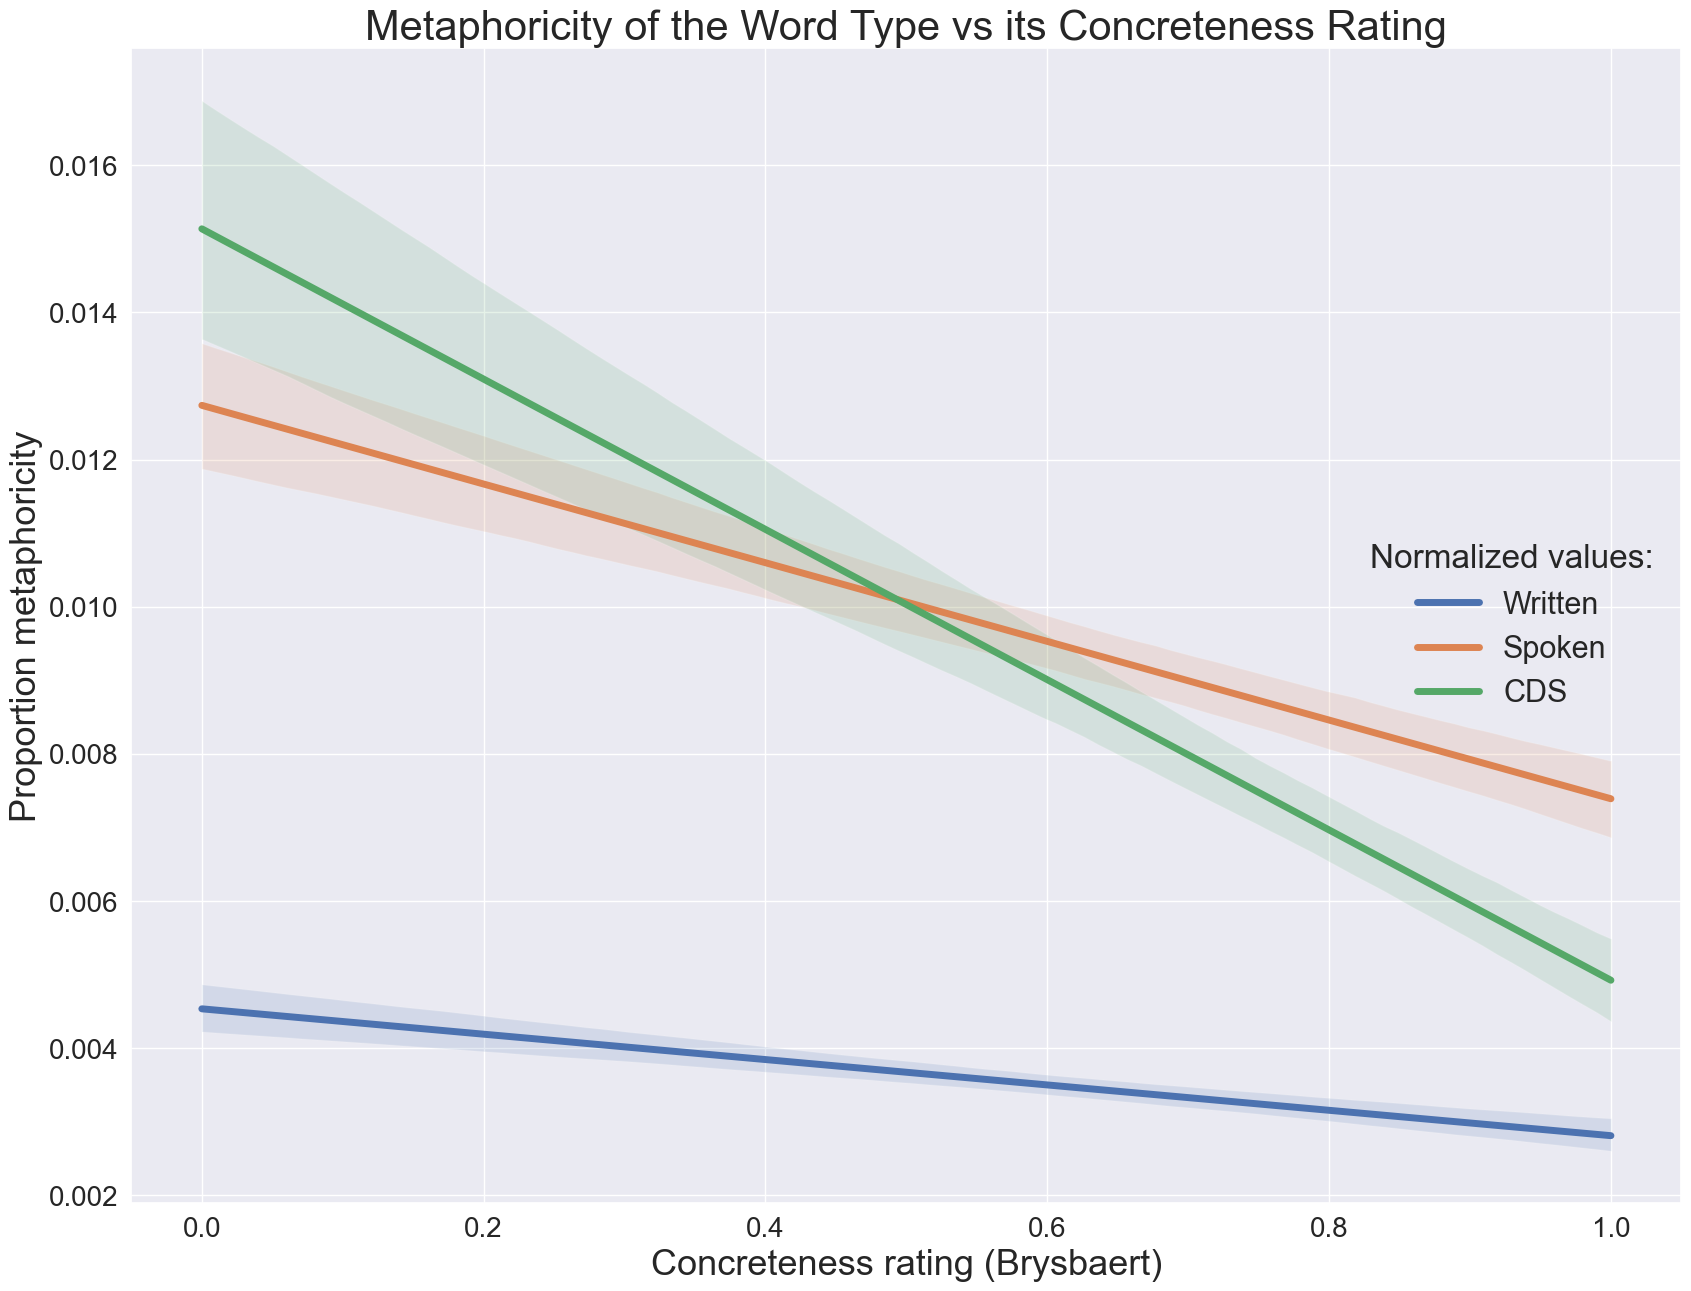

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale

# Ensure the DataFrames exist before proceeding
try:
    # Prepare normalized data
    # We create copies to avoid modifying the original dataframes
    df_Writ_norm = df_Writ_index.astype(float).apply(minmax_scale)
    df_Spok_norm = df_Spok_index.astype(float).apply(minmax_scale)
    df_CDS_norm = df_CDS_index.astype(float).apply(minmax_scale)

    # Initialize the figure
    fig, ax = plt.subplots(figsize=(15, 10))
    sns.set_palette("Set2")

    # Helper function to plot individual corpora
    def plot_corpus(df, label, color):
        sns.regplot(
            x='Rating_Brys', 
            y='Metaphoricity', 
            data=df, 
            fit_reg=True, 
            scatter=False, 
            ci=85, 
            ax=ax, 
            label=label, 
            line_kws={'linewidth': 5},
            color=color
        )

    # Add the plots
    plot_corpus(df_Writ_norm, 'Written', 'tab:blue')
    plot_corpus(df_Spok_norm, 'Spoken', 'tab:green')
    plot_corpus(df_CDS_norm, 'CDS', 'tab:orange')

    # Formatting
    plt.xlabel('Concreteness rating (Brysbaert)', fontsize=20)
    plt.ylabel('Proportion metaphoricity', fontsize=20)
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.title("Metaphoricity vs. Concreteness Rating", size=24, pad=20)
    ax.legend(fontsize=18, title='Corpora', title_fontsize='20', loc='best', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save to working directory (relative path)
    plt.savefig('Concreteness_vs_Metaphoricity.png', dpi=300, bbox_inches='tight')
    print("Plot saved as 'Concreteness_vs_Metaphoricity.png'")

except NameError as e:
    print(f"Error: One of your DataFrames is missing. Please ensure your processing steps have run. Details: {e}")

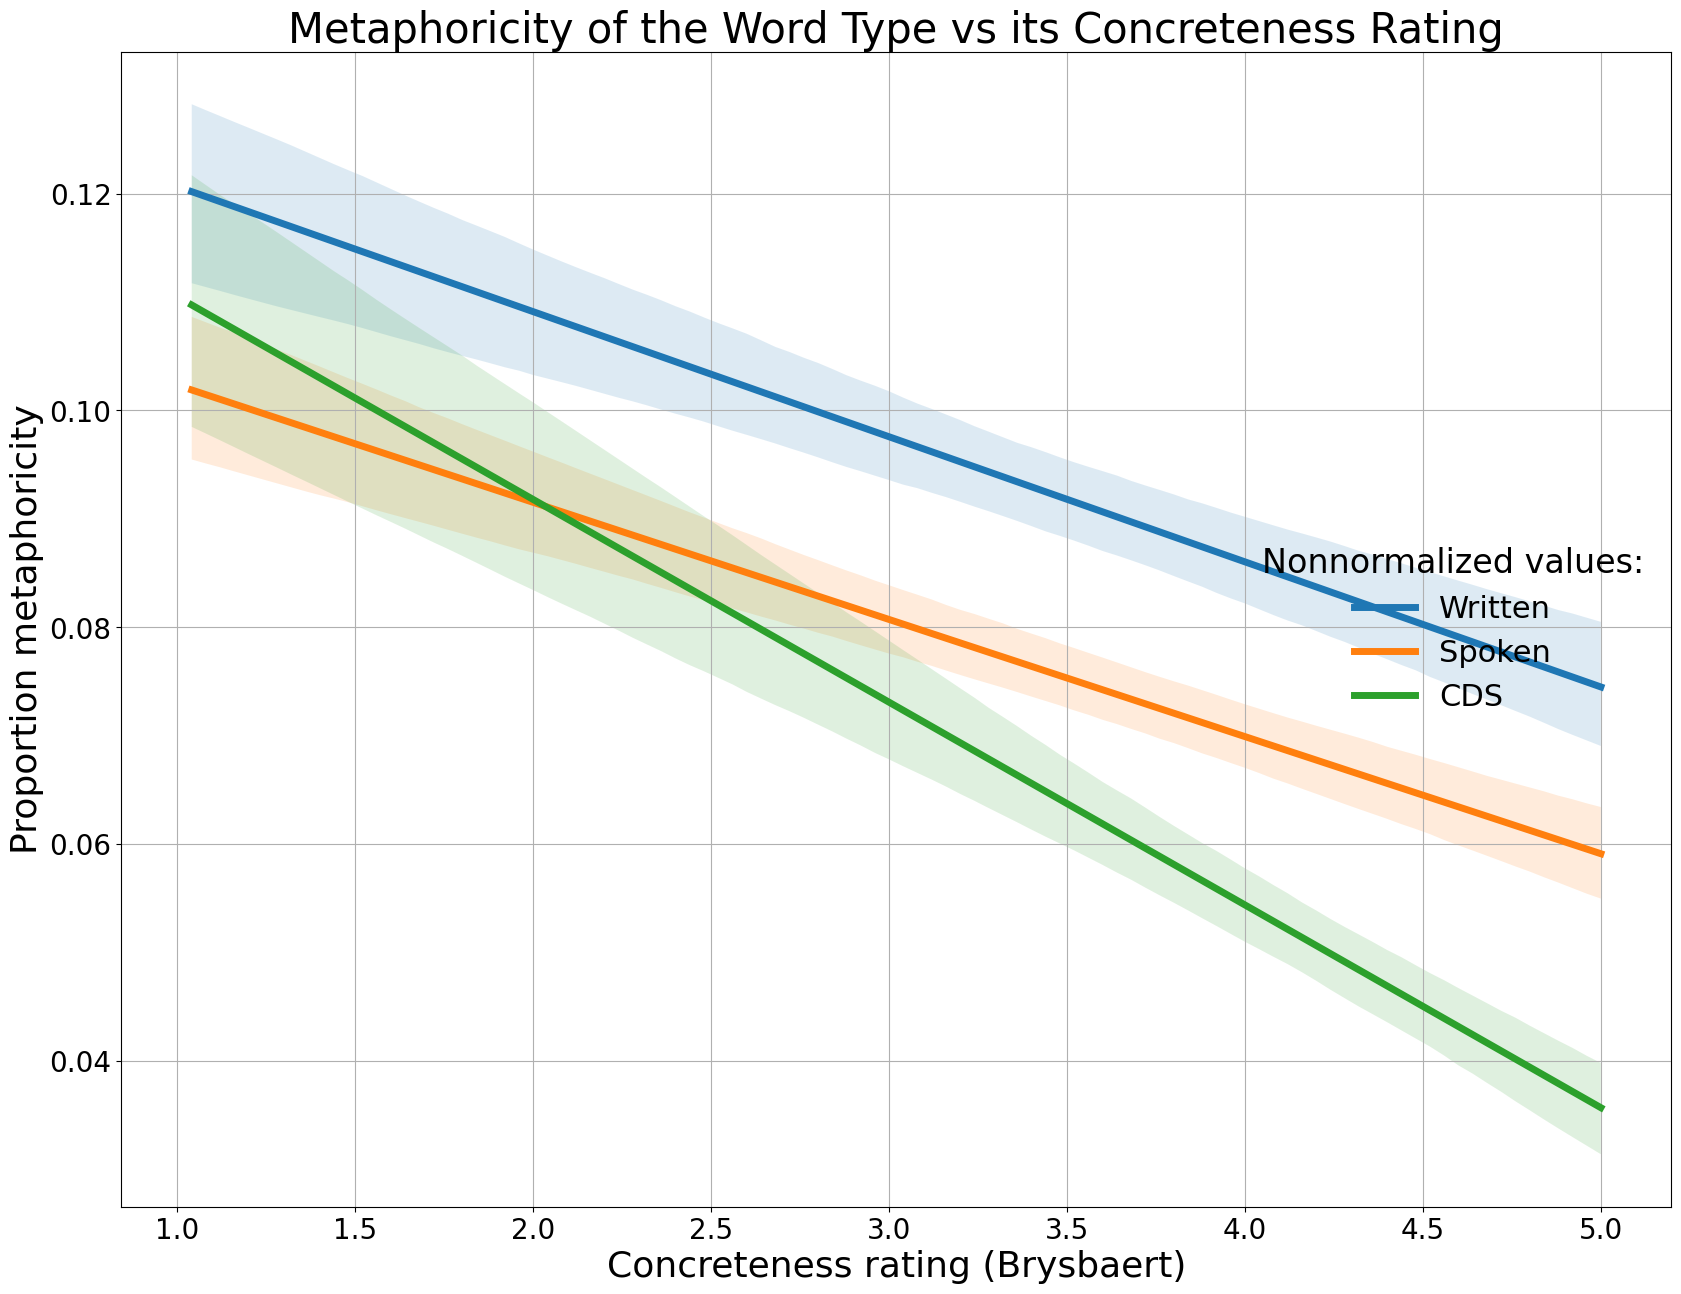

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic and palette globally for consistency
sns.set_theme(style="whitegrid")
sns.set_palette("Set2")

# Create the figure and axes
fig, ax = plt.subplots(figsize=(20, 15))

# Ensure data types are float for plotting
# We use local copies for the plots to avoid modifying original indices
df_Writ_plot = df_Writ_index.astype(float)
df_Spok_plot = df_Spok_index.astype(float)
df_CDS_plot = df_CDS_index.astype(float)

# Add the plots for each dataframe
# Note: Using separate regplots allows for precise control over labeling
sns.regplot(x='Rating_Brys', y='Metaphoricity', data=df_Writ_plot, 
            fit_reg=True, scatter=False, ci=85, ax=ax, 
            label='Written', line_kws={'linewidth': 5})

sns.regplot(x='Rating_Brys', y='Metaphoricity', data=df_Spok_plot, 
            fit_reg=True, scatter=False, ci=85, ax=ax, 
            label='Spoken', line_kws={'linewidth': 5})

sns.regplot(x='Rating_Brys', y='Metaphoricity', data=df_CDS_plot, 
            fit_reg=True, scatter=False, ci=85, ax=ax, 
            label='CDS', line_kws={'linewidth': 5})

# Formatting and labels
plt.xlabel('Concreteness rating (Brysbaert)', fontsize=26)
plt.ylabel('Proportion metaphoricity', fontsize=26)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.title("Metaphoricity vs. Concreteness Rating (Non-normalized)", loc='center', size=30)

# Legend settings
ax.legend(fontsize=22, title='Corpus:', title_fontsize='24', 
          loc='upper right', frameon=False)

plt.show()

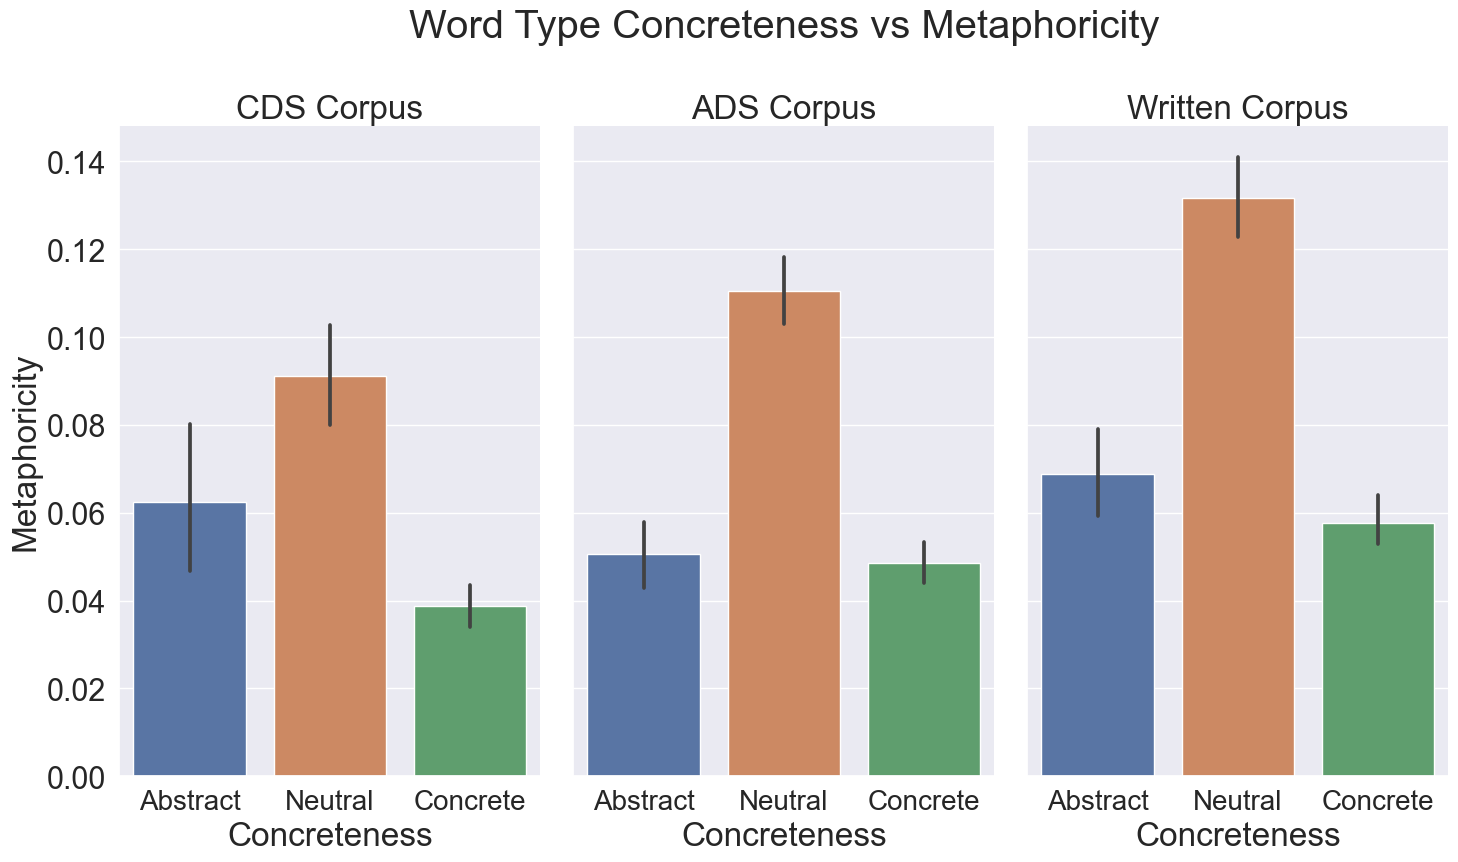

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a Master DataFrame
# Assign the 'Corpus' label directly to each dataframe
df_CDS_index['Corpus'] = 'CDS'
df_Spok_index['Corpus'] = 'ADS'
df_Writ_index['Corpus'] = 'Written'

# Use concat instead of building lists manually (safer and cleaner)
df_combined = pd.concat([df_CDS_index, df_Spok_index, df_Writ_index], ignore_index=True)

# 2. Plotting
sns.set(font_scale=2, style="whitegrid")

# Use 'catplot'
g = sns.catplot(
    data=df_combined, 
    x="Rating_SS", # Ensure this column exists
    y="Metaphoricity", 
    col="Corpus", 
    kind="bar", 
    height=9, 
    aspect=.6,
    palette="Set2"
)

# 3. Formatting
g.set_axis_labels("Concreteness", "Proportion Metaphoricity", labelpad=20)
g.set_xticklabels(["Abstract", "Neutral", "Concrete"], size=20)
g.set_titles("{col_name}", size=24) # Simplified title
g.fig.subplots_adjust(top=.85)
g.fig.suptitle('Word Type Concreteness vs Metaphoricity', fontsize=30)

# Save
plt.savefig(r"\Desktop\Concreteness_vs_Metaphoricity2.jpg", dpi=600)
plt.show()

# Predicting Metaphor Proportions in CDS/ Child speech from Age

In [ ]:
import pandas as pd
import statistics

# Assuming 'df' is already defined with columns ['Name', 'Types']
# Assuming 'Subjects' is defined

cum_num_all = []
new_num_all = []

for name in Subjects:
    # Use a set for O(1) lookups instead of a list
    seen_types = set()
    analyze = df[df["Name"] == name]
    
    cum_num = []
    new_num = []
    
    for types_list in analyze['Types']:
        # Track words found *in this specific session*
        session_new_types = [t for t in types_list if t not in seen_types]
        
        # Update the master set of seen words
        seen_types.update(session_new_types)
        
        # Calculate growth metrics
        cum_num.append(len(seen_types))
        new_num.append(len(session_new_types))
        
    # Apply your specific normalization for the first session
    if new_num:
        new_num[0] = round(statistics.mean(new_num))
        
    cum_num_all.extend(cum_num)
    new_num_all.extend(new_num)

print(f"Cumulative counts: {cum_num_all}")
print(f"New word counts: {new_num_all}")

In [ ]:
data = {'Name': Name, 'Age': Age_in_months, 'Prop_met_types_CS': prop_met_types, 'Prop_met_tokens_CS': prop_met_tokens, 'Num_types_CS': all_types_num,

        'Prop_met_types_CDS': prop_met_types_CDS, 'Prop_met_tokens_CDS': prop_met_tokens_CDS, 'Num_types_CDS': all_types_num_CDS,

        'MLU_CS': mlu_CS_session, 'MLU_CDS': mlu_CDS_session, 'MATTR_CS': mattr_CS, 'MATTR_CDS': mattr_CDS, 'VOCD_CS': vocd_CS, 'VOCD_CDS': vocd_CDS,

        'Concreteness_CS': mean_concreteness_CS, 'Concreteness_CDS': mean_concreteness_CDS, 'Cum_Types': cum_num_all, 'New_Types': new_num_all}

 
# Create DataFrame

df_final = pd.DataFrame(data)

print(df_final) 

# Check for nulls or inconsistent lengths
print(df_final.info())

# Ensure all lists have the same length
lengths = {key: len(val) for key, val in data.items()}
print(f"List lengths check: {lengths}")

# Check for duplicates or missing data
print(f"Missing values per column:\n{df_final.isnull().sum()}")

In [14]:
# Standardizing the independent variable (Age)

from sklearn import preprocessing
df_final["Age_scaled"] = preprocessing.scale(df_final.Age.values)

In [26]:
# Mixed Model for metaphor proportions by age: Child speech

# Random intercept and random slope; Types

formula_CS = "Prop_met_types_CS ~ Age_scaled"

md_CS  = smf.mixedlm(formula_CS, df_final, groups=df_final["Name"], re_formula="~ Age_scaled")
mdf_CS2 = md_CS.fit(method="lbfgs", maxiter=2000)
print(mdf_CS2.summary())


             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Prop_met_types_CS
No. Observations:  617     Method:             REML             
No. Groups:        14      Scale:              2.8638           
Min. group size:   32      Log-Likelihood:     -1233.4959       
Max. group size:   109     Converged:          Yes              
Mean group size:   44.1                                         
----------------------------------------------------------------
                       Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              8.570    0.350 24.451 0.000  7.883  9.257
Age_scaled             0.329    0.181  1.815 0.070 -0.026  0.683
Group Var              1.636    0.409                           
Group x Age_scaled Cov 0.030    0.151                           
Age_scaled Var         0.358    0.112                           



In [25]:
# Mixed Model for metaphor proportions by age: Child speech

# Random intercept and random slope; Tokens

formula_CS = "Prop_met_tokens_CS ~ Age_scaled"

md_CS  = smf.mixedlm(formula_CS, df_final, groups=df_final["Name"], re_formula="~ Age_scaled")
mdf_CS2 = md_CS.fit(method="lbfgs", maxiter=2000)
print(mdf_CS2.summary())


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Prop_met_tokens_CS
No. Observations:  617     Method:             REML              
No. Groups:        14      Scale:              2.1199            
Min. group size:   32      Log-Likelihood:     -1138.1970        
Max. group size:   109     Converged:          Yes               
Mean group size:   44.1                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               5.065    0.279 18.126 0.000  4.517  5.613
Age_scaled             -0.213    0.199 -1.067 0.286 -0.603  0.178
Group Var               1.034    0.297                           
Group x Age_scaled Cov -0.582    0.186                           
Age_scaled Var          0.483    0.155                           



In [37]:
# Mixed Model for lexical diversity by age: Child speech
import statsmodels.formula.api as smf
# Random intercept; Tokens
df_final['mattr_CS']= mattr_CS
df_final['mattr_CDS']= mattr_CDS
df_final['vocd_CS']= vocd_CS
df_final['vocd_CDS']= vocd_CDS

formula_CS = "mattr_CS ~ Age_scaled"

md_CS  = smf.mixedlm(formula_CS, df_final, groups=df_final["Name"])
mdf_CS1 = md_CS.fit()
print(mdf_CS1.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mattr_CS 
No. Observations: 617     Method:             REML     
No. Groups:       14      Scale:              0.0014   
Min. group size:  32      Log-Likelihood:     1110.6714
Max. group size:  109     Converged:          Yes      
Mean group size:  44.1                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.544    0.012 46.926 0.000  0.521  0.567
Age_scaled    0.041    0.002 25.985 0.000  0.038  0.044
Group Var     0.002    0.020                           



c:\Users\lvfeu\Desktop\manchester_context_100.zip (Unzipped Files)\hello\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [53]:
formula_CS = "vocd_CS ~ Age"

md_CS  = smf.mixedlm(formula_CS, df_final, groups=df_final["Name"])
mdf_CS1 = md_CS.fit()
print(mdf_CS1.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: vocd_CS   
No. Observations: 617     Method:             REML      
No. Groups:       14      Scale:              66.4560   
Min. group size:  32      Log-Likelihood:     -2195.0549
Max. group size:  109     Converged:          Yes       
Mean group size:  44.1                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.217    3.307 -0.066 0.948 -6.698  6.264
Age            1.426    0.084 16.977 0.000  1.261  1.591
Group Var     67.548    3.367                           



In [38]:
formula_CDS = "mattr_CDS ~ Age_scaled"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CS1 = md_CDS.fit()
print(mdf_CS1.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mattr_CDS
No. Observations: 617     Method:             REML     
No. Groups:       14      Scale:              0.0002   
Min. group size:  32      Log-Likelihood:     1660.9798
Max. group size:  109     Converged:          Yes      
Mean group size:  44.1                                 
-------------------------------------------------------
             Coef. Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.679    0.006 108.123 0.000  0.666  0.691
Age_scaled   0.014    0.001  22.278 0.000  0.013  0.016
Group Var    0.001    0.014                            



c:\Users\lvfeu\Desktop\manchester_context_100.zip (Unzipped Files)\hello\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [54]:
formula_CDS = "vocd_CDS ~ Age"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CS1 = md_CDS.fit()
print(mdf_CS1.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: vocd_CDS  
No. Observations: 617     Method:             REML      
No. Groups:       14      Scale:              34.2043   
Min. group size:  32      Log-Likelihood:     -1989.1697
Max. group size:  109     Converged:          Yes       
Mean group size:  44.1                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     42.617    2.249 18.953 0.000 38.210 47.025
Age            0.883    0.060 14.648 0.000  0.765  1.001
Group Var     26.780    1.878                           



In [23]:
# Mixed Model for metaphor proportions by age: Child-directed speech

# Random intercept and random slope; Types

formula_CDS = "Prop_met_types_CDS ~ Age_scaled"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"], re_formula="~ Age_scaled")
mdf_CDS2 = md_CDS.fit(method="lbfgs", maxiter=2000)
print(mdf_CDS2.summary())


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Prop_met_types_CDS
No. Observations:  617     Method:             REML              
No. Groups:        14      Scale:              1.1661            
Min. group size:   32      Log-Likelihood:     -944.7004         
Max. group size:   109     Converged:          Yes               
Mean group size:   44.1                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               9.825    0.133 74.136 0.000  9.565 10.085
Age_scaled              0.171    0.075  2.301 0.021  0.025  0.317
Group Var               0.213    0.089                           
Group x Age_scaled Cov -0.011    0.032                           
Age_scaled Var          0.037    0.024                           



In [24]:
# Mixed Model for metaphor proportions by age: Child-directed speech

# Random intercept and random slope; Tokens

formula_CDS = "Prop_met_tokens_CDS ~ Age_scaled"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"], re_formula="~ Age_scaled")
mdf_CDS2 = md_CDS.fit(method="lbfgs", maxiter=2000)
print(mdf_CDS2.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Prop_met_tokens_CDS
No. Observations: 617     Method:             REML               
No. Groups:       14      Scale:              0.4748             
Min. group size:  32      Log-Likelihood:     -673.8697          
Max. group size:  109     Converged:          Yes                
Mean group size:  44.1                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               5.569    0.121 45.999 0.000  5.331  5.806
Age_scaled              0.032    0.052  0.609 0.542 -0.071  0.135
Group Var               0.192    0.118                           
Group x Age_scaled Cov -0.027    0.036                           
Age_scaled Var          0.022    0.023                           



In [39]:
# Predicting CONCRETENESS from Age

formula_CDS = "Concreteness_CDS ~ Age_scaled"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CDS2 = md_CDS.fit()
print(mdf_CDS2.summary())

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Concreteness_CDS
No. Observations: 617     Method:             REML            
No. Groups:       14      Scale:              0.0012          
Min. group size:  32      Log-Likelihood:     1154.7295       
Max. group size:  109     Converged:          Yes             
Mean group size:  44.1                                        
---------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept       2.803     0.009  302.659  0.000   2.785   2.821
Age_scaled     -0.019     0.001  -12.753  0.000  -0.022  -0.016
Group Var       0.001     0.013                                



c:\Users\lvfeu\Desktop\manchester_context_100.zip (Unzipped Files)\hello\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [40]:
# Predicting CONCRETENESS from Age

formula_CS = "Concreteness_CS ~ Age_scaled"

md_CDS  = smf.mixedlm(formula_CS, df_final, groups=df_final["Name"])
mdf_CDS2 = md_CDS.fit()
print(mdf_CDS2.summary())

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Concreteness_CS
No. Observations: 617     Method:             REML           
No. Groups:       14      Scale:              0.0159         
Min. group size:  32      Log-Likelihood:     373.6719       
Max. group size:  109     Converged:          Yes            
Mean group size:  44.1                                       
--------------------------------------------------------------
              Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept      3.018     0.026  114.152  0.000   2.966   3.070
Age_scaled    -0.095     0.005  -18.116  0.000  -0.106  -0.085
Group Var      0.009     0.031                                



c:\Users\lvfeu\Desktop\manchester_context_100.zip (Unzipped Files)\hello\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [59]:
import statsmodels.formula.api as smf
formula_CDS = "Prop_met_types_CDS ~ Prop_met_types_CS + MLU_CDS + mattr_CDS + Concreteness_CDS + MLU_CS + mattr_CS + New_Types"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CDS = md_CDS.fit()
print(mdf_CDS.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Prop_met_types_CDS
No. Observations: 617     Method:             REML              
No. Groups:       14      Scale:              1.1216            
Min. group size:  32      Log-Likelihood:     -926.4105         
Max. group size:  109     Converged:          Yes               
Mean group size:  44.1                                          
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             18.978    3.973  4.777 0.000 11.192 26.765
Prop_met_types_CS      0.158    0.024  6.493 0.000  0.111  0.206
MLU_CDS                0.434    0.109  3.973 0.000  0.220  0.648
mattr_CDS             -1.995    2.503 -0.797 0.425 -6.902  2.911
Concreteness_CDS      -3.945    1.149 -3.433 0.001 -6.198 -1.693
MLU_CS                -0.143    0.138 -

In [ ]:
# Child speech

formula_CDS = "Prop_met_types_CS ~ Prop_met_types_CDS + MLU_CDS + mattr_CDS + Concreteness_CDS + MLU_CS + mattr_CS + New_Types"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CDS = md_CDS.fit()
print(mdf_CDS.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Prop_met_types_CS
No. Observations: 617     Method:             REML             
No. Groups:       14      Scale:              2.8373           
Min. group size:  32      Log-Likelihood:     -1214.2510       
Max. group size:  109     Converged:          Yes              
Mean group size:  44.1                                         
---------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------
Intercept           -2.318    6.590 -0.352 0.725 -15.235 10.598
Prop_met_types_CDS   0.397    0.063  6.299 0.000   0.273  0.520
MLU_CDS             -0.231    0.191 -1.209 0.227  -0.606  0.144
mattr_CDS            6.818    4.252  1.603 0.109  -1.517 15.153
Concreteness_CDS     0.733    1.900  0.386 0.700  -2.992  4.457
MLU_CS               0.901    0.227  3.966 0.000   0.

In [60]:
formula_CDS = " New_Types ~ Prop_met_types_CDS + MLU_CDS + mattr_CDS + Concreteness_CDS"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CDS = md_CDS.fit()
print(mdf_CDS.summary())

               Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    New_Types 
No. Observations:      617        Method:                REML      
No. Groups:            14         Scale:                 557.9128  
Min. group size:       32         Log-Likelihood:        -2828.7748
Max. group size:       109        Converged:             Yes       
Mean group size:       44.1                                        
-------------------------------------------------------------------
                    Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------------
Intercept          -123.946   91.940 -1.348 0.178 -304.145   56.254
Prop_met_types_CDS   -1.068    0.880 -1.213 0.225   -2.793    0.657
MLU_CDS              -5.499    2.582 -2.130 0.033  -10.559   -0.439
mattr_CDS          -208.317   52.081 -4.000 0.000 -310.395 -106.240
Concreteness_CDS    123.560   26.163  4.723 0.000   72.281  174

In [160]:
import statsmodels.formula.api as smf
formula_CDS = "Prop_met_types_CDS ~ MLU_CDS + MATTR_CDS + Concreteness_CDS + MLU_CS + MATTR_CS"

md_CDS  = smf.mixedlm(formula_CDS, df_final, groups=df_final["Name"])
mdf_CDS = md_CDS.fit()
print(mdf_CDS.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Prop_met_types_CDS
No. Observations: 617     Method:             REML              
No. Groups:       14      Scale:              1.1770            
Min. group size:  32      Log-Likelihood:     -938.0583         
Max. group size:  109     Converged:          Yes               
Mean group size:  44.1                                          
----------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------
Intercept            22.485    3.526  6.377 0.000  15.574 29.395
MLU_CDS               0.452    0.118  3.828 0.000   0.221  0.683
MATTR_CDS            -6.017    3.016 -1.995 0.046 -11.928 -0.106
Concreteness_CDS     -4.612    1.140 -4.046 0.000  -6.847 -2.378
MLU_CS                0.178    0.124  1.443 0.149  -0.064  0.420
MATTR_CS              0.910    1.576  0

c:\Users\lvfeu\Desktop\manchester_context_100.zip (Unzipped Files)\hello\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\lvfeu\Desktop\manchester_context_100.zip (Unzipped Files)\hello\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [ ]:
# Mixed Model for metaphor percentages in Child speech

# Random intercept and slope; Tokens

formula_CS = "Prop_met_tokens_CS ~ Prop_met_tokens_CDS"

md_CS  = smf.mixedlm(formula_CS, df_final, groups=df_final["Name"], re_formula="~ Prop_met_tokens_CDS")
mdf_CS = md_CS.fit()
print(mdf_CS.summary())